---
>「中道とは『偏らないこころ』です仏教の真髄はなにかと問われたら、わたしは迷わずこの『中道のこころ』と答えます東洋的には『中庸』と表現します」（中村元『いい加減に生きる』）
---

# 機械学習ライブラリの基礎

代表的な機械学習アルゴリズムの基本として、**単回帰分析**と**重回帰分析**について、さらにより実践的な手法として**SVM**と**ランダムフォレスト**、さらに**LightGBM**について学ぶ



## 単回帰分析

単回帰分析は、機械学習アルゴリズムの中でも最も基礎的な手法のひとつで、ひとつの入力変数からひとつの出力変数を予測する手法である

機械学習アルゴリズムは**教師あり学習**と**教師なし学習**に大別されるが、単回帰分析は教師あり学習に分類される

教師あり学習の典型的問題として、$10$や$0.1$のように数値（連続値）を予測する**回帰**と、赤ワインか白ワインを分けるようなカテゴリ値を予測する**分類**がある

### 単回帰分析の問題例

例として、家賃予測問題、すなわち **出力変数**もしくは**目的変数** $y$として家賃を予測する問題を扱うとき、**入力変数**もしくは**説明変数** $x$は何が想定されるであろうか？

具体例として、家賃の予測に必要な情報、例えば、部屋の広さ、駅からの距離、犯罪発生率などが思い浮かぶが、ここでは部屋の広さを入力変数 $x$ として採用する

もちろん、部屋の広さだけは決定せず、複数の入力変数を扱うモデル化の方が一般的であるが、複数用いる例は重回帰分析として扱う

機械学習のアルゴリズムは、どの手法も大きく分けて次の3ステップ処理が進む

1. モデルの決定
2. 目的関数の決定
3. 最適なパラメータの決定

### Step1. モデルの決定（単回帰分析）

まず**モデル**を決定する
- モデルとは、出力変数 $y$ と入力変数 $x$ の関係を**定式化**した表現手段であり、一般的には人手で設計を行うが、機械学習では、文字通り機械が定式化を行う

例えば、家賃と部屋の広さの関係が次のようなデータセットが与えられたとする

<img src="http://class.west.sd.keio.ac.jp/dataai/text/2-01.png" width="20%">


部屋が広いほど家賃が高くなる比例関係があるため、直線を予測に用いるのが妥当であろう

<img src="http://class.west.sd.keio.ac.jp/dataai/text/2-02.png" width="20%">

そこで直線をモデルとして採用し、特に機械学習では、傾きを**重み (weight)** $w$、 切片を**バイアス (bias)** $b$ と表現することから、モデルを以下のように定式化する

$$
y = wx + b
$$

単回帰分析を行うということは、これら重み$w$とバイアス$b$をデータにうまくフィットするように調整することを意味し、機械学習の多くは、このようなパラメータで特徴付けられたモデルを使い、与えられた**データセット**に適合するようにパラメータを求めることが目標となる
- ここでデータセットは、**入力変数**である部屋の広さ $x$ と**教師データ**となる家賃 $t$ の組からなるデータの集合であり、予測値を $y$として教師データ$t$との差や一致度を議論する
- このデータセットを一般に$\mathcal{D} = \{x_n, t_n\}_{n=1}^{N}$ として表す
- $n$ ($n=1,2,\ldots,N$) は $n$ 番目の物件を、$N$ は**サンプル数**であり全物件数を表す

このデータに対し、最初に**データの中心化**処理を施す\
これは、**平均を** $\boldsymbol{0}$として中央に移動する変換であり、広く一般的に前処理として行われ、さらにスケーリングも行われることが多い

<img src="http://class.west.sd.keio.ac.jp/dataai/text/2-03.png" width="40%">

この処理によりバイアス $b$を$0$とすることができ、$y_{c} = wx_{c}$とシンプルに表現できるため、推定が容易となる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/2-04.png" width="40%">

データの中心化を行うには、入出力の平均をデータの全体から引けばよい

$$
\begin{aligned}
x_{c} &= x - \bar{x} \\
t_{c} &= t - \bar{t}
\end{aligned}
$$

中心化後を示す添え字 $c$ について以後省略するとモデルは次の通り
$$
y = wx
$$

つまり、単回帰分析の目標はデータセット $\mathcal{D} = \{x_n, t_n\}_{n=1}^{N}$ に基づいてパラメータ $w$ を**適切**に調整することである

### Step2. 目的関数の決定（単回帰分析）

一般に教師あり学習では、**目的関数**(**評価関数**、さらには**コスト関数**や**誤差関数**とも呼ばれる)を設計し、その目的関数を最小化(または最大化)することでモデルの学習を行う
- 教師データと予測値の二乗誤差は、完全一致つまり誤差が $0$ のとき $t = y$ となり、誤差が大きくなるにつれて値が大きくなることから、目的関数として広く用いられる

既に述べた通りであるが、$n$ 番目の物件に対する教師データ $t_{n}$ と予測値 $y_{n}$ の二乗誤差は
$$
(t_{n} - y_{n})^{2}
$$
であり、全物件について考慮するため、
$$
\mathcal{L}=\sum^{N}_{n=1}\left( t_{n}-y_{n}\right)^{2}\\
$$
を考える

Step1で決めたモデル $y_{n} = wx_{n}$ を代入すると、目的関数は
$$
\mathcal{L}=\sum^{N}_{n=1}\left( t_{n}-wx_{n}\right)^{2}
$$
となり、これを**損失関数(loss function)**と呼ぶ

### Step3. 最適なパラメータの決定（単回帰分析）

目的関数を最小化するパラメータを微分して求める
$$
\begin{aligned}
\dfrac{\partial }{\partial w} \mathcal{L}  &= \dfrac{\partial}{\partial w} { \sum^{N}_{n=1} ( t_{n}-wx_{n})^{2} }=\sum^{N}_{n=1}\dfrac {\partial }{\partial w}\left( t_{n}-wx_{n}\right)^{2}
\\&=-\sum^{N}_{n=1}2x_{n}\left( t_{n}-wx_{n}\right)
\end{aligned}
$$
この微分値が0となるように $w$ を求めると、
$$
-2\sum^{N}_{n=1}x_{n}\left( t_{n}-wx_{n}\right)=
-2\sum^{N}_{n=1}x_{n}t_{n}+2w\sum^{N}_{n=1}x^{2}_{n}=0\\
\therefore
w=\dfrac {\displaystyle  \sum^{N}_{n=1}x_{n}t_{n}}{\displaystyle  \sum^{N}_{n=1}x^{2}_{n}}
$$
となり、パラメータ $w$ が与えられたデータセット $\mathcal{D} = \{x_n, t_n\}_{n=1}^{N}$ のみで決定できる

実際に、家賃と部屋の広さの例を用いてパラメータ $w$ を求めると、
$$
\begin{aligned}
\bar{x} &= \dfrac{1}{3} (1 + 2 + 3) = 2 \\
\bar{t} &= \dfrac{1}{3}(2 + 3.9 + 6.1) = 4
\end{aligned}
$$

従って、中心化処理を施すと、

$$
\begin{aligned}
x_{1} &= 1 - 2 = -1 \\
x_{2} &= 2 - 2 = 0 \\
x_{3} &= 3 - 2 = 1\\
t_{1} &= 2 - 4 = -2\\
t_{2} &= 3.9 - 4 = -0.1\\
t_{3} &= 6.1 - 4 = 2.1
\end{aligned}
$$

となる

中心化後の値を用いて、最適なパラメータ $w$ を求めると、

$$
\begin{aligned}
w &= \dfrac{\displaystyle \sum_{n=1}^{N}x_{n}t_{n}}{\displaystyle  \sum_{n=1}^{N}x_{n}^{2}}
= \dfrac{x_{1}t_{1} + x_{2}t_{2} + x_{3}t_{3}}{x_{1}^{2} + x_{2}^{2} + x_{3}^{2}} \\
&= \dfrac{-1 \times (-2) + 0 \times (-0.1) + 1 \times 2.1}{(-1)^{2} + 0^2 + 1^2} \\
&= 2.05
\end{aligned}
$$
となり、このパラメータを使用したモデルを**学習済みモデル**と呼ぶ

このモデルを使って新しいサンプルに対する予測を行う
- 学習済みモデルを用い、新たな入力データの予測値を得ることを**推論**と呼ぶ

新しいサンプル $x_{q}=1.5$ に対する予測値は、
$$
\begin{aligned}
y_{c} &= wx_{c} \\
y_{q} - \bar{t} &= w(x_{q}-\bar{x}) \\
\Rightarrow y_{q} &= w(x_{q}-\bar{x}) + \bar{t} \\
&= 2.05 \times (1.5 - 2) + 4 \\
&= 2.975
\end{aligned}
$$
実際の予測値は中心化したデータを元に戻して得る必要がある

## 重回帰分析

重回帰分析は単回帰分析と同様に教師あり学習に分類され、複数の入力変数から出力変数を予測する機械学習アルゴリズムである

### 重回帰分析の問題例

単回帰分析の例を拡張し、駅からの距離や犯罪発生率なども考慮して重回帰解析を行う
- 例えば、部屋の広さ $x_{1}$, 駅からの距離 $x_{2}$, ..., 犯罪発生率 $x_{M}$ のように $M$ 個の入力変数を想定する

単回帰分析と同様のステップで処理を進める

### Step1. モデルの決定（重回帰分析）

重回帰分析では、単回帰解析の式を複数の入力変数へと拡張し、
$$
y=w_{1}x_{1}+w_{2}x_{2}+\ldots +w_{M}x_{M}+b
$$
という**線形結合**の形で表現するとする\
各入力変数は線形に出力変数に影響を与える前提であるため、単純なモデル化である

この場合の重回帰分析のモデルは、
$$
y = \sum_{m=1}^{M} w_{m} x_{m} + b
$$
と記述でき、$x_0 = 1$、$w_0 = b$とすれば、$m=0$も想定できる

$$
y=w_{0}x_{0}+w_{1}x_{1}+\ldots +w_{M}x_{M}
$$
この式はベクトルの内積を意味し、$x\times w$の形にすると、
$$
\begin{aligned}
y&=w_{0}x_{0}+w_{1}x_{1}+\ldots +w_{M}x_{M}\\
&=\begin{bmatrix}
x_{0} & x_{1} & \ldots  & x_{M}
\end{bmatrix}\begin{bmatrix}
w_{0} \\
w_{1} \\
\vdots  \\
w_{M}
\end{bmatrix}
=\boldsymbol{x}^{T}\boldsymbol{w}
\end{aligned}
$$
となり、この式が重回帰分析のモデルである\
今回はパラメータとして $M+1$ 個の重み $\boldsymbol{w}$ を求めればよい

### Step2. 目的関数の決定（重回帰分析）

重回帰分析においても予測値$y$を求めるという点では同じで、次の目的関数を利用する
$$
\begin{aligned}
\mathcal{L}&=\left( t_{1}-y_{1}\right)^{2}+\left( t_{2}-y_{2}\right)^{2}+\ldots + \left( t_{N}-y_{N}\right)^{2}
\end{aligned}
$$
これを$\sum$ではなく、ベクトルを用いて記述すると、
$$
\begin{aligned}
\mathcal{L}&=\begin{bmatrix} t_{1} - y_{1} & t_{2}-y_{2} & \ldots & t_{N}-y_{N} \end{bmatrix} \begin{bmatrix}
t_{1}-y_{1} \\
t_{2}-y_{2} \\
\vdots \\
t_{N}-y_{N}
\end{bmatrix}\\
&=\left( \boldsymbol{t}-\boldsymbol{y}\right)^{T}\left( \boldsymbol{t}-\boldsymbol{y}\right)
\end{aligned}
$$
となる

$$
y=w_{0}x_{0}+w_{1}x_{1}+\ldots +w_{M}x_{M}
$$
より、これを全ての$\boldsymbol{y}$に拡張して、
$$
\begin{aligned}
\boldsymbol{y}&=
\begin{bmatrix}
x_{10} & x_{11} & x_{12} & \ldots  & x_{1M} \\
x_{20} & x_{21} & x_{22} & \ldots  & x_{2M} \\
\vdots  & \vdots  & \vdots  & \ddots  \\
x_{N0} & x_{N1} & x_{N{2}} & \ldots  & x_{NM}
\end{bmatrix}\begin{bmatrix}
w_{0} \\
w_{1} \\
w_{2} \\
\vdots  \\
w_{M}
\end{bmatrix}\\
&=\boldsymbol{X}\boldsymbol{w}
\end{aligned}
$$
と表記できる

行がサンプルで例えば各物件に対応し、列が入力変数で例えば部屋の広さや駅からの距離などに対応する

具体的に考えると、部屋の広さ $= 50m^{2}$ 、駅からの距離 $= 600 m$ 、犯罪発生率 $= 2$% のような $n$ 番目の物件の場合、入力変数の数$M=3$とし、
$$
\boldsymbol{x}_{n}^{T} = \begin{bmatrix}
1 & 50 & 600 & 0.02
\end{bmatrix}
$$
のようにデータを行方向に格納する
- なお、先頭の $1$ はバイアスを包含する際に使用する $x_{0}$ を意味する

### Step3. パラメータを最適化する（重回帰分析）

目的関数を最小化するモデルのパラメータ$\boldsymbol{w}$を次のように求める

目的関数は、
$$
\begin{aligned}
\mathcal{L}&=\left( \boldsymbol{t}-\boldsymbol{y}\right)^{T}\left( \boldsymbol{t}-\boldsymbol{y}\right) \\
&=\left( \boldsymbol{t}-\boldsymbol{X}\boldsymbol{w}\right)^{T}\left( \boldsymbol{t}-\boldsymbol{X}\boldsymbol{w}\right) \\
&= \left\{ \boldsymbol{t}^{T}-(\boldsymbol{X}\boldsymbol{w})^{T}\right\}\left( \boldsymbol{t}-\boldsymbol{X}\boldsymbol{w}\right) \\
&=\left( \boldsymbol{t}^{T}-\boldsymbol{w}^{T}\boldsymbol{X}^{T}\right)\left( \boldsymbol{t}-\boldsymbol{X}\boldsymbol{w}\right) \because (\boldsymbol{A}\boldsymbol{B})^{T} = \boldsymbol{B}^{T}\boldsymbol{A}^{T}\\
&=\boldsymbol{t}^{T}\boldsymbol{t}-\boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w}-\boldsymbol{w}^{T}\boldsymbol{X}^{T}\boldsymbol{t} + \boldsymbol{w}^{T}\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w}\\
\end{aligned}
$$
となる

ここで、
$$
(\boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w})^{T} = \boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w}
$$
であり、
$(\boldsymbol{A}\boldsymbol{B}\boldsymbol{C})^T = \boldsymbol{C}^T\boldsymbol{B}^T\boldsymbol{A}^T$から、
$$
(\boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w})^T = \boldsymbol{w}^{T} \boldsymbol{X}^{T} \boldsymbol{t}
$$
となることから、
$$
(\boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w})^{T} = \boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w} = \boldsymbol{w}^{T} \boldsymbol{X}^{T} \boldsymbol{t}
$$
したがって、
$$
\begin{aligned}
\mathcal{L}=\boldsymbol{t}^{T}\boldsymbol{t}-2\boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w} + \boldsymbol{w}^{T}\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w}\\
\end{aligned}
$$
となる

この目的関数に対しパラメータの$w$について偏微分を算出する

ここで、 $\boldsymbol{w}$ に関する偏微分を求めるため、$\boldsymbol{w}$ 以外の定数項をまとめると、
$$
\begin{aligned}
\mathcal{L}&=\boldsymbol{t}^{T}\boldsymbol{t}-2\boldsymbol{t}^{T}\boldsymbol{X}\boldsymbol{w}+\boldsymbol{w}^{T}\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w}\\
&=\boldsymbol{t}^{T}\boldsymbol{t}-2\left( \boldsymbol{X}^{T}\boldsymbol{t}\right)^{T} \boldsymbol{w}+\boldsymbol{w}^{T}\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w} \\
&= \gamma + \boldsymbol{\beta}^{T}\boldsymbol{w} + \boldsymbol{w}^{T}\boldsymbol{A}\boldsymbol{w} \because \boldsymbol{A}= \boldsymbol{X}^{T}\boldsymbol{X}, \ \boldsymbol{\beta} =-2 \boldsymbol{X}^{T}\boldsymbol{t}, \ \gamma = \boldsymbol{t}^{T}\boldsymbol{t}
\end{aligned}
$$
となり、$\boldsymbol{w}$ に関する二次形式で表現できる

この目的関数を最小化するパラメータ $\boldsymbol{w}$を求めるためには偏微分を求めればよいが、この式は$\boldsymbol{w}$の各要素について2次関数式で表現される

このことを示すには、試しに、
$$
\begin{aligned}
\boldsymbol{w} = \begin{bmatrix}
w_{1} \\ w_{2}
\end{bmatrix},
\boldsymbol{A}=\begin{bmatrix}
1 & 2 \\
3 & 4
\end{bmatrix},\boldsymbol{\beta}=\begin{bmatrix}
1 \\
2
\end{bmatrix}, \gamma = 1
\end{aligned}
$$
といった具体的な数値を入れて各自計算してみるとよいであろう

結局、$\boldsymbol{w}$が何次元でもよく、結局目的関数が最小となる点は、
$$
\begin{cases}
\dfrac {\partial }{\partial w_{0}}\mathcal{L}=0\\
\dfrac {\partial }{\partial w_{1}}\mathcal{L}=0\\
\ \ \ \ \ \vdots \\
\dfrac {\partial }{\partial w_{M}}\mathcal{L}=0\\
\end{cases}
$$
として求めることができ、最終的に、
$$
\dfrac {\partial}{\partial \boldsymbol{w}} \mathcal{L} = \boldsymbol{0}
$$
となる

この式を満たすように、$\boldsymbol{w}$ を決定する

実際にもとめてみよう
$$
\begin{aligned}
\dfrac {\partial }{\partial \boldsymbol{w}}\mathcal{L} =\dfrac {\partial }{\partial \boldsymbol{w}}\left( \gamma + \boldsymbol{\beta}^{T}\boldsymbol{w} + \boldsymbol{w}^{T}\boldsymbol{A}\boldsymbol{w}\right)
= \boldsymbol{0}\\
\dfrac {\partial }{\partial \boldsymbol{w}}\left( \gamma\right) +\dfrac {\partial }{\partial \boldsymbol{w}}\left( \boldsymbol{\beta}^{T}\boldsymbol{w}\right) +\dfrac {\partial }{\partial \boldsymbol{w}}\left( \boldsymbol{w}^{T}\boldsymbol{A}\boldsymbol{w}\right)
=\boldsymbol{0}\\
\boldsymbol{0}+\boldsymbol{\beta}+\left( \boldsymbol{A}+\boldsymbol{A}^{T}\right) \boldsymbol{w} =\boldsymbol{0}\\
-2\boldsymbol{X}^{T}\boldsymbol{t}+\left\{ \boldsymbol{X}^{T}\boldsymbol{X} + \left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{T}\right\} \boldsymbol{w}
=\boldsymbol{0}\\
-2\boldsymbol{X}^{T}\boldsymbol{t}+2\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w}=\boldsymbol{0}\\
\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w}=\boldsymbol{X}^{T}\boldsymbol{t}\\
\end{aligned}
$$

ここで、$\boldsymbol{X}^{T} \boldsymbol{X}$に逆行列が存在するとすると、両辺に左側から $\left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}$ をかけて、単位行列$\boldsymbol{I}$とすると、
$$
\begin{aligned}
\left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}\boldsymbol{X}^{T}\boldsymbol{X} \boldsymbol{w} =\left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}\boldsymbol{X}^{T}\boldsymbol{t} \\
\boldsymbol{I}\boldsymbol{w}=\left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}\boldsymbol{X}^{T}\boldsymbol{t} \\
\boldsymbol{w}=\left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}\boldsymbol{X}^{T}\boldsymbol{t}
\end{aligned}
$$
となる

つまり、与えられたデータセット $\boldsymbol{X}, \boldsymbol{t}$ から、最適なパラメータ $\boldsymbol{w}$ が求まることがわかる

なお、$\boldsymbol{w}$を求めるために$\boldsymbol{X}^{T}\boldsymbol{X}\boldsymbol{w}=\boldsymbol{X}^{T}\boldsymbol{t}$に対して$\left( \boldsymbol{X}^{T}\right)^{-1}$を左から掛けることはできない
- 一般的にサンプル数$N$と入力変数の数$M+1$は異なることから、$\boldsymbol{X} \in \mathcal{R}^{N \times (M+1)}$ は正方行列とはいえない
- つまり、逆行列を持つための条件である **正方行列であること**を満たすとは限らない

$\boldsymbol{X}^{T} \boldsymbol{X}$ は $\boldsymbol{X}^{T}\boldsymbol{X} \in \mathcal{R}^{(M+1) \times (M+1)}$ となり、サンプル数$N$に依存せず常に正方行列となる
- 逆行列が存在するには$\boldsymbol{X}$が列フルランクであり、$\det(\boldsymbol{X}^T\boldsymbol{X})\neq0$となることが必要である

推論の際は学習で得られたパラメータ $\boldsymbol{w}$を用いて、
$$
y_{q} = \boldsymbol{w}^{T}\boldsymbol{x}_{q}
$$
として計算することで予測値が得られる



## NumPyによる実装

重回帰分析を線形代数を用いて、直接計算する\
Pythonでは線形代数を簡単に扱えるライブラリ**NumPy**が広く利用されている\
NumPyを用いて実装したあとに、より上位のライブラリで実装する

さて、重回帰分析では最終的に最適なパラメータ $\boldsymbol{w}$ が
$$
\boldsymbol{w}=\left( \boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}\boldsymbol{X}^{T}\boldsymbol{t}
$$
で表される

ここでは、以下のデータセットを用いて計算する
- このデータセットのサンプル数$N$は$4$、入力データ$X$の変数の数は$2$である
- $t$は教師データである

$$
\boldsymbol{X} =
\begin{bmatrix}
1 & 2 & 3 \\
1 & 2 & 5 \\
1 & 3 & 4 \\  
1 & 5 & 9
\end{bmatrix}, \
\boldsymbol{t} =
\begin{bmatrix}
1 \\ 5 \\ 6 \\ 8
\end{bmatrix}
$$

$\boldsymbol{X}$は **パラメータ$\boldsymbol{w}$がバイアス** $\boldsymbol{b}$ **を包含する** 形式を想定しているため、入力データ$\boldsymbol{X}$の1列目には$1$が格納されている

まずNumPyを読み込み、ベクトルの定義に続いて、これを表示させる
- 機械学習や数学的解析では、Pythonのリスト形式では機能が不足し設計コストが膨大になるため、通常用いることはない
  - 既に学んでいる通り、一般にPythonではprint(t)として内容を表示するが、Jupyter Notebookや、Google Colaboratoryは、print()を省略できるが、省略する場合は複数の項目をならべても最後の値のみ表示されることに注意する

In [1]:
import numpy as np
t = np.array([1, 5, 6, 8])
t

array([1, 5, 6, 8])

一応、print()でも確認する答えは同じであるが、表示フォーマットが異なる点に注意する

In [2]:
print(t)

[1 5 6 8]


次に、np.array関数を利用して行列を定義する

NumPyには様々な行列処理に関する拡張機能が準備されており、NumPyの多次元配列形式np.**ndarray**形式を用いると便利である
- さらに、NumPy互換のcupyを利用すれば、GPUを使った高速演算も可能となる

以下のコードでは、pythonのリスト形式で宣言しているが、直接np.arrayでndarray形式に変換している
- この時、Xを表示させたときに同時に出力される型名がarrayとなっていることにも注意する

このような、単にarrayと表示されるかされないかの**小さなサイン**であるが、**どのような型か**を正しく見極め、**それぞれの型の違いに応じた正しい扱い**を行い、また、**必要に応じて適切に型変換する**ことは、データサイエンスの基本である

これから学ぶ者にとって、節々に現れるこのような小さなサインを見落とすことは致命傷であり、何をやってもエラーが取れない、全くエラーの原因がわからないという**奈落の底落ち弩ハマリに陥る**結果、pythonや機械学習プログラミングを大嫌いになり、吐き気がするようになる十分な理由となりえるであろう
- なるべく、そのような問題に遭遇した場合でも対処できるように、型については随時確認する癖をつけるとよいであろう
- 型とは、まさにデータの型に加えて、配列や行列、テンソルなどの要素数も含む
そしてそれほど心配することもない
- 殆どのpythonを用いるデータサイエンティストが通る通過儀礼でもあり、ググれば大量に対処法が手に入るが、その対処法そのものの良し悪しも判断できるようになっていただきたい

In [3]:
X = np.array([
    [1, 2, 3],
    [1, 2, 5],
    [1, 3, 4],
    [1, 5, 9]
])
X

array([[1, 2, 3],
       [1, 2, 5],
       [1, 3, 4],
       [1, 5, 9]])

np.arrayを利用しなかった場合についても確認しておく

In [4]:
Xarray = [
    [1, 2, 3],
    [1, 2, 5],
    [1, 3, 4],
    [1, 5, 9]]
Xarray

[[1, 2, 3], [1, 2, 5], [1, 3, 4], [1, 5, 9]]

より具体的には、それぞれの型を確認する命令を用いて確認するとよい

In [5]:
print(type(X))
print(type(Xarray))

<class 'numpy.ndarray'>
<class 'list'>


次にXの転置を行う

np.ndarrayでは.Tメンバ関数（メソッド）を用いることができるが、pythonの配列ではXarray.Tは提供されておらずエラーとなる
- 同様にブロードキャストも行えない

pythonは本家ではなくライブラリ設計者が頑張った結果、このような状況になっているが、これは双方とも責任がある
- まっとうな言語設計者ならば、ポリモーフィズムの精神にのっとり、オリジナルpythonを基底としてオーバライドしろといいたい
  - なぜこういうフリーフォーマットでもなく制約の多い言語が人気第一位なのかさっぱりわからないと考えつつも仕方なく利用する一人であり、実はしばしばpythonの理不尽さによくコケる

In [6]:
X.T

array([[1, 1, 1, 1],
       [2, 2, 3, 5],
       [3, 5, 4, 9]])

行列積はnp.dotで求めることができる行列積を行う際は、左行列の行列の列数と右行列の行数が同じであることに注意する

In [7]:
XX = np.dot(X.T, X)
XX

array([[  4,  12,  21],
       [ 12,  42,  73],
       [ 21,  73, 131]])

これも本来ならば、演算子オーバライド(オーバーロード)で表現されるべきで、pythonのセンスのなさは許しがた**かった**
- もっと愚痴を言うと、基本仕様がタコで、A\*Bとすると、どちらかというとマイナーなアダマール積が求まってしまうありさま

そもそも行列積が単純な記号で書けないのは流石に我慢ならんという人が他にもいるようで、比較的に新しいNumPyでは行列の掛け算を@という演算子記号で表現する拡張がなされている

In [8]:
XX2 = X.T@X
XX2

array([[  4,  12,  21],
       [ 12,  42,  73],
       [ 21,  73, 131]])

参考までに、画像処理などでよく利用される、要素ごとの掛け算であるアダマール積を求める

In [9]:
XX3 = X*X
XX3

array([[ 1,  4,  9],
       [ 1,  4, 25],
       [ 1,  9, 16],
       [ 1, 25, 81]])

次に、$\boldsymbol{X}^{T}\boldsymbol{X}$に対する逆行列である$\left(\boldsymbol{X}^{T}\boldsymbol{X}\right)^{-1}$を、逆行列を求める関数、np.linalg.invを用いて求める

In [10]:
XX_inv = np.linalg.inv(XX)
XX_inv

array([[ 1.76530612, -0.39795918, -0.06122449],
       [-0.39795918,  0.84693878, -0.40816327],
       [-0.06122449, -0.40816327,  0.24489796]])

以上で必要な値が揃ったことになる\
最適なパラメータ$(\boldsymbol{X}^{T}\boldsymbol{X})^{-1}\boldsymbol{X}^{T}\boldsymbol{t}$を求めると、

式の理解には逆行列を使えるが、実装では `np.linalg.lstsq(X, t, rcond=None)` で最小二乗解を直接求める方法も確認する
- `X.T @ X` を作ると条件数が悪化する場合があり、逆行列を明示的に作らない方が安定する
- `lstsq` はランクが不足する場合も扱える正則化する場合はRidgeなどを比較する

```python
w_lstsq, residuals, rank, singular_values = np.linalg.lstsq(X, t, rcond=None)
print(w_lstsq, rank)
```
- このセルまでの例と同じ `X`、`t` を用いる
- 係数だけでなく、ランクと特異値を確認することも重要となる


In [11]:
w = XX_inv@(X.T@t)
w

array([-0.14285714,  0.71428571,  0.57142857])

以上により、パラメータ $\boldsymbol{w}$ が求まる

## 多重共線性(Multicollinearity)

マルチコという愛称もある著名な現象で、重回帰分析などの多変量解析を行う際に高い相関のある説明変数を一緒に用いた場合、
- 例えば、湿度と降雨量、定額区間のバス利用者数とバス運賃売り上げなどは、高い相関があることが理解できるであろう

多重共線性により回帰係数の誤差が大きくなる現象が発生する
- 結果として解析結果が不安定となり、偏回帰係数の値が信頼できなくなる

多重共線性が起こりえるかどうかを判断するために、分散拡大要因(VIF)を調べる手法が提案されている
- 一般的にVIF>10であれば多重共線性ありと判断される
- この場合、高い相関のある説明変数を削除することが効果的で、その選別には、主成分分析などが用いられる

なお、ニューラルネットワークでも相関の高い入力やスケールの違いは、最適化や解釈へ影響する
- 正則化や標準化が助けになる場合はあるが、問題が自動的に消えるわけではない
- 高い予測性能と、各特徴量の因果的な効果を説明できることは別である


# scikit-learn

既に利用しているが、あらためて説明する

重回帰分析程度であればNumPyでも比較的容易に実装できるが、実際に利用する機械学習アルゴリズムの多くは複雑であり、上記のように最初から実装することは非効率的である
- そこで、**scikit-learn**とよばれる機械学習用のフレームワークが良く利用されている
- scikit-learnはsklearnとしばしば略記されるが、様々な機械学習アルゴリズムを集めた便利ツール集である
- pythonには、numpy, pandas, matplotlib, scikit-learn, pytorch, tensorflow, kerasなど様々な有用ライブラリが存在するが、これらの存在がpythonを学ぶべき一番の理由と言って過言ではない

scikit-learnでは、次のチャート(チートシート)に示すように、機械学習を行う際の指南も行っている
- もちろん、この通りにすればベストであるとは言えず、日進月歩の当該領域で、このようなチャートが有効かどうかは微妙である

この図の通り、処理の分類として
- 分類: classification
- 回帰: regression
- クラスタリング; clustering
- 次元削減: dimensionality reduction
と大別できる

<img src="http://class.west.sd.keio.ac.jp/dataai/scilearn/scikitlearn.png">

<img src="http://class.west.sd.keio.ac.jp/dataai/scilearn/scikit-learn-cs.png">



## scikit-learnでできること

様々な機能があるが、およそ次のようにまとめることができる
- 線形モデル、SVM、決定木などは、比較の基準となるベースラインとして現在も重要である
- 表形式のデータでは、勾配ブースティングなどが有力な選択肢となる
- DNNや基盤モデルと比べるときも、同じ分割、指標、計算予算で評価する
- 問題がどの方法で解けるかを確かめ、その方法の仮定や失敗する条件を理解することが重要である


## 分類（classification）

教師あり学習の一種であり、与えられたデータがどのクラスに属するかを判別する手法で、以下のような手法が用意されている
- SGD（stochastic gradient descent）
 - 大規模データ（10万件以上）に適する、線形のクラス分類手法
- カーネル近似
 - SGDではうまく分類できない場合に利用する、非線形なクラス分類手法であり、やはり大規模データ向け
- Linear SVC
 - 中小規模（10万件未満）向けの線形のクラス分類手法
- k近傍法
 - Linear SVCでうまく分類できない場合に利用する、非線形なクラス分類手法であり、中小規模データ向け

この他、テキストデータの場合、ナイーブベイズ、ランダムフォレストなど様々な手法が提供されている


## 回帰（regression）

与えられたデータをもとに目的とする値を予測する教師あり学習方法であり、以下のような手法が用意されている
- SGD（stochastic gradient descent）
 - 大規模データ（10万件以上）に適する、線形の回帰分析手法
- LASSO、ElasticNet
 - 中小規模（10万件未満）で、説明変数の一部が重要な場合に適する、回帰分析手法
- Ridge、Linear SVR
 - 中小規模（10万件未満）で、説明変数の全てが重要な場合に適する、回帰分析手法
- SVR（ガウスカーネル）、Ensemble
 - Ridge、またはLinearSVRではうまく分析できない場合に利用する、非線形な回帰分析手法

## クラスタリング（clustering）

教師なし学習の一種で、与えられたデータを、なんらかの規則に則って分ける方法であり、以下のような手法が用意されている
- KMeans
 - いくつのクラスタに分かれるのか、事前に決めることができる場合に適するクラスタリング分析手法\
大規模データでは、データを分けながら学習させるMiniBatch手法を用いる
- スペクトラルクラスタリング、GMM
 - KMeansではうまく分析できない場合に利用する、非線形なクラスタリング分析手法
- MeanShift、VBGMM
 - いくつのクラスタに分かれるのかを事前に決めることができない場合に適する、クラスタリング分析手法

## その他の機能

### 次元削減

与えられたデータの次元数が多い場合、学習効率を上げるため、次元削減という前処理が用いられる\
PCA、カーネルPCA、Isomap、SpectralEmbeddingなどの手法がある
- Sparse Coding
 - 次元削減法の一種であるが、より少ない要素で複雑なデータを表現する際に利用される

### ハイパーパラメータの最適化

機械学習を行う際、学習の方法などを調整する数値のことを「ハイパーパラメータ」と呼ぶ

 - グリッドサーチ、クロスバリデーションなどの手法がある

よく聞く手法はほぼ全て入っているといえる

## scikit-learnによる単回帰分析

### scikit-learnの利用準備

まず最初に、国別の様々なデータが含まれたデータをダウンロードする\
if文は、何度もダウンロードしないための工夫である

In [12]:
import os
if not os.path.exists('testdata1.csv'):
    !wget "https://drive.google.com/uc?export=download&id=1OjQD2W3oKDt_WehkNj2EyfAh-TuUgK6R" -O testdata1.csv


--2026-10-07 06:27:32--  https://drive.google.com/uc?export=download&id=1OjQD2W3oKDt_WehkNj2EyfAh-TuUgK6R
Resolving drive.google.com (drive.google.com)... 172.217.194.101, 172.217.194.113, 172.217.194.138, ...
Connecting to drive.google.com (drive.google.com)|172.217.194.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1OjQD2W3oKDt_WehkNj2EyfAh-TuUgK6R&export=download [following]
--2026-10-07 06:27:33--  https://drive.usercontent.google.com/download?id=1OjQD2W3oKDt_WehkNj2EyfAh-TuUgK6R&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.68.132, 2404:6800:4003:c02::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.68.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3670 (3.6K) [application/octet-stream]
Saving to: ‘testdata1.csv’

testdata1.csv       100%[===================>]   3.58K  --.-KB/s  

左のファイルメニューからtestdata1.csvをクリックすると中身を見るとわかるが、国別の様々なデータが含まれていることがわかる

ここから、学籍と学生のスキルの関連を調べる

まずは、基本ライブラリを読み込む
- また、線形モデルを読み込む

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import sklearn.linear_model

### データの準備と扱い

次にデータを読み込むが、一番最初の列が国名つまり、インデックスであることを指定しておくと後で便利
- 指定しなかった場合は行番号の数字で指定することになる
- あとからset_indexを使ってインデックスを変更することもできる
- なお、コンマ , で区切られている場合は read_csv、タブで区切られている場合は read_table を利用する

In [14]:
td = pd.read_csv("testdata1.csv", index_col=0)

データについて確認する
- td.info とすれば全体を見ることができるが膨大なのでほぼ意味がないので省略する
- 行と列のインデックスを表示させてみる

In [15]:
print(td.index.values)
print(td.columns.values)

['Australia' 'Austria' 'Belgium' 'Canada' 'Chile' 'Czech Republic'
 'Denmark' 'Estonia' 'Finland' 'France' 'Germany' 'Greece' 'Hungary'
 'Iceland' 'Ireland' 'Israel' 'Italy' 'Japan' 'Korea' 'Latvia'
 'Luxembourg' 'Mexico' 'Netherlands' 'New Zealand' 'Norway' 'Poland'
 'Portugal' 'Slovak Republic' 'Slovenia' 'Spain' 'Sweden' 'Switzerland'
 'Turkey' 'United Kingdom' 'United States']
['Dwellings without basic facilities' 'Housing expenditure'
 'Rooms per person' 'Household net financial wealth' 'Employment rate'
 'Long-term unemployment rate' 'Personal earnings'
 'Educational attainment' 'Student skills' 'Years in education'
 'Air pollution' 'Water quality' 'Voter turnout' 'Life expectancy'
 'Self-reported health' 'Life satisfaction'
 'Feeling safe walking alone at night' 'Homicide rate'
 'Employees working very long hours'
 'Time devoted to leisure and personal care']


Years in education行の先頭だけ表示する

In [16]:
td['Years in education'].head()

,Years in education
Country,
Australia,21.2
Austria,17.1
Belgium,18.2
Canada,16.7
Chile,17.3


こちらの指定のしかたでもよい、表示のされ方が違うことに注意

In [17]:
td[['Years in education']].head()

,Years in education
Country,
Australia,21.2
Austria,17.1
Belgium,18.2
Canada,16.7
Chile,17.3


この二つでなぜ表示のされ方が違うかは、その型を調べると良くtype関数を使う
- この場合、前者はシリーズで、後者はDataFrameである

In [18]:
print(type(td['Years in education'].head()))
print(type(td[['Years in education']].head()))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


復習として、データの列を取得する

In [19]:
td['Air pollution'].head(5)

,Air pollution
Country,
Australia,5
Austria,16
Belgium,15
Canada,7
Chile,16


行を取得する

In [20]:
td.loc['Japan'].head(5)

,Japan
Dwellings without basic facilities,6.4
Housing expenditure,22.0
Rooms per person,1.9
Household net financial wealth,97595.0
Employment rate,74.0


要素を取り出す
- 3つの方法(loc, 配列, at, iat)を示す
- iatは数字で指定する
- 数字を探すときは次のようにすると良い
```
ind = td.index.values
np.where(ind == 'Japan')
```

In [21]:
print(td.loc['Japan']['Educational attainment'])
print(td['Educational attainment']['Japan'])
print(td.at['Japan','Educational attainment'])
print(td.iat[17, 7])

94.0
94
94
94


範囲でも構わない

In [22]:
td['Japan':'Mexico'][['Air pollution', 'Voter turnout']]

,Air pollution,Voter turnout
Country,,
Japan,14,53
Korea,28,77
Latvia,11,59
Luxembourg,12,91
Mexico,16,63


データを可視化することも瞬間にできる

<Axes: xlabel='Country'>

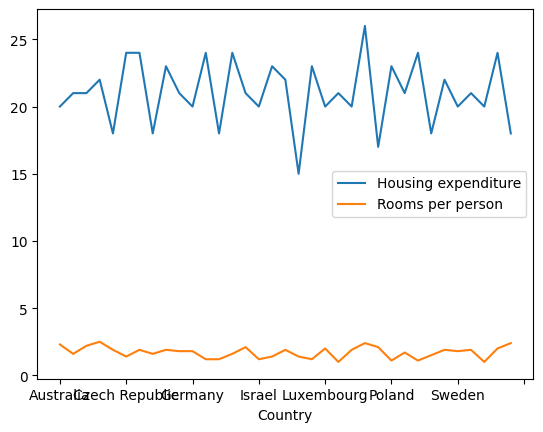

In [23]:
td[['Housing expenditure','Rooms per person']].plot()

では、学生の学業スコア(student skills)でデータをソートする
- 表全体で並び替えていることに注目する

In [24]:
td_s = td.sort_values('Student skills')

Student skillsとEducational attainment(学歴)の関係をみてみる
- matplotlibは結構適当にデータをいれても意を組んで表示してくれる

<Axes: xlabel='Student skills'>

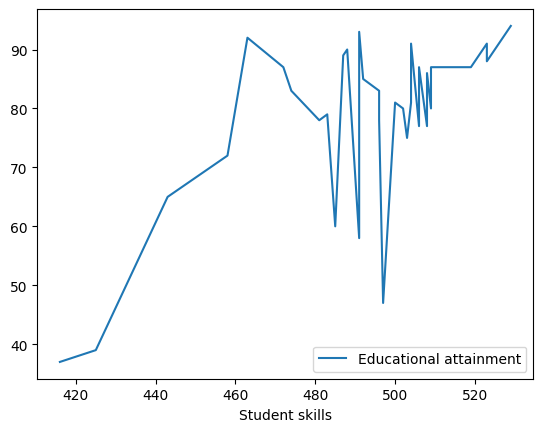

In [25]:
td_s.plot(x='Student skills', y='Educational attainment')

### モデルの準備と学習(fitting)

回帰解析として、線形モデルを選択

In [26]:
model = sklearn.linear_model.LinearRegression()

Student skillsとEducational attainmentのデータを配列にそれぞれコピーする
- ここでpythonの悪い癖が出る
  - td_s['Student skills']ではラベルがあるからダメで、これをto_numpy()として変換しても、今度は配列だからだめ
  - 配列の配列となるデータが欲しい

In [27]:
x = td_s['Student skills']
x.head()

,Student skills
Country,
Mexico,416
Turkey,425
Chile,443
Greece,458
Slovak Republic,463


In [28]:
x = td_s['Student skills'].to_numpy()
x

array([416, 425, 443, 458, 463, 472, 474, 481, 483, 485, 487, 488, 491,
       491, 492, 496, 496, 497, 500, 502, 503, 504, 504, 504, 506, 506,
       508, 508, 509, 509, 519, 523, 523, 524, 529])

次のようにすると変換できる
- 中身は各自で確認するとよい
- 次のセルに記述した方法以外にも、次のコードのような、より速い方法もある
```
x = np.c_[td_s['Student skills']]
y = np.c_[td_s['Educational attainment']]
```


In [29]:
x = [[i] for i in td_s['Student skills'].to_numpy()]
y = [[i] for i in td_s['Educational attainment'].to_numpy()]

In [30]:
print(x)
print(y)

[[np.int64(416)], [np.int64(425)], [np.int64(443)], [np.int64(458)], [np.int64(463)], [np.int64(472)], [np.int64(474)], [np.int64(481)], [np.int64(483)], [np.int64(485)], [np.int64(487)], [np.int64(488)], [np.int64(491)], [np.int64(491)], [np.int64(492)], [np.int64(496)], [np.int64(496)], [np.int64(497)], [np.int64(500)], [np.int64(502)], [np.int64(503)], [np.int64(504)], [np.int64(504)], [np.int64(504)], [np.int64(506)], [np.int64(506)], [np.int64(508)], [np.int64(508)], [np.int64(509)], [np.int64(509)], [np.int64(519)], [np.int64(523)], [np.int64(523)], [np.int64(524)], [np.int64(529)]]
[[np.int64(37)], [np.int64(39)], [np.int64(65)], [np.int64(72)], [np.int64(92)], [np.int64(87)], [np.int64(83)], [np.int64(78)], [np.int64(79)], [np.int64(60)], [np.int64(89)], [np.int64(90)], [np.int64(58)], [np.int64(93)], [np.int64(85)], [np.int64(83)], [np.int64(78)], [np.int64(47)], [np.int64(81)], [np.int64(80)], [np.int64(75)], [np.int64(81)], [np.int64(82)], [np.int64(91)], [np.int64(77)], [np

学習させる

In [31]:
model.fit(x,y)

LinearRegression()

### 結果検証

例えば、420点取る場合は、どの程度の学歴指数があるかを見る

In [32]:
model.predict([[420]])

array([[52.39360017]])

グラフにするため、生成された近似1次関数をみる
- 単純に値を入れて、予測値を出して描画するのだが、numpy配列の配列のさらに配列という謎な構造になる
- 様々な直し方があり、例えば、
```
np.c_[py].flatten
```
とする方法もあるが、より直観的な方法として配列を外すために[0]として最初の要素を取り出すという操作を繰り返す

In [33]:
px = []
py = []
for i in range(410, 530, 10):
  px.append(i)
  py.append(model.predict([[i]])[0][0])

結果をみてみると、なんとなく近似曲線が生成されていることがわかる

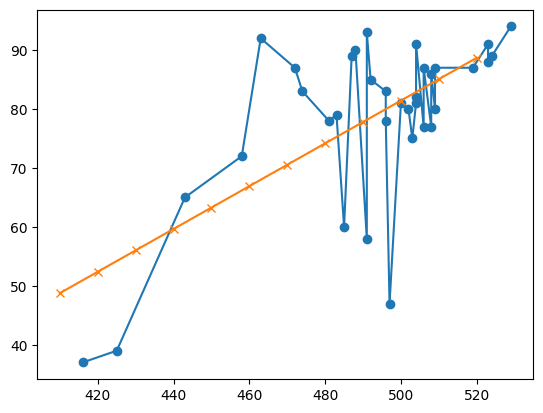

In [34]:
plt.plot(x, y, marker='o')
plt.plot(px, py, marker='x')

## scikit-learnによる重回帰分析

重回帰分析について、**scikit-learnを用いた実装**を行う
- データセットは先程と同じ、$\boldsymbol{X}$と$\boldsymbol{t}$とする

scikit-learnでは **パラメータ**$\boldsymbol{w}$が**バイアス** $\boldsymbol{b}$ **を包含しない** 形式を想定しているため、入力データ$\boldsymbol{X}$の1列目から$1$を取り除くこととなる

従って、
$$
\boldsymbol{X} =
\begin{bmatrix}
2 & 3 \\
2 & 5 \\
3 & 4 \\  
5 & 9
\end{bmatrix}, \
\boldsymbol{t} =
\begin{bmatrix}
1 \\ 5 \\ 6 \\ 8
\end{bmatrix}
$$
とする



### scikit-learn の利用準備

scikit-learnは`sklearn`という名前で呼び出す

In [35]:
import sklearn

重回帰分析を使用する場合は以下のように必要な機能を呼び出す

In [36]:
from sklearn.linear_model import LinearRegression

重回帰分析のアルゴリズムはクラスとして定義されており、実際のモデルを利用するにはインスタンス化する必要がある
- インスタンス化はクラス名の後に()をつけて行う


In [37]:
model = LinearRegression()

### データの設定と学習(fitting)

以上で、重回帰分析ライブラリを使用する準備が整った

- パラメータの学習は以下のように行う

In [38]:
X = np.array([
    [2, 3],
    [2, 5],
    [3, 4],
    [5, 9]
])
t = np.array([1, 5, 6, 8])

model.fit(X, t)

LinearRegression()

### 結果検証

結果の検証には、scoreメソッドを用いるが、その実態は回帰の場合、次の**決定係数**とよばれる指標$R$を用いて計算される

$$
R^{2} = 1 - \dfrac{\sum_{i}\left( t_{i} - y_{i} \right)^{2}}{\sum_{i}\left( t_{i} - \bar{t} \right)^{2}}
$$

$R$は1に近い程相対的な残差が少ないことを意味する

なお、最小二乗法はこの値を最大にするパラメータの選択法であり、$R$をみることで、どの程度学習が進んだか、どの程度の精度が期待できるかを推し量ることができる


In [39]:
model.score(X, t)

0.6923076923076923

**このように、scikit-learnでは簡単なインターフェースで処理することが可能であり、どのアルゴリズムも`.fit()`で学習し、`.score()`で検証を行うように統一されている**
- `score()`はXを用いて`predict()`を内部で呼び出し、その結果とtを検証することに注意する
- またアルゴリズムによって多少異なるが、パラメータもインスタンス変数として格納されており、学習後に確認可能である

In [40]:
# パラメータw (coefficient)
model.coef_

array([0.71428571, 0.57142857])

In [41]:
# バイアスb (intercept)
model.intercept_

np.float64(-0.14285714285714235)

## サンプルデータセットによるより実践的な例

scikit-learnは機械学習の実装を支援する多くの機能を有する

そこで、サンプルデータセットの使用方法及びデータセットの分割方法について述べる

### サンプルデータセットの使用

scikit-learnでは幾つかのデータセットがあらかじめ提供されており、すぐに学習を始めることができるように工夫されている
- その中から、米国カリフォルニア市郊外における地域別の物件価格のデータセット California Housing を取り上げて利用する
- California Housingは、1990年米国カリフォルニアの住宅価格のデータセットであり、データ数は20,640件である
- California Housingでは、データ1つ1つが1世帯に対応しているわけではなく、カリフォルニアの1地区に対応し、データ自体はこれらの平均や中央値が利用されている
  - カリフォルニアの20,640地区に相当するデータとなっており、1世帯に対応しているわけではない
  
> データセットの詳細

| | |
|:-:|:-:|
|レコード数 | 20,640 |
|カラム数	| 8 |

> 各カラムの構成

| | | |
|:--|:-:|:--|
|Medlnc	|世帯所得の中央値	|各地区における世帯平均所得、単位は10,000ドル|
|HouseAge	|家の築年数	|各地区における家の平均築年数、単位は年|
|AveRooms	|部屋の平均数 |各地区における平均の部屋数|
|AveBedrms |寝室の平均数 |各地区における平均の寝室数|
|Population	|居住人数の合計	|各地区における合計の居住人数数|
|AveOcuup	|世帯人数の平均	|各地区における平均の世帯人数|
|Latitude	|平均緯度	|各地区における代表地区の緯度（各地区におけるすべての家の緯度の平均だと思われる）|
|Longitude |平均経度 |各地区における代表地区の経度（各地区におけるすべての家の緯度の平均だと思われる）|

In [42]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# scikit-learnの公式データを使う初回はネットワーク接続が必要
housing = fetch_california_housing()
print(housing['DESCR'])


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

寄り道として、データの中身をpandasのデータフレームとして表示させて確認する
- 中身はdataオブジェクト、特徴量はfeature_namesオブジェクト、目的変数になる住宅価格はtargetオブジェクトで見ることができ、大量にデータがあるときは、ちゃんと間を抜いてくれる賢さも備えている

In [43]:
import pandas as pd
pd.DataFrame(housing['data'], columns=housing['feature_names'])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


では実際に変数に入れて処理をすすめる
- 先の例にならいhousing.dataとしているが、housing['data']などとして取得することもできる
- 中身を確認するとNumPy形式で入力データと教師データが格納されていることがわかる

In [44]:
# 入力は8種類の数値特徴量、目的変数は地域の住宅価格中央値
X = housing['data']
t = housing['target']
print(f"Features shape: {X.shape}")
print(f"Target shape: {t.shape}")
# 目的変数の単位は10万米ドルである


Features shape: (20640, 8)
Target shape: (20640,)


In [45]:
t

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

次に、shapeメソッドで行と列の数を確認する

In [46]:
X.shape

(20640, 8)

In [47]:
t.shape

(20640,)

このように、配列$X$には$20,460$件分のデータが格納されており、各サンプルは$8$次元ベクトルである
- 教師データ$t$には、入力変数に対応する出力変数として、平均物件価格のスカラー値が格納されている

### データセットの分割

つぎにこの学習データを**訓練データ**と**テストデータ**に分割する
- このように分割して検証することを**ホールドアウト法**とよび、このホールドアウトを次々と場所を移動させて検証することを**交差検証**と呼ぶことはすでに説明済みである
- なお、学習に使ったデータをモデルの性能評価に使うと、未知のデータに対する性能が低くなる可能性があるため、これを回避する必要がある

データの分割法は様々あり、どの方法がよい、悪いということはない
- ささっと、簡単に結果を得たい場合、じっくり時間をかけてより精度よく評価したいなどのニーズによって切り替えることになる

- 乱択

 データセットからランダムに一部のデータを抜き取ってテストデータとする最もシンプルな方法
  - scikit-learnではtrain_test_split()が用意されており、どれだけ取り出すかの割合を指定する

- 交差検証(Cross-Validation)

 乱択では、トレーニングデータとテストデータの分割で偏りがあった場合予見できないバイアスが生まれる可能性があるため、これを避けるのがクロスバリデーションである
  - scikit-learnではcross_val_scoreが用意されており、繰り返し検証も含めて処理するため、train_test_split()と同列ではなく、より高位の処理を行う\
ループや途中結果をいつ出すかも含めて自動化するため様々な引数が存在しているので、各自確認するとよい

さて、ここではシンプルにtrain_test_split()を用いる
- この関数の引数test_sizeを用いて検証用に使うデータの比率を指定できる
- また、random_stateは乱数のシードで、固定のシード値を与えることで、分割の再現性を確保でき、その他、シャッフルするかどうか、いくつのセットに分割するかなどが指定できる
- 例では2つ(Xとt)の入力変数をそれぞれ分割するが、3つ以上でも問題ない

さらに分割時にラベルの偏りを避ける機能(stratify)なども存在する
- この機能は、例えば乱択すると、目的変数に偏りが発生し、0や1しか存在しないグループができる可能性があるが、そういうことがないように0や1の存在確率をそろえる機能である

何をするにも、準備されているため数行で処理できる手軽さがscikit-learnであるが、それよりも、**どうしてその機能が備わっているのか**の理由を知ることが重要である

分割方法には、評価対象に適したものと適さないものがある
- ランダム分割は、訓練・評価が同じ分布から来ることを想定する
- 将来の値を予測する場合は時系列分割、未知の地域・人・装置へ適用する場合はグループ分割を検討する
- 交差検証を行う場合は、標準化などを `Pipeline` に入れ、各foldの訓練側だけで学習する


実際にデータを分割する
- ここではtest_sizeを$0.3$としており、全体の$30$%、6,192個をテストデータとして利用する

In [48]:
from sklearn.model_selection import train_test_split
# クリーンなデータを使用して再分割
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size=0.3, random_state=0)

In [49]:
X_test.shape

(6192, 8)

In [50]:
X_train

array([[   1.975     ,   52.        ,    2.8       , ...,    4.825     ,
          36.73      , -119.79      ],
       [   2.2604    ,   43.        ,    3.67148014, ...,    3.01805054,
          37.77      , -122.21      ],
       [   6.299     ,   17.        ,    6.47802198, ...,    3.81043956,
          33.87      , -118.04      ],
       ...,
       [   3.1977    ,   31.        ,    3.64122137, ...,    1.7913486 ,
          36.58      , -121.9       ],
       [   5.6315    ,   34.        ,    4.54059829, ...,    2.24786325,
          33.62      , -117.93      ],
       [   1.3882    ,   15.        ,    3.9295302 , ...,    3.43624161,
          32.8       , -115.56      ]])

In [51]:
X_test

array([[   4.1518    ,   22.        ,    5.66307278, ...,    4.18059299,
          32.58      , -117.05      ],
       [   5.7796    ,   32.        ,    6.10722611, ...,    3.02097902,
          33.92      , -117.97      ],
       [   4.3487    ,   29.        ,    5.93071161, ...,    2.91011236,
          38.65      , -121.84      ],
       ...,
       [   7.875     ,   30.        ,    7.55092593, ...,    2.4212963 ,
          33.89      , -117.91      ],
       [   2.0658    ,   34.        ,    5.93814433, ...,    3.74226804,
          36.56      , -119.64      ],
       [   4.6761    ,   32.        ,    5.31515152, ...,    2.77878788,
          37.36      , -121.99      ]])

### 訓練と検証

次に、訓練データを用いて学習を行う
- モデルを指定し、fitメソッドで学習を行う

In [52]:
model = sklearn.linear_model.LinearRegression()
model.fit(X_train, t_train)

LinearRegression()

検証はscoreメソッドを呼び出す
- 訓練データとテストデータの両方に対して確認するとよい

In [53]:
# 訓練データ
model.score(X_train, t_train)

0.6112941337977225

In [54]:
# テストデータ
model.score(X_test, t_test)

0.5926087785518772

テストデータと訓練データの両方を検証することで、学習に失敗しているかどうかの確認が可能となる

モデルが訓練データに対して良い精度で予測できない状態として、２つの理由が考えられる

- **訓練データでのscoreが低い場合**

 この場合は**アンダーフィッティング(未学習)**が疑われる\
この場合の対処法はハイバイアスを参照

- **訓練データのみscoreが高い場合**

 この場合は**オーバーフィッティング(過学習)**が疑われる\
この場合の対処法はハイバリアンスを参照

望ましい結果が得られない場合であっても、それぞれの状況を把握することで次に打つべき対策が見えてくる
- 訓練データとテストデータの両方に対する検証を行うことは重要である

### 学習スコア曲線を描く

ここでは、次のようにして曲線を求める
- train_sizes配列を準備し、サンプルをとるイテレーションを指定する
- learning_curveを用いて、途中結果を保存しながら訓練を進める
- 途中結果が、train_scoresとtest_scoresに配列として代入される
- 中身を確認する

中身をプロット標準偏差込みでプロットすると、訓練が進む様子がわかる

In [55]:
from sklearn.model_selection import learning_curve

# cv=3の場合、各学習フェーズで使用できる最大サンプル数は全訓練データの2/3
max_samples = int(len(X_train) * (2/3))

# 50から最大数までの範囲で等間隔にサンプル数を設定
train_sizes = np.linspace(50, max_samples, 5).astype(int)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, t_train, cv=3, train_sizes=train_sizes, random_state=42, shuffle=True
)

print("train_sizes(検証したサンプル数): {}".format(train_sizes))
print("------------")
print("train_scores(各サンプル数でのトレーニングスコア): \n{}".format(train_scores))
print("------------")
print("test_scores(各サンプル数でのバリデーションスコア): \n{}".format(test_scores))

train_sizes(検証したサンプル数): [  50 2445 4841 7236 9632]
------------
train_scores(各サンプル数でのトレーニングスコア): 
[[0.68064553 0.65424681 0.6557975 ]
 [0.60288673 0.64097366 0.6493937 ]
 [0.60885097 0.63129614 0.60376827]
 [0.61237968 0.6200181  0.60554466]
 [0.60902315 0.61431399 0.61179118]]
------------
test_scores(各サンプル数でのバリデーションスコア): 
[[-8.24690674 -0.87701782  0.47495512]
 [ 0.61261196  0.34795484  0.62043243]
 [ 0.60491291  0.60637697  0.60257792]
 [ 0.61559286  0.60300405  0.60518765]
 [ 0.61519058  0.60423769  0.60767415]]


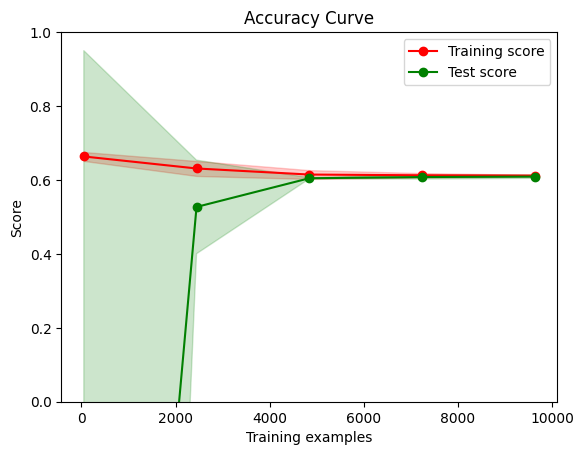

In [56]:
import matplotlib.pyplot as plt
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
plt.figure()
plt.title("Accuracy Curve")
plt.xlabel("Training examples")
plt.ylabel("Score")
# Traing score と Test score をプロット
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Test score")
# 標準偏差の範囲を色付け
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color="r", alpha=0.2)
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, color="g", alpha=0.2)
plt.ylim(0.0, 1.0)
plt.legend(loc="best")
plt.show()

### mlxtend

https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html

学習における各種チューニングなどに、mlxtendを用いることができる
- mlxtendは、機械学習やデータ分析等のタスクにおいて学習曲線のプロットやStackingなどを補助する
  - 現在のscikit-learnにも `LearningCurveDisplay`、`StackingClassifier`、`StackingRegressor` があり、公式APIも確認するとよい

mean_absolute_errorつまり、エラーの評価であるが、テストに対しては40%以上確保すれば、それなりによいことがわかる

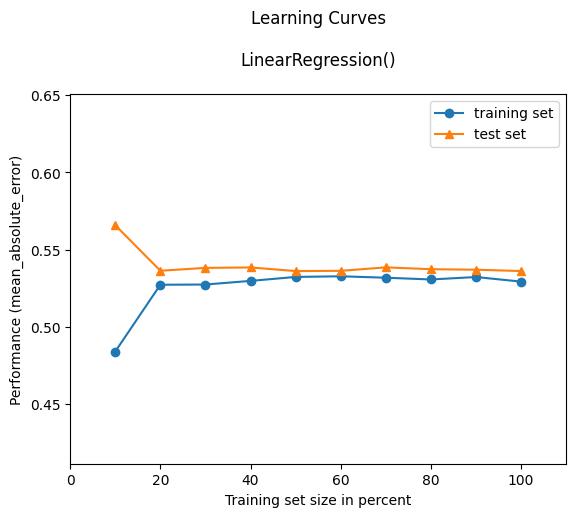

In [57]:
from mlxtend.plotting import plot_learning_curves
plot_learning_curves(X_train, t_train, X_test, t_test, model, scoring='mean_absolute_error')
plt.show()

## スケーリング

scikit-learnはスケーリングも可能である例えば、平均0、標準偏差1に変換するデータ正規化を行うには次のようにする

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

訓練データを用いて、平均と分散を計算する

In [59]:
scaler.fit(X_train)

StandardScaler()

求めた平均・分散を用い、訓練データ及びテストデータをスケーリングする
- 値の絶対値の大きさによる影響、値の偏差の大きさによる影響を抑えて評価することができる


In [60]:
# 変換
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

テストデータをスケーリングする際、訓練データ全体から求めた平均・分散を利用していることに注意する
- 各テストデータ単独で平均・分散を求めると、異なるスケールのデータで学習を行うことになるため、正しい学習結果が期待できない

また、訓練データ全体であって、検証用データを含む元のデータ全体の平均・分散でもないことにも注意する
- テストデータはモデルにとって未知のデータセットにしなければならず、全データの平均・分散を利用すると、本来知りえないテストデータの情報をモデルに与えていることになる

以下、内容確認を行うが、正規化前のX_train, X_testと比較すると良い

In [61]:
X_train_s

array([[-1.00030408,  1.8562098 , -1.146823  , ...,  0.25982829,
         0.51396387, -0.11131397],
       [-0.84938602,  1.14171192, -0.76585476, ..., -0.00327132,
         0.99993462, -1.3173838 ],
       [ 1.28620508, -0.92239307,  0.46102722, ...,  0.11210392,
        -0.82245571,  0.76084397],
       ...,
       [-0.35374656,  0.18904808, -0.77908241, ..., -0.1818844 ,
         0.44387193, -1.16288725],
       [ 0.93323448,  0.42721404, -0.38591908, ..., -0.1154139 ,
        -0.9392756 ,  0.81566532],
       [-1.31060093, -1.08117038, -0.65304797, ...,  0.05761909,
        -1.32244485,  1.99681635]])

In [62]:
X_test_s

array([[ 0.15077666, -0.5254498 ,  0.10477153, ...,  0.16599986,
        -1.42524636,  1.25423617],
       [ 1.01154901,  0.26843673,  0.29893351, ..., -0.00284492,
        -0.79909173,  0.79573028],
       [ 0.25489638,  0.03027077,  0.22177006, ..., -0.01898759,
         1.41114065, -1.13298469],
       ...,
       [ 2.11958585,  0.10965942,  0.93004803, ..., -0.09016131,
        -0.81311012,  0.82563284],
       [-0.95228951,  0.42721404,  0.22501928, ...,  0.10217786,
         0.43452634, -0.03655757],
       [ 0.42802383,  0.26843673, -0.04732252, ..., -0.038109  ,
         0.80835   , -1.20774109]])

### スケーリングされたデータを用いた訓練と検証

今回は、スケーリングを行っても結果は殆ど変わらない結果となる

In [63]:
model.fit(X_train_s, t_train)
# 訓練データ
print(model.score(X_train_s, t_train))
# テストデータ
print(model.score(X_test_s, t_test))

0.6112941337977225
0.5926087785518777


# 分類の王道

ノーフリーランチ、つまり、必ずうまくいく方法はない

大学の授業ならば、全部教えて学生を試すのも悪くないであろうが、この授業はそういう授業ではなく、やみくもに何でも試すことや全て覚えることは効率が悪い

- 普通なら通年かけて教えるような内容、それを高々10数回の授業で扱うため、使い方に専念し、例を示して、メリハリをもって効率を最大化するしかない
- 結局与えられたデータを最もよく知っているのは、そのデータを集めた人、持っている人なのだから、その人の感覚でデータサイエンスするしかない
  - 特に個別にデータの前処理を考え、最適と考える手法を順次とらざるをえない
- 残念ながら、その個別対処の感覚を教える、習得するのはなかなか難しく、データを図示して発見しそれぞれ対応していくしかない

例えばであるが、ある機械の運転振動を取得し、そこから異常つまり故障に繋がる重大な予兆を発見し壊れる前に対応する、そういうことができるなら、今すぐ会社を興してお金儲けすればよい
- だが、例えば冷房機器であれば夏の異常気象の日は、とにかくフル運転を行い、そういう状況が年2回程度しかない、ということになれば、これは普通にやれば異常と判断されてしまい、暑い日になるとあちこちで異常ではないのに、異常・異常と通知してくる欠陥システムになる
- その他、システムの再起動や、現場のメンテナンスが入った時も異常となれば、これも困る
- これらシステム負荷の高いときや、メンテナンスなどの振動を排除した結果、本当の故障に繋がる予兆を逃すことは避けたい

結局そういうせめぎあいの中で**どのようにデータを解釈し何に注目して異常と判断するのか**を探るしかない
- ここで扱うのは、この**判断する**ところであり、データの解釈や注目点については、それぞれで判断することとなる
- 要するに「各個考えて撃破せよ」ということであるが、**それでも分類を考えるなら、王道があるでしょ？**ということで、ここではSVM(Support Vector Machine)とRandom Forestを取り上げ、LightGBMについても触れる

もちろん、相手が画像やら、動画やら、音声やらを扱うならば、本格的なDNNを扱う必要があるが、それ以外の普通のデータにDNNを使うのはお芋を太陽で焼くようなものである

だが、考えようはいろいろで、初回授業でも扱った、シンプルなDNNを用いるのも、計算コストをあまり気にしないならば悪くないであろうし、DNNを使ったらカッコいいと考えるのも悪くなく、あまりよく知らない人をだましてお金を稼ぐにはよい道具であろう

一方で例えば、上記の例で、振動情報データが大量にあり、これを**画像のように扱って**DNNで捉えるというのは、あながち誤っている方法とはいえない

AIをやたらと語る悪徳業者に騙されないためにも、基本素養を身に着けておくべきであるし、ともすれば、気付かぬうちに、そいういう悪徳業者に自分のチームがなりかねない
- 「このデータはDNNの弊社システムを使って結果が出せます、〇〇万のお見積りとなります」という悪徳業者に対して、「では、私ならばその半額かつ1/4の計算量で同様の結果を出すので、逆にお勧めする、買っていただきたい」ぐらい言えばよい

## SVM(サポートベクトルマシン)とRF(ランダムフォレスト)

教師ありでデータを分類したいというのは、よくあるニーズである

タイトルはともかく、もし、SVMやランダムフォレストの選択を考えるのであれば、同様にまずはLightGBMを選択も想定するべきである
- LightGBMは勾配ブースティングを用いるRFのbaggingとは異なり、損失を減らす方向へ木を順に追加する
- 表データでは有力な候補であるが、データ量、欠損、特徴量、計算資源に応じて比較する

とはいえ、まずは、SVMとRFについて、どのように選択するのかを、次の点に着目して考えよう

1. データ数が多いか？
 - 多いなら、RFは効率が良い
 - 少ないなら、SVMは良い選択肢である

> カーネルSVMの学習時間はデータ数$n$に対して二次以上に増える場合があり、大規模データでは負担になりやすい
> - RFのコストも、木の本数、深さ、特徴量数、データ数に依存する$O(\sqrt n)$と決めて比較することはできない
> - 線形SVMやSGDによる線形分類は別の計算特性を持つため、カーネルSVMと区別する

1. 次元数は多いか？
 - RFは特徴量の候補を絞って各分岐を学習する
 - SVMも高次元・疎な特徴量に有効な場合があり、次元数だけでは決められない

1. データの軸は想定する分類に対して明確に寄与する特徴量であるといえるか？
 - いえるならば、まずはRFを試す
 - いえないならば、まずはSVMを試す

> これは、もう少し両者の本質的な違いを見つめる必要がある
> - SVMは滑らかな分離超平面を利用して分類する
>   - 境界面を美しくしやすいが、これを大量に引くのは大変
> - RFは直線的境界を引きまくって境界線を構築する
>   - つまり、その軸の特徴を前面に押し出して分類する傾向がある
>   - RFは境界面がぐちゃぐちゃ
>
> この特徴をどのように考えるか、ということであり、RFが過学習気味になりやすいといわれるのも納得であろう

但し、迷ったらまずはLightGBMやRFというのも事実であり、その主な理由はRFが以下の点で方法論としてかなり完成していることが挙げられる
- そもそもハイパーパラメータが少なく、初心者でも扱いやすいうえに、そのパラメータも触る必要は殆どない
- 標準的なbootstrapでは、各木に使われないOOB(Out-Of-Bag)データが約36.8%となり、OOB推定で汎化性能を評価できる
  - 通常の交差検証と同一ではなく、時系列や同一対象の重複がある場合は分割を別に設計する
- 特徴の重要度を求めることができるが、不純度に基づく重要度は分岐候補の多い特徴量に偏りやすい
  - 未知データでのpermutation importanceも比較し、因果関係とは区別する
- RFの予測確率は各木の葉にあるクラス比率を平均して求める
  - 独立な確率を掛け合わせる処理ではなく、確率の校正も別に確認する

といったメリットがある

もう色々面倒だ、という観点からNNを利用するという考え方もあろう



## サポートベクトルマシン

予測にはデータを使うが、外れ値のような余計なデータを使うと予測精度が低下する
- つまり**真に予測に必要な一部データのみ**を利用する必要があるが、このようなデータを**サポートベクトル**と呼ぶ

このサポートベクトルを用いる手法がサポートベクトルマシンである
- 2値分類を基本とするが、多値分類への拡張も行われている

SVMは基本的には線形分離を拡張し、$n$個の特徴量で作られる$n$次元空間上の集合を複数の$n-1$次元の超平面(**分割超平面**)で分割することで分類を行うが、特にこの平面に近いデータ(**これをサポートベクトルとする**)との距離(**マージン**)を最大化することを目的とする
- また、線形分離可能なデータを前提としたマージンを**ハードマージン**、線形分離不可能なデータを前提として、誤判別を許容するマージンを**ソフトマージン**と呼ぶ
  - ハードマージンでは、とにかく明確に領域を分割しエラーを許さないが、融通の利かない分類となる
  - ソフトマージンは、あいまいにエラーを許容して分類することになる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/svm-basis.png" width=400>

## ハードマージンによる分類

さて、重回帰分析の「Step1.モデルの決定」でも述べたが、重回帰分析では、単回帰解析の式を複数の入力変数へと拡張し、次の線形結合を考えた

$$
y=w_{1}x_{1}+w_{2}x_{2}+\ldots +w_{M}x_{M}+b
$$

これは、ここで想定する超平面と似ており、この$y=0$とした式で超平面を与えることができる
- なお、ここでは次元数を$n$とする
$$
w_{1}x_{1}+w_{2}x_{2}+\ldots +w_{n}x_{n}+b=0
$$
これを行列式でまとめてかけば、
$$W^TX + b = 0$$
となる

この超平面で分類できるとするならば、$X$について$i$番目のデータ$X_i$をこの式に代入すると、当該超平面の法線ベクトルの向きと同じ側にあるか、ないかで2分されることになる
- つまり、赤▲データが$K_1$集合、図の青★データが$K_2$集合に属するとすると、これらを分類する一つの形として$i = 1, 2, 3,\cdots,n$とすると次の式を満たすことが考えられる

$$
W^TX_i + b > 0 \quad (X_i \in K_1)\\
W^TX_i + b < 0 \quad (X_i \in K_2)\\
$$

これを式変形の都合上、一つの式で表すため、ラベル変数$t$を導入し、$i$番目のデータ$x_i$がクラス$K_1$に属するときに$t_i=1$、クラス$K_2$に属するときに$t_i=-1$とする

$$
t_i = \left\{
\begin{array}{ll}
1 & (X_i \in K_1) \\
-1 & (X_i \in K_2)
\end{array}
\right.
$$

この$t_i$を用いることで、次のように表記できる

$$t_i(W^TX_i + b) > 0 \quad (i = 1, 2, 3, ...n)$$

マージン$M$はn次元空間上の点と超平面の距離$d_i$を求めることになり、

$$
d_i = \frac{|w_1x_1 + w_2x_2... + w_nx_n + b|}{\sqrt{w_1^2+w_2^2...+w_n^2}} = \frac{|W^TX_i + b|}{||w||}
$$

と表すことができ、これを最大化することから、

$$
\mathrm{max}_{w, b}M, \frac{t_i(W^TX_i + b)}{||W||} \geq M  \quad (i = 1, 2, 3, ...N)
$$

ここで、$\frac{t_i(W^TX_i + b)}{||W||} \geq M $の両辺をMで割り、$
\frac{W}{M||W||} = \tilde{W}$さらに、$\frac{b}{M||W||} = \tilde{b}
$と置き換えれば、次の式を満たす最大の$M$を求めることになる

$$
t_i(\tilde{W^T}X_i + \tilde{b}) \geq 1
$$

さて、$\tilde{W}$や$\tilde{b}$と同様に$\tilde{M}$を考えると、$
\tilde{M}=\frac{M}{M||W||}=\frac{1}{||W||}$となり、これを用いて、

$$
\mathrm{max}_{\tilde{W}, \tilde{b}}\frac{1}{||\tilde{W}||}, \quad　t_i(\tilde{W^T}X_i + \tilde{b}) \geq 1 \quad (i = 1, 2, 3, ...N)
$$

となる

$\frac{1}{||\tilde{W}||}$はL1ノルム($L_1=|x_1|+|x_2|+\cdots +|x_n|$)の逆数を最大化することであり、意味を変えずに扱いやすいように変形する
- 例えば、L2ノルム$L_2=\sqrt{x_1^2+x_2^2+\cdots +x_n^2}$の二乗の半分を最小化するというよくある解釈をすると次のようになる

$$
\mathrm{min}_{W, b}\frac{1}{2}||\tilde{W}||^2, \quad t_i(\tilde{W}^TX_i + \tilde{b})\geq 1 \quad (i = 1, 2, 3, ...N)
$$


## ソフトマージンによる分類

ハードマージンのみ想定すると、誤りのない境界しか想定できないため、融通が利かない
- そこで、誤りをある程度認めるソフトマージンを考える

具体的には、

$$
\mathrm{min}_{W, b}\frac{1}{2}||\tilde{W}||^2, \quad t_i(\tilde{W}^TX_i + \tilde{b})\geq 1 \quad (i = 1, 2, 3, ...N)
$$

この条件を緩和する必要がある
- 緩和は簡単に行うことができる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/svm-soft.png" width=400>

マージンに入り込んで境界を明確に定められない赤▲や青★、例えば$X_i$は、先ほどの条件式の$\geq 1$を満たすことはできないかもしれないが、例えば$\geq 0.5$ならば満たすことができるかもしれない
- そこで、スラッグ変数$\xi$を導入し制約条件を緩めるという方針をとる

$$
t_i(\tilde{W}^TX_i + \tilde{b})\geq 1 - \xi_i \\
\xi_i = \mathrm{max}\Bigl\{0, \tilde{M} - \frac{t_i(\tilde{W}^TX_i + \tilde{b})}{||\tilde{W}||}\Bigr\}
$$

ここで、$\tilde{}$を省略し、全ての$X_i$についてこの条件を当てはめれば、マージン最小化問題は次のように表すことができる

$$
\mathrm{min}_{W, \xi}\Bigl\{\frac{1}{2}||W||^2 + C\sum_{i=1}^{N} \xi_i\Bigr\}\\
cond. \quad
t_i(W^TX_i + b)\geq 1 - \xi_i\\
\xi_i = \mathrm{max}\Bigl\{0, M - \frac{t_i(W^TX_i + b)}{||W||}\Bigr\} \quad
i = 1, 2, 3, ... N
$$

ここで、最小化条件に$C\sum_{i=1}^{N} \xi_i$が加えられている点に注意する
- これは、スラッグ変数$\xi$自体が、なるべく小さい値であるべきという条件を意味し、どれだけ緩和するか？を調整するためハイパーパラメータ$C$が重みとして与えられている
- $C$は、一般にコストパラメータと呼ばれている

## ラグランジュの未定乗数法の利用

この式を直接解かずに、別の式、すなわち**双対問題**を用いて最適化問題を解く- ここではラグランジュの未定乗数法を用いる

[高校数学の美しい物語](https://mathtrain.jp/mlm)という名前のおかしいサイトが詳しい

既に学習した形を以下のように拡張して用いる
- 目的関数$f(X)$を$n$個の不等式制約$g(X)_i \geq 0, i=1,2,3,\cdots,n$の条件下で最小にするとは、ラグランジュ関数$L(X, \alpha) = f(X) + \sum_{i=1}^{n}\alpha_ig_i(X)$について次の条件を満たす$(\tilde{X}, \tilde{\alpha})$を求めることである

$$
\frac{\partial L(X, \alpha)}{\partial X}=0\\
\frac{\partial L(X, \alpha)}{\partial \alpha_i} = g_i(X)\leqq 0, \quad (i=1, 2,... n)\\
0 \leqq \alpha, \quad (i = 1,2, ...n)\\
\alpha_ig_i(X) = 0, \quad (i = 1, 2,...n)
$$

さて、今回のラグランジュ関数は、目的関数($\mathrm{min}$の式)から、

$$L(W,b,\xi,\alpha,\beta)=\\
\frac{1}{2}||W||^2 + C\sum_{i=1}^{N} \xi_i-\sum_{i=1}^{N}\alpha_i\bigl\{t_i(W^TX_i+b)-1+\xi_i\bigl\}-\sum_{i=1}^{N}\beta_i\xi_i
$$

となり、

$$
\frac{\partial L(W,b,\xi,\alpha,beta)}{\partial W}= W - \sum_{i=1}^{N}\alpha_it_iX_i=0\\
\frac{\partial L(W,b,\xi,\alpha,\beta)}{\partial b}= -\sum_{i=1}^{N}\alpha_it_i = 0\\
\frac{\partial L(W,b,\xi,\alpha,\beta)}{\partial W} = C - \alpha_i -\beta_i = 0
$$

を解けばよい

整理すると、

$$
W =\sum_{i=1}^{N}\alpha_it_iX_i\\
\sum_{i=1}^{N}\alpha_it_i = 0\\
C = \alpha_i + \beta_i
$$

となる

これをラグランジュ関数に代入して整理すると、

$$
\tilde{L}(\alpha) = \sum_{i=1}^{N}\alpha_i - \frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}\alpha_i\alpha_jt_it_j{X_i}^TX_j
$$
となる

結果的に、下記条件を満たす$\alpha$を求めればよい

$$
max\Bigl\{{\tilde{L}(\alpha) = \sum_{i=1}^{N}\alpha_i - \frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}\alpha_i\alpha_jt_it_j{X_i}^TX_j\Bigr\}}\\
\sum_{i=1}^{N}\alpha_it_i = 0, \quad 0 \leqq \alpha_i \leqq C, i = 1,2,...N
$$







## サンプルコード

ここで、実際にSVMを用いて分類を行う
- 例として、次のコードはある動物の身長と体重を$x$、雄・雌の種別を$t$として与えてこれをSVMを用いて分類する
- さらに、特に工夫のない線形分離を用いて行う

In [64]:
from sklearn.svm import SVC
import numpy as np
x = np.array([[12, 15], [10, 20], [13, 23], [10, 30], [13, 36], [12, 39]])
t = np.array([0, 0, 0, 1, 1, 1])
model = SVC(kernel='linear', random_state=None)
model.fit(x, t)
from sklearn.metrics import accuracy_score
t_p = model.predict(x)
accuracy = accuracy_score(t, t_p)
accuracy

1.0

精度が1.0つまり、100%となり完全正解となるが、以下のようにデータを見ると「さもありなん」ということがわかる
- ここでは、様々な手法をあえて伝えるという観点から、mlxtendを用いて表現する

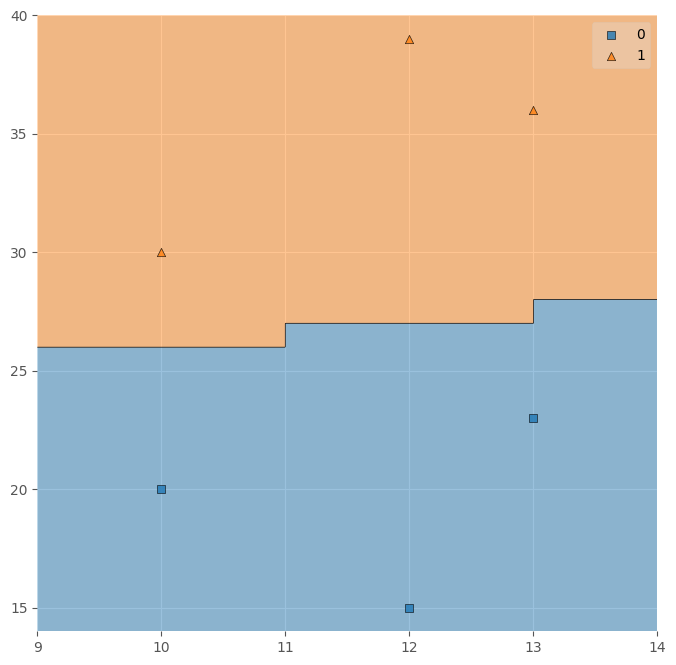

In [65]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
plt.style.use('ggplot')
fig = plt.figure(figsize=(8,8))
plot_decision_regions(x, t, clf=model)
plt.show()

直線で完全に分離可能であることがわかる
- 実際の分類結果は次の通りである

In [66]:
t_p

array([0, 0, 0, 1, 1, 1])

さて、SVMが正しく分類できることが分かったところで、弱点を突く問題を与える
- 以下のようなデータを用いて同様に学習させる
- 精度は72%、良くはないが、何かしら学習ができたかのように見える

In [67]:
from sklearn import svm
import numpy as np
x = np.array([[12, 10], [12, 15], [10, 20], [13, 22], [10, 34], [13, 36],
  [12, 39], [12, 37], [12, 25], [12, 29], [11, 27]])
t = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1])
model = SVC(kernel='linear', random_state=None)
model.fit(x, t)
from sklearn.metrics import accuracy_score
t_p = model.predict(x)
accuracy = accuracy_score(t, t_p)
accuracy

0.7272727272727273

同様に結果を視覚化する

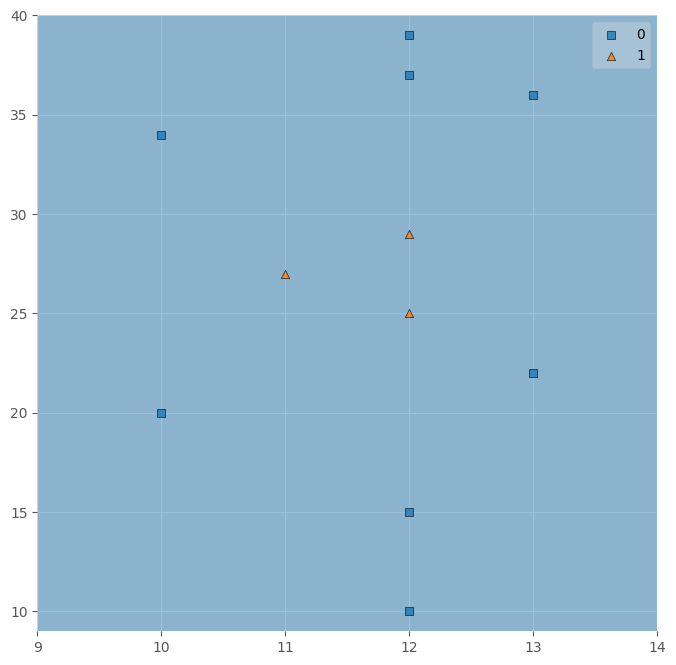

In [68]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
plt.style.use('ggplot')
fig = plt.figure(figsize=(8,8))
plot_decision_regions(x, t, clf=model)
plt.show()

結果を見ると、今度は赤つまり雌の個体が雄の個体の中に囲まれるように存在するため、直線で分離することはできない
- 結局全体を雄と判定する道をえらんでしまった
- 確認すると、次のように全て0=雄と判定している


In [69]:
t_p

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## カーネル法の利用

カーネル法(kernel method)はデータを高次元の特徴空間上へ写像することで分類を易化する手法で、より分かりやすく言えば、先ほどの失敗したデータに何かしら工夫をすれば、SVMの線形分離で分類できるのではないか、と考える

まずは、その概念を理解する
- $x=[x_1, x_2]$として、例えば、$(X_1+X_2-39)^2$を計算すると次のようになる
  - sumメソッドは、要素の合計を求め、axisで合計の方向を行としている
  - -39と記述しているがブロードキャストという手法により行列の全要素について計算される

In [70]:
newx = (x.sum(axis=1)-39)**2
newx

array([289, 144,  81,  16,  25, 100, 144, 100,   4,   4,   1])

pythonに慣れてもらうために別の方法も記しておく
- 0番目の要素と1番目の要素は記述できるため次のようしてもよい

In [71]:
newx = (x[:,0]+x[:,1]-39)**2
newx

array([289, 144,  81,  16,  25, 100, 144, 100,   4,   4,   1])

いずれも等しい配列を与えるが、これに対して10未満という条件を与えると、条件式もブロードキャストされ、次のような結果を得る
- FalseとTrueは条件で偽および真を与え、条件が成立しなかった、成立した、を表す
- なお、int(True)は1、int(False)は0となる

In [72]:
newx<10

array([False, False, False, False, False, False, False, False,  True,
        True,  True])

少し寄り道するが、次のように記述するとTrueが何番目の配列の要素かを知ることができる
- enumerateは配列の要素番号と値を与える

In [73]:
[i for i, x in enumerate(newx) if x < 10]

[8, 9, 10]

さて、グラフを描く際に、10未満のデータについては赤つまりr、それ以外は青つまりbで記述したい
- 先ほどのnewxについて、bおよびrを与える配列を生成するには、次のようにすると美しい

In [74]:
[['b','r'][int(i<10)] for i in newx]

['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'r', 'r', 'r']

この辺りがpythonがトリッキーで面白いと感じるところかもしれない
- 脱線ついでにどんどん脱線する
- 例えば、より素直な方法として、つぎのように記述するとよく、今回はこれが最も短くなり、お勧めである

In [75]:
['r' if i<10 else 'b' for i in newx]

['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'r', 'r', 'r']

3項演算子も含んだ形として

**[式1 if 条件式1 else 式2 for 変数名 in リスト if 条件式2]**

とすると、リストのうち条件式2を満たす要素について、その値が条件式1を満たすなら式1、満たさなければ式2の値を要素とする配列となる
- 各条件式の部分は省略できる

さらに脱線すると、ラムダ式を用いると次のようにもできる

In [76]:
list(map(lambda x: 'r' if x<10 else 'b', newx))

['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'r', 'r', 'r']

このように段階を踏んでくれれば何とかなるだろうが、いきなり次のように記述されると、なかなかつらいのではないだろうか

In [77]:
['r' if i<10 else 'b' for i in (x.sum(axis=1)-39)**2]

['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'r', 'r', 'r']

もっと脱線してみよう
- 簡単な関数を定義してもよいならば、次のようにも記述できる
- map関数はシーケンスを返すためlist関数を利用する必要がある

なお、処理速度が遅くお勧めではないが、関連する項目として**numpy.apply_along_axis**があるので各自調べると良いであろう

言いたいことは、**pythonは自由度が少なく、決められた書き方に従うため、ソースコードが読みやすいなどという迷信を吹き込むのはやめてくれ**である


In [78]:
def borr(n):
  return 'r' if n < 10 else 'b'
list(map(borr, newx))

['b', 'b', 'b', 'b', 'b', 'b', 'b', 'b', 'r', 'r', 'r']

脱線したが、次のように色分けして表示する
- もうわかっていただけたかと思うが、何かしらの変換に基づく計算により直線分割可能な形に変換できたことになり、これをカーネル法と呼ぶ、またこのような変換そのものをカーネルと呼ぶ

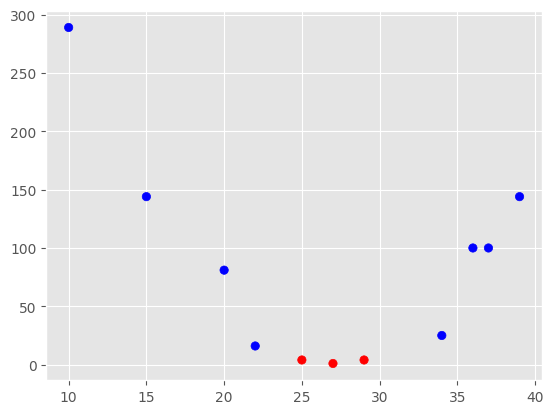

In [79]:
plt.scatter(x[:,1], newx, c=['r' if i<10 else 'b' for i in newx])
plt.show()

さらに脱線ついでに、matplotlib scatterの新しい機能を利用するならこういう書き方になるが、legendが必要ない場合は逆に面倒

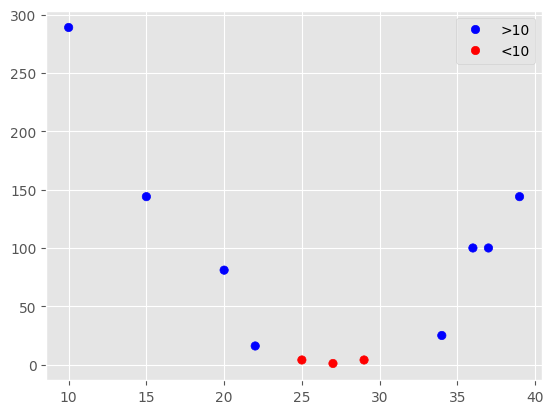

In [80]:
from matplotlib.colors import ListedColormap
scatter = plt.scatter(x[:,1], newx, c=[newx<10], cmap=ListedColormap(['b', 'r']))
plt.legend(handles=scatter.legend_elements()[0], labels=['>10','<10'])
plt.show()

では、そのような都合の良い関数をどのように見つけるのか
- 実は、見つけるのではなく、作ってしまうと考えた方が良い

まず、基本となる**データを高次元の特徴空間上へ写像する**という考えを数式化する
- ここで、与えられたデータが構成する**入力空間**を高次元化するために利用する空間を**高次元特徴空間**と呼ぶ
- この$n$次元入力空間を$r(r>n)$次元高次元特徴空間に変換する関数を次のように定義する
$$
\psi(X) = (\varphi_1(X), \varphi_2(X), \varphi_3(X), \cdots,\varphi_r(X))
$$
適切な特徴空間で線形分離しやすくなる場合があるが、1次元増やせば任意のデータが分離できるという保証はない
- 同じ入力に異なるラベルが付いた場合など、完全分離できないデータもあり、ソフトマージンで誤りを許容する

先に示した、
$$
max\Bigl\{{\tilde{L}(\alpha) = \sum_{i=1}^{N}\alpha_i - \frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}\alpha_i \alpha_jt_it_j{X_i}^TX_j\Bigr\}}\\
\sum_{i=1}^{N}\alpha_it_i = 0, \quad 0 \leqq \alpha_i \leqq C, i = 1,2,...N
$$
について、高次元特徴空間に写像すると、
$$
max\Bigl\{{\tilde{L}(\alpha) = \sum_{i=1}^{N}\alpha_i - \frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}\alpha_i\alpha_jt_it_j{\psi(X)_i}^T\psi(X)_j\Bigr\}}\\
\sum_{i=1}^{N}\alpha_it_i = 0, \quad 0 \leqq \alpha_i \leqq C, i = 1,2,...N
$$
となる

ここで、カーネル関数$K$を

$$K(X_i, X_j) = {\psi(X)_i}^T\psi(X)_j$$

とする

この$\psi(X)$を直接計算せずに内積を計算できるような$K$が容易に得られればよく、このような$K$を用いた手法を**カーネルトリック**と呼ぶ
- この辺りの中二病感満載のネーミングセンスは嫌いではない

具体的には、次のようなカーネル関数が用いられる

**ガウスカーネル**
$$
K(X_i, X_j) = exp\left(-\frac{||X_i -X_j||^2}{2σ^2}\right)
$$

**多項式カーネル**
$$
K(X_i, X_j) = (X_i^TX_j + c)^d
$$

**シグモイドカーネル**
$$
K(X_i, X_j) = tanh(bX_i^TX_j + c)
$$

ガウスや適切な係数の多項式カーネルでは、特徴空間の内積を直接計算せずに評価できる
- 内積に対応するにはGram行列が半正定値となる条件が必要であり、シグモイドは任意の係数でこの条件を満たすわけではない


では、よくあるアイリス(アヤメ)の種別分けを行う学習データを用いて、カーネル関数の効果を確認する

**Iris (アヤメの計測データ、通称：アイリス)**

“setosa”, “versicolor”, “virginica” という 3 種類の品種のアヤメのがく片 (Sepal)、花弁 (Petal) の幅および長さを計測したデータ

| | |
|:-:|:-:|
| レコード数 | 150 |
| カラム数 | 4 |
| 主な用途 | 分類 (Classification) |

各カラムの構成

| | |
|:-:|:--|
|sepal length (cm)|	がく片の長さ|
|sepal width (cm)|	がく片の幅|
|petal length (cm)|	花弁の長さ|
|petal width (cm)|	花弁の幅|

irisの分類として、ここでは一般的に利用され、かつ効果を視覚的に確認しやすいガウスカーネルを用いる

次の例では、2つの$C$と2つの$\gamma$を想定し、全ての組み合わせを試しているすべての組み合わせは、product関数を用いて生成している
- なお、productはitertoolsと呼ばれる効率的なループ実行となめのイテレータ生成関数の一つであり、階差数列的なイテレータ、決められたループをめぐるイテレータ、順列や組み合わせによるイテレータなど、様々なイテレータを構成できる(https://docs.python.org/ja/3/library/itertools.html)
- productは入れ子構造を持つforループを記述したのと同じ効果がある

まず、コストパラメータは、ガウスカーネルに関わらず存在し、$C$が小さいほど誤分類を許容し、よりソフトマージンとなるように超平面を決定する

次に、$\gamma$は、ガウスカーネルの式を次のように記述しなおした時の$\gamma$を表し、値が小さいほど単純な決定境界となり、大きいほど複雑な決定境界となるが、あまりにも大きな値では過学習気味になる

$$
K(X_i, X_j) = exp\left(-\frac{||X_i -X_j||^2}{2σ^2}\right)\\
=exp\left(-\gamma||X_i -X_j||^2\right)
$$

横軸と縦軸は用いた2つの特徴量を表す
- コストパラメータ$C$が小さいときは決定領域の中に多くの誤分類点を含み、$C$が大きいときは誤分類点が少ないことがわかる
- さらに、$\gamma$が小さいときの決定境界は単純な直線で構成された決定境界が記述されているが、$\gamma$が大きい場合は複雑な形となる
  - より極端な$\gamma$を与えると、各点毎に丸い境界が現れる

おおよそ感覚で何をしているのかがつかめたのではないかと思うが、ガウスカーネルでは、ガウス分布を当てはめることで選びたい点が集まっているところとその周辺が特徴として表れるようにし、その後改めてリニアSVMで分類しているとわかる

なお、今回は乱数に種(seed)を与えていないので、各々異なる結果になる点に注意すること



[SVC(C=0.03125, gamma=3.0517578125e-05), SVC(C=0.03125, gamma=8), SVC(C=32768, gamma=3.0517578125e-05), SVC(C=32768, gamma=8)]


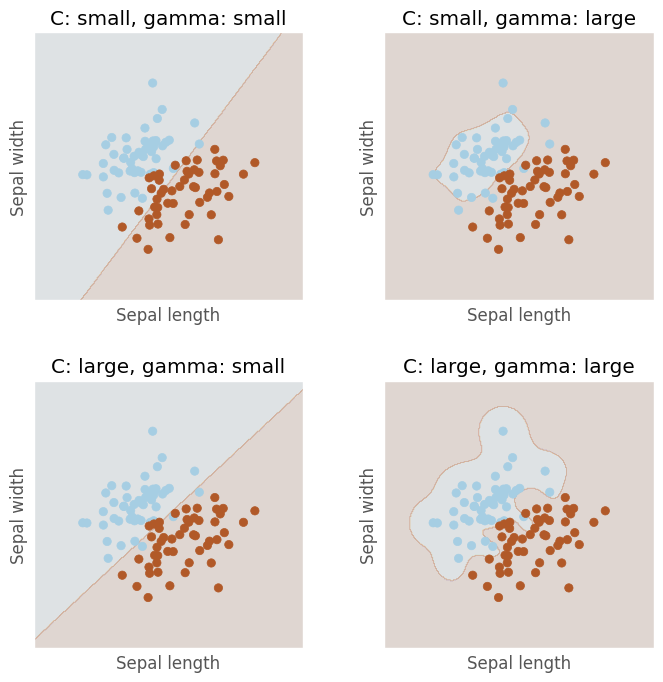

In [81]:
from sklearn import svm, datasets
import matplotlib.pyplot as plt
from itertools import product
iris = datasets.load_iris()
#特徴量は最初の2つかつデータも100個のみ使う
X = iris.data[:100, :2]
#オリジナルデータはかなり正確に分けることができるため、あえて特徴量にノイズを加える
E = np.random.uniform(0, 1.0, size=np.shape(X))
X += E
y = iris.target[:100]
#meshのステップサイズ
h = 0.02
#コストパラメータ
Cs = [2 ** -5, 2 ** 15]
#RBFカーネルのパラメータ
gammas = [2 ** -15, 2 ** 3]
#product関数は、全ての組み合わせを求める関数である
svms = [svm.SVC(C=C, gamma=gamma).fit(X, y) for C, gamma in product(Cs, gammas)]
#生成した4つのSVCのそれぞれのパラメタを確認する
print(svms)
titles = ["C: small, gamma: small", "C: small, gamma: large",
  "C: large, gamma: small", "C: large, gamma: large"]
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
plt.figure(figsize=(8, 8), dpi=100)
for i, clf in enumerate(svms):
  plt.subplot(2, 2, i + 1)
  plt.subplots_adjust(wspace=0.3, hspace=0.3)
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.1)
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
  plt.xlabel("Sepal length")
  plt.ylabel("Sepal width")
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.xticks(())
  plt.yticks(())
  plt.title(titles[i])
plt.show()

テストデータの分割とは異なるが、グリッドサーチについてもここで簡単に触れておく
- グリッドサーチは指定した**ハイパーパラメータ**の全ての組み合わせに対して学習を行い、もっとも良い精度を示したパラメータを採用する方法である
- scikit-learnにはGridSearchCVが提供されている

GridSearchCVはPythonのディクショナリでパラメータの探索リストを渡すと全部試行しスコアを返すことができる
- 以下、簡単に動作を確認するが、既に学んだ内容を多く含むので、一気に混同行列を求めるところまで進める
- 途中結果が次々表示され、解析におよそ1分弱かかる

In [82]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
### 探索するパラメータ空間の一覧をnumpyの機能で指定
def param():
  ret = {
    'svc__C':[1, 10, 100],
    'svc__kernel':['rbf', 'linear', 'poly'],
    'svc__degree':np.arange(1, 6, 1),
    'svc__gamma':np.linspace(0.01, 1.0, 50)
  }
  return ret
# データ準備、ここではirisデータを用いる
x = load_iris().data
y = load_iris().target
# データを分割
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, stratify=y, random_state=42)
# GridSearchCVのインスタンスを作成しつつ学習させる
gscv = GridSearchCV(make_pipeline(StandardScaler(), SVC()), param(), cv=4)
gscv.fit(x_train, y_train)
# スコア一覧を取得する
gs_result = pd.DataFrame.from_dict(gscv.cv_results_)
gs_result.to_csv('gs_result.csv')

大量にログが出力されたが、その結果はgs_result.csvというファイルに保存されており、右のメニューからファイルタブを選ぶとそのファイルの存在が確認できるはずである
- ダブルクリックすると中身を見ることができる
- このファイルも2250行存在するため、見たところで何がうれしいということもないが、このように様々なハイパーパラメータを一気に試すことができる

最高性能をたたき出したモデルを取得し、テストデータを分類してみる

In [83]:
best = gscv.best_estimator_
pred = best.predict(x_test)
# 混同行列を出力
confusion_matrix(y_test, pred)

array([[12,  0,  0],
       [ 0, 13,  0],
       [ 0,  2, 11]])

これぐらいお手軽にハイパーパラメータチューニングができるなら、パラメータチューニングが面倒だというデメリットはあまり気にならないんじゃない？という考えも誤りではない

# 決定木



## ランダムフォレストの基本である決定木

決定木とは、木構造により細分化して判断するモデルである
- 例えば、動植物の分類は決定木の一つといえる

いきなりだが、次のコードを用いて実際に動かしてみる
- ここでは、物件選びを想定する

dataは、様々な条件を持つ物件で、ある人が借りたいか、借りたくないかを選んだ表である
- "buy"はTrueが借りる、Falseが借りないを意味し、これが目的変数であり他は説明変数となる
- "high"は部屋の階数を表す
- "size"は部屋の広さを表す
- "autolock"はオートロックがついているかどうかを表し、1がついていることを、0がついていないことを意味する




In [84]:
import pandas as pd
data = pd.DataFrame({
        "buy(y)":[True,True,True,True,True,True,True,False,False,False,False,False,False],
        "high":[4, 5, 3, 1, 6, 3, 4, 1, 2, 1, 1,1,3],
        "size":[30, 45, 32, 20, 35, 40, 38, 20, 18, 20, 22,24,25],
        "autolock":[1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,1,0]
    })
data

,buy(y),high,size,autolock
0,True,4,30,1
1,True,5,45,0
2,True,3,32,1
3,True,1,20,1
4,True,6,35,1
5,True,3,40,1
6,True,4,38,1
7,False,1,20,0
8,False,2,18,0
9,False,1,20,0


このテーブルから、実際に特徴量$X$と教師ラベル$y$を作成する

なお、pandasでは位置の指定方法として、
- at, loc : 行名（行ラベル）、列名（列ラベル）
- iat, iloc : 行番号、列番号
がある

In [85]:
y = data.loc[:,["buy(y)"]]
X = data.loc[:,["high", "size","autolock"]]
print(y)
print(X)

    buy(y)
0     True
1     True
2     True
3     True
4     True
5     True
6     True
7    False
8    False
9    False
10   False
11   False
12   False
    high  size  autolock
0      4    30         1
1      5    45         0
2      3    32         1
3      1    20         1
4      6    35         1
5      3    40         1
6      4    38         1
7      1    20         0
8      2    18         0
9      1    20         0
10     1    22         0
11     1    24         1
12     3    25         0


さて、これをもとに分類して判断しようとするのは、分かりやすい発想であり、例えば、次の方針は腑に落ちるであろう

<img src='http://class.west.sd.keio.ac.jp/dataai/text/tree1.png' width='40%'>

このような判断手法を*決定木*と呼び、基本は2分岐・2分木となる

各項目をどの順番に選ぶのかが重要となるが、感覚としては**なるべく純粋に(混じりけなく)選択できる項目をトップにもっていきたい**と思うであろう

純粋とは、分岐した先で同じ項目がまた分岐に使われるのは避けたい、ということであり、また存在したとしてもなるべくどちらかに偏っているようにしたいということである



## 不純度

**不純度**はデータがどれだけばらついているかを表す指標ともいえる

完全に分類できれば不純度0となり、回帰では１つのノード内でデータの分散が0であれば不純度0となる

不純度として使える指標はいくつかあり、一般に用いられるのが、**エントロピー**と**ジニ係数**である


### エントロピー

エントロピーは情報量を平均化した指標であり、情報量のばらつき具合を示し、稀に起こる事象ほどエントロピーは大きく、情報として有用と判断される

$$
H = \sum_{i=1}P(x_i)I(x_i) = -\sum_{i=1}P(x_i)\log_{2}P(x_i)
$$

ここで、$H$はエントロピー、$I(x_i)$はある事象$x_i$に対する情報量を指す

例えば
- 沖縄で晴れの確率を0.8、曇りの確率を0.05、雨の確率を0.15とする
  - 沖縄の天気のエントロピー：0.884
- 関東で晴れの確率を0.6、曇りの確率が0.20、雨の確率が0.20とする
  - 関東の天気のエントロピー：0.953

つまり、関東の天気のエントロピーはより値が大きく、ばらつきが大きいといえる

不純度の定義に従えば、その最低値はエントロピーも0となり、不純度の高くなるほどエントロピーは大きくなる
- 不純度もエントロピーもばらつき具合を示す指標であり不純度として利用できるであろう

決定木では、分岐前と後のエントロピーを計算し、上層の分岐より下層の分岐の方がよりエントロピーが小さくなる、つまりその差が最大となる分岐条件を探すことでモデルを構築する

### ジニ係数

ジニ係数は誤分類する確率を平均化した指標であり、誤分類をどの程度しそうかの指標である

あるノード$t$においてクラス$x_i$が選ばれる確率を$P(x_i \mid t)$とすると、ジニ係数$G$は、クラス数$K$とすると、次のように表現できる

$$
G(t) = \sum_{i=1}^{K}P(x_i \mid t)\left(1-P(x_i \mid t)\right) = 1-\sum_{i=1}^{K}P(x_i \mid t)^2
$$

不純度の定義に従えば、その最低値はジニ係数も0、不純度が高くなるほどジニ係数は大きくなる
- ジニ係数を用いて不純度を計算することができるといえ、エントロピー同様、モデルが構築できる

## モデル構築

さて、実際にモデルを構築しよう

In [86]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
#下記は決定木可視化のためのツール
import graphviz
import pydotplus
from IPython.display import Image
from io import StringIO # 新しいバージョンのScikit-learn
#from sklearn.externals.six import StringIO # 古いバージョンのScikit-learn

先のデータを使ってモデルを構築する\
いとも簡単にあっさりと終る

In [87]:
clf = DecisionTreeClassifier()
clf = clf.fit(X, y)

一応確認するが、正答率は100%、Accuracyは1.0である

In [88]:
print(clf.predict(X).tolist())

[True, True, True, True, True, True, True, False, False, False, False, False, False]


モデルを可視化する

決定木の利点の一つが可視化した際のわかりやすさにある

[False  True]


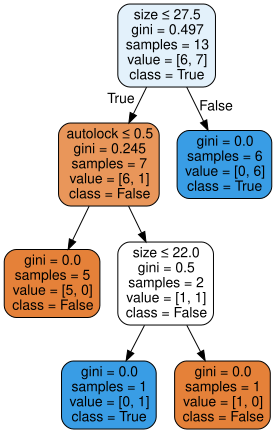

In [89]:
dot_data = StringIO() #dotファイル情報の格納先
export_graphviz(clf, out_file=dot_data,
  feature_names=["high", "size","autolock"],# 特徴量の名称
  class_names=["False","True"],# 分類名、print(clf.classes_)の結果の通りにいれる
  filled=True, rounded=True,
  special_characters=True)

# pydotplus のパーサーエラーを回避するため、graphviz.Source を直接使用します
print(clf.classes_) #この結果が[False True]であるため、class_namesもこれに揃える
graph = graphviz.Source(dot_data.getvalue())
graph

### 分岐の見方

可視化の際には、どの特徴量で可視化するのか、またクラスはどの順番で記述するのかといった情報が必要となる

ここでは、
`feature_names=["high", "size","autolock"]`
として利用したすべての特徴量について可視化し、そのクラスの順序は、
`print(clf.classes_)`
として得られた結果を用いる

上から順番に説明する

---
**最上位(Root)ノード(gini=0.497)**

---
- 次の分岐条件：部屋の大きさ$size \leq 27.5$ という条件で次の分岐が行われ、Trueの場合左、Falseの場合右に分岐、以下同様
- gini係数：0.497
- sample(推定された所属サンプル数)：13
- value：正解ラベルが6個と7個で構成されていることを示す
  - ややこしいがこの場合valueは$[False:True]$であり、`clf.classes_`の結果に従うこと
  - 実際に予測による分類は次の層の分岐ノードの数でわかり、この場合$size \leq 27.5(True) : size \gt 27.5(False) =7:6$に分類されている
    - 先走って説明すれば、分類は1つここには含まれておらず(下の層で正しく分類できている可能性もあるため、失敗しているわけではない)、False側つまり、$size \gt 27.5$に所属した6件は全て正解している
- class：Leafの場合は予測されたクラス
  - Leafでない場合は所属する支配的なクラス分類(数の多い方)が示され、同数の場合優先されるラベルが記される
  - ここではRootは6:7でTrue(借りる)が支配的
---
**第2層(gini=0.245)**

---
- Rootノードの分岐で$size \leq 27.5$に該当
- 次の分岐条件は、$autolock = 0$である(autolockはTrueかFalseであるため)
- gini係数：0
- sample(推定された所属サンプル数)：7
- value：正解ラベルは$[6,1]$である
- class：False(借りない)が支配的
---
**第2層(gini=0)**

---
- Rootノードの分岐で$size \gt 27.5$に該当
- 次の分岐条件の記載がないためLeafノードである
- gini係数0
- sample(推定された所属サンプル数)：6
- value：実際の正解ラベルは全てTrueで6個所属しているため、分類されたサンプルはすべて正解
- class：LeafでありＴrue(借りる)と推定
---
以下同様で、valueの片方が0となっているのがリーフに相当し末端となる
---

- Rootが部屋の広さで分類され、かつジニ係数が最も大きいため、部屋の広さが一番重要であったとわかる


autolockのように0,1の2値設定した場合は、分岐条件が0.5を境界として分類されている
- 具体的には、0.5以上が1でオートロック有、0.5未満が0でオートロック無を表す



### 推論
この予測モデルを使って、別物件データについて借りるか借りないかを予測する

次の2つのデータを用いる

In [90]:
z = pd.DataFrame({
        "high":[2, 3],
        "size":[25, 28],
        "autolock":[1,0]
    })
z2 = z[["high", "size","autolock"]].values

予測を立てるにはpredict関数を呼び出すのがscikit-learnのやり方

In [91]:
y_est = clf.predict(z2)
y_est

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([False,  True])

2つの物件について予測結果はFalse, Trueとなり、借りない、借りるという結果になった


### 問題点

このような決定木は過学習となるため実応用ではほぼ利用されない
- 与えられたデータを全て分類しきるため、例えば、説明変数の表現空間上で近い場所にあるデータに対して、本来であればエラーであるとして曖昧に境界を引きたいところが、これらを全て区別することになる
- SVMにおいて、$C$や$\gamma$をとてつもなく大きな値にしたようなイメージである

しかしながら、このような決定木をうまく利用するのが、次の王道ランダムフォレストである

# ランダムフォレスト

ランダムフォレストは、簡単に言えば、大量にシンプルかつ乱雑な決定木を作成し、その大勢を用いて判断するモデルに基づく分類手法である
- この基本となる**大勢を用いて判断する**という部分を理解するために、アンサンブル学習について触れる
- アンサンブル学習はランダムフォレスト以外でも、複数の学習モデルを組み合わせるときの考え方として応用されている

## アンサンブル学習

アンサンブル学習には主に**バギング**という手法と**ブースティング**という手法がある

ランダムフォレストはバギングをベースに予測を行う

### バギング (Bagging)

元データから一部のデータを**復元抽出**により、リサンプリングする手法をブートストラップと呼び、重複してサンプリングすることを許す(ブートストラップサンプリング)

- ブートストラップは、データベースからサンプリングしては戻し、サンプリングしては戻す復元抽出をして、たくさんのサンプルを作り出す方法

バギングとは**ブートストラップ**を用いて複数のモデルである弱学習器を作成、並列的に学習させる方法であり、新しい入力データに対して分類として多数決を用い、回帰として平均を予測に用いる

- ランダムフォレストはバギングを利用

### ブースティング (Boosting)
複数モデルについて学習を直列に進める手法で、前のモデルの結果を参考にして次のモデルを構築する

- バギングのように弱学習器を独立に作らず、k 個目に作った弱学習器をもとに(弱点を補うように)k+1 個目の弱学習器を構成するといった、順番に弱学習器を構成する手法
- LightGBMはブースティングを利用

## スタッキング (Stacking)

複数の学習器を利用し、データを積み上げて精度を上げる手法であり、二段階以上の段階を踏みながらデータを積み上げる大まかな流れは次の通り
- 第1段階として、学習器に複数のモデルを用意するこれらのモデルはバラバラでよい
- より多様なモデルを準備した方が精度が向上する傾向にある
- これらのモデルそれぞれから予測値を出力させる
- 第2段階として予測値をまとめたメタモデルを作成する
- メタモデルから最終予測値を作成する
- メタモデルをさらに積み上げて第3段階以降を構築する場合もある

スタッキングにより様々なモデルやアルゴリズムを利用して結果を獲得するため、場合に応じて出力される予測値を選択できることから、精度向上を狙える

一方で、設計が煩雑になり、計算コストも増大するまた、スタッキングを用いたからと言って、必ずしも精度の良い結果になるとは限らない

スタッキングは、Kaggleなどで上位を狙う場合の常套手段として利用されていることからも、精度向上に対して有効な手段として認識されている

メタモデルを学習するときは、各サンプルを学習に使わなかったモデルの予測(out-of-fold予測)を利用する
- 学習済みモデルが自分の訓練データへ出した予測をそのまま使うと、過学習した情報が伝わる
- `StackingClassifier` などは、内部の交差検証でこの処理を行う


## ランダムフォレストの考え方

ランダムフォレストはアンサンブル学習のバギングをベースに、少しずつ異なる決定木をたくさん集めることで、決定木単体で用いた場合に陥る過学習の問題に対応した手法である
- ランダムフォレストは、バギングの欠点を補うため、説明変数を一部しか使わず、決定木の深さも最初から制限している

元のデータからランダムに何グループかサンプリングした場合、各決定木はそれぞれのデータを過学習した状態で構築されるが、異なった方向に過学習した決定木を数多く作成し、それらの結果の平均を取れば過学習の度合いを削減できるであろう、という考え方に基づく

その処理の過程は次の通りである
1. 元データからランダムにデータをブートストラップでサンプリングし、$N$グループ分のデータ群を作成する
この時特徴量もランダムに選択される
1. $N$グループそれぞれで決定木モデルを作成する
1. $N$グループそれぞれの決定木モデルで予測を行う
1. $N$グループの多数決もしくは平均を求め、最終予測を行う

<img src="http://class.west.sd.keio.ac.jp/dataai/text/RF1.png" width="70%">

ランダムフォレストはアンサンブル学習を用いてはいるが、手法は決定木のみで、利用するデータセットが異なる

## ランダムフォレストのパラメータ

まず、先に述べた通り、ランダムフォレストはパラメータチューニングを行わなくても比較的良い精度が出せることが知られている

次のようなハイパーパラメータが存在する


### `n_estimators`
いくつの決定木を用意するかを設定し、先の$N$個のデータ$N$に相当する
- より大きい数の方が、多数決を取る際により一般的に議論できると考えられるためよいといえるが、計算コストが増大するためトレードオフがある

### `max_features`

特徴量の選択もランダムに行われるが、この時の各グループが用いる特徴量の個数を指定する
- `max_features`を`n_features`とすると全特徴量を選択することを意味するが、このような大きな値にすればするほど、各決定木モデル間の差がなくなることを意味する
- 逆に小さくすると各決定木モデル間の差異は広がるが、与えられたデータの特徴をうまく捉えていない決定木ばかりできることとなる

## ブートストラップサンプリング
$N$ 個の訓練用の標本 $\{\boldsymbol{x}_i, y_i\}_{i=1}^N$ から重複を許してランダムに$N$個を選択する手法であることは説明した
- このとき、ランダムに選択するために中には選ばれないデータも存在し、これをOOB(Out-Of-Bag)と呼ぶ
- このデータは、ランダムフォレストのエラーの評価に利用する手法も提案されている

以下、簡単に説明する

$i$番目のデータ$ ( \boldsymbol{x}_i, y_i )$について、$M$個の標本セットのうち、幾つかの木では利用されていないデータであるとする
- 使われなかった木を集めて部分木を構成し、それで精度を評価するのが、OOB誤り率と呼ばれる手法である
- このOOBがどれくらいの量になるかというと、およそ36%となり、この数字は理論的に説明可能である

あるサンプル$\boldsymbol{x}_i$が選ばれない確率は、データが全$N$個あることから、
$$
{ N-1 \over N}
$$
となる

$N$個の標本を選ぶので、これを$N$乗する
$$
\left( { N-1 \over N} \right)^{N} = \left( 1-{ 1 \over N} \right)^{N}
$$

$$
\lim_{N \to \infty}\left( { N-1 \over N} \right)^{N} = e^{-1}\\
\because \left( { N-1 \over N} \right)^{N} = \left( { t \over t+1} \right)^{t+1} = \left( { t+1 \over t} \right)^{-(t+1)} = \left( 1 + { 1 \over t} \right)^{-(t+1)} = \left( \left( 1 + { 1 \over t} \right)^{t+1} \right)^{-1}
$$

となり、理論的に約36%であることが示される

## なぜランダムフォレストはアンサンブル学習で精度があがるのか？

ランダムフォレストを含む決定木のような弱学習器は集団学習に向いており、このことはバイアスーバリアンスの観点から説明できる

- バイアスーバリアンス理論では、汎化誤差は次のように分解される

 **汎化誤差 = バイアス + バリアンス ＋ ノイズ**

  - ここでバイアスは モデルの表現力に由来する誤差、
  - バリアンスは データセットの選び方 に由来する誤差、
  - ノイズは 本質的に減らせない誤差を表す

- 決定木は学習データからうける影響が大きいためバリアンスが高い学習モデルであり、ランダムフォレストなどの集団学習アルゴリズムは、このバリアンスを低減させることで 精度を向上させる
- SVMはそれ自体が低バリアンスなモデルであるため、集団学習のメリットを享受しにくいといえる

興味があれば、実際にSVMをアンサンブル学習させた場合と比較するのもよいであろう

## ランダムフォレストの実際

### データセット
今回はより実践的にkaggleのKickstarter Projectsのデータセットを利用する

https://www.kaggle.com/kemical/kickstarter-projects

あまり重要ではないが、このデータセットについて概説する

- KickstarterProjectsデータセットはクラウドファンディングの愛好家が、Kickstarterという著名なクラウドファンディングサイトの過去のデータを集めたデータが元になっている
- このデータを用い、例えば提出された案件が成功するか失敗するかを予測する問題である
- 取得された期限の違う2種類のデータが提供されているが、今回は新しい2018年データセットを利用する

 データ変数は以下の通りである
 - ID：クラウドファンディングの個別ID
 - name：クラウドファンディングの名前
 - category：詳細なカテゴリー
 - main_category：大まかなカテゴリー
 - currency ：使用された通貨
 - deadline：締め切り日時
 - goal：目標調達資金額
 - launched：開始した日時
 - pledged：集まった資金
 - state：プロジェクトの状態(成功、失敗、キャンセルなど)
 - backers：集まった支援者
 - country：プロジェクトが開かれた国
 - usd pledged： 集まった資金の米ドル換算(KSによる変換)
 - usd_pledged_real： 集まった資金の米ドル換算(fixer.ioによる変換)
 - usd_goal_real：目標調達資金額の米ドル換算

つまり、目的変数は「state」で説明変数がその他すべてとなる

改めて学ぶが、データには欠損値が存在する
- データ数が十分あるため、今回は欠損値を含むデータを削除して扱う

### 事前準備とデータのダウンロード
データを読み込み、内容を確認する

本来KaggleのデータはKaggleのアカウントが必要であるため、まずはKaggleのアカウントを取得すること
- ここでは、keio.jpアカウントを用いているという制限において、授業のBoxから取得し、ファイルフォルダにドラッグして利用する

手持ちデータに対するデータをアップロードする手順は次の通りである
1. Kaggleアカウントを作成してKickstarter Projectsに移動する
1. データをダウンロードする
1. ks-projects-201801.csv をダウンロードしてPCに保存する
1. 保存したファイルをGoogle Colaboratoryの左のフォルダアイコンを押し、**sample_data**と表示されているホームディレクトリにドラッグする
  - この時、「アップロードしたファイルはランタイムのリサイクル時に削除されます」と表示される通り、仮想マシンを実行する度にファイルが削除されるため都度アップロードが必要となる

google driveからwgetでデータをダウンロードしてコマンドでデータを取得する

なお、一般に公開されている場合は、既に説明済みだが、
```
!wget -O 保存ファイル名 URL
```
とすれば仮想マシンへのダウンロードが完了する



In [92]:
import os
if not os.path.exists('ks-projects-201801.csv'):
  # Workaround for Google Drive large file download warning
  !wget --no-check-certificate --content-disposition "https://drive.google.com/uc?export=download&id=1OmT_UjbhYKb7EUPW_s3O-h3ZLW42kxZc" -O ks-projects-201801.csv


--2026-10-07 06:28:31--  https://drive.google.com/uc?export=download&id=1OmT_UjbhYKb7EUPW_s3O-h3ZLW42kxZc
Resolving drive.google.com (drive.google.com)... 172.253.118.101, 172.253.118.138, 172.253.118.139, ...
Connecting to drive.google.com (drive.google.com)|172.253.118.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1OmT_UjbhYKb7EUPW_s3O-h3ZLW42kxZc&export=download [following]
--2026-10-07 06:28:32--  https://drive.usercontent.google.com/download?id=1OmT_UjbhYKb7EUPW_s3O-h3ZLW42kxZc&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.68.132, 2404:6800:4003:c02::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.68.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51887691 (49M) [application/octet-stream]
Saving to: ‘ks-projects-201801.csv’

ks-projects-201801. 100%[===================>]  49.48M

In [93]:
import pandas as pd #pandasのインポート
import datetime #元データの日付処理のためにインポート
from sklearn.model_selection import train_test_split #データ分割用
from sklearn.ensemble import RandomForestClassifier #ランダムフォレスト

### データの読み込み

pandasのcsv読み込み機能を用いて読み込む
- ただし、pythonの型にうるさい問題で、データがまともに読めない場合がある
- 型にうるさいのはプログラマに優しいという謎な常識はそろそろやめにして頂きたいものだ
  - 型を間違えるプログラマが悪いのではない、型を自由に変換できないインタプリタ側がタコなのだ

さて、普通は
```
df = pd.read_csv("ks-projects-201801.csv")
```
でよい

しかし文字コードなどの問題によりエラーになる場合があり、この場合は、なんと、エラーを無視して読み込めという指定をする必要がある
- もう意味が分からない、警告ならまだしも、そういうエラーに存在意味があるのか？
- 実際、今回のケースはエラーになり、エラーを解除して読み込む


In [94]:
import codecs
# Assuming UTF-8 encoding is more likely for this dataset
# Using pd.read_csv instead of pd.read_table for better CSV parsing
with codecs.open("ks-projects-201801.csv", "r", "utf-8", "ignore") as file:
  df = pd.read_csv(file)
  print(df)


                ID                                               name  \
0       1000002330                    The Songs of Adelaide & Abullah   
1       1000003930      Greeting From Earth: ZGAC Arts Capsule For ET   
2       1000004038                                     Where is Hank?   
3       1000007540  ToshiCapital Rekordz Needs Help to Complete Album   
4       1000011046  Community Film Project: The Art of Neighborhoo...   
...            ...                                                ...   
378483   999976400  ChknTruk Nationwide Charity Drive 2014 (Canceled)   
378484   999977640                                          The Tribe   
378485   999986353  Walls of Remedy- New lesbian Romantic Comedy f...   
378486   999987933                           BioDefense Education Kit   
378487   999988282                  Nou Renmen Ayiti!  We Love Haiti!   

               category main_category currency    deadline   goal  \
0                Poetry    Publishing      GBP   2015/

/tmp/ipykernel_3072/1582771307.py:5: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


データの形を確認する(378488, 17)などと表示されていれば正しく読み込めている

In [95]:
df.shape

(378488, 17)

一応、最初の数行だけでも中身を確認する
- 特にエラーを解除したため、確認は重要である

中身を見ると、上記の項目が入力されていることがわかる
- なお、NaNはデータが入っていない項目であり、データとしては問題ではない
- 後ほど、このエントリを削除することとする

In [96]:
df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real,Unnamed: 15,Unnamed: 16
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015/10/9,1000,2015/8/11 12:12,0,failed,0,GB,0.0,0.0,1533.95,NaN,NaN
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017/11/1,30000,2017/9/2 4:43,2421,failed,15,US,100.0,2421.0,30000.00,NaN,NaN
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013/2/26,45000,2013/1/12 0:20,220,failed,3,US,220.0,220.0,45000.00,NaN,NaN
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012/4/16,5000,2012/3/17 3:24,1,failed,1,US,1.0,1.0,5000.00,NaN,NaN
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015/8/29,19500,2015/7/4 8:35,1283,canceled,14,US,1283.0,1283.0,19500.00,NaN,NaN


### データの成形

募集日数について考えよう

クラウドファンディングの成功・失敗に募集開始時期が大きな意味合いを持つと思うだろうか？
- このあたりの特徴量操作の感覚がデータサイエンスでは重要である

もちろん、株価が大幅に上昇し、多くの人がお金を儲けて、クラウドファンディングにも大量にお金を投入するようなことがあるかもしれないが、その傾向は比較的長期に及ぶと考えられ、1年といった期間で大きく動くことは稀であろう
- それよりも、応募期間の方が成功・失敗に関係すると考えるのが常識的であろう
- そう考えるならば、クラウドファンディングの**募集開始時期**と**終了時期**の情報から、**募集日数**の情報に変換する必要がある

さて、変換するのだが、ここで再びpythonいや、pandasの問題かもしれないが、つまらない文句を言う

本来は、
```
df['deadline'] = pd.to_datetime(df["deadline"])
```
などとすれば問題なくデータを読み込むが、日付として認識できない文字列などが入っているエラーとなる
- たとえば、実データでよくあるケースとして、日付の間にハイフン(-)が入っているともうダメで、それくらいなんとかしろといいたくなる

それで対応はというと、またしてもエラーを無視するオプションを付けると読み込んでくれる
- だったら、初めから警告ぐらいにして読みこめよといいたい


In [97]:
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")
df["days"] = (df["deadline"] - df["launched"]).dt.days

内容を確認してみる

In [98]:
df["days"]

,days
0,58.0
1,59.0
2,44.0
3,29.0
4,55.0
...,...
378483,29.0
378484,26.0
378485,45.0
378486,30.0


### データサイズの削減

なお、このままではデータが大きすぎて処理できないので、行数を削減する

Colaboratoryの仮想マシンが搭載しているメモリ量は決して多くなく、どちらかというと心もとない程度しかないため、30万を超える元データを全て扱うことは無謀である\
そこで、5万ぐらいにデータを削減する

AIを流行らせているのは、Intelやら、nVidiaなどの、ハードウェアメーカで、高く収益率の高いハードウェアを買わせるためにあるという意見もあるぐらいである

In [99]:
df = df[:50000]

### 目的変数

目的変数stateには様々な情報が含まれており、今回用いるのは成功(successful)と失敗(failed)のみである
- これらだけを含むように加工し、加工結果を確認する
- failedが多いため、successfulが正しく変換できているかを確認できるよう、多めに表示させている

In [100]:
df = df[(df["state"] == "successful") | (df["state"] == "failed")]
df.head(10)

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real,Unnamed: 15,Unnamed: 16,days
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000,2015-08-11 12:12:00,0,failed,0,GB,0.0,0.0,1533.95,NaN,NaN,58.0
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000,2017-09-02 04:43:00,2421,failed,15,US,100.0,2421.0,30000.00,NaN,NaN,59.0
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000,2013-01-12 00:20:00,220,failed,3,US,220.0,220.0,45000.00,NaN,NaN,44.0
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000,2012-03-17 03:24:00,1,failed,1,US,1.0,1.0,5000.00,NaN,NaN,29.0
5,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01,50000,2016-02-26 13:38:00,52375,successful,224,US,52375.0,52375.0,50000.00,NaN,NaN,34.0
6,1000023410,Support Solar Roasted Coffee & Green Energy! ...,Food,Food,USD,2014-12-21,1000,2014-12-01 18:30:00,1205,successful,16,US,1205.0,1205.0,1000.00,NaN,NaN,19.0
7,1000030581,Chaser Strips. Our Strips make Shots their B*tch!,Drinks,Food,USD,2016-03-17,25000,2016-02-01 20:05:00,453,failed,40,US,453.0,453.0,25000.00,NaN,NaN,44.0
10,100004721,Of Jesus and Madmen,Nonfiction,Publishing,CAD,2013-10-09,2500,2013-09-09 18:19:00,0,failed,0,CA,0.0,0.0,2406.39,NaN,NaN,29.0
11,100005484,Lisa Lim New CD!,Indie Rock,Music,USD,2013-04-08,12500,2013-03-09 06:42:00,12700,successful,100,US,12700.0,12700.0,12500.00,NaN,NaN,29.0
12,1000055792,The Cottage Market,Crafts,Crafts,USD,2014-10-02,5000,2014-09-02 17:11:00,0,failed,0,US,0.0,0.0,5000.00,NaN,NaN,29.0


さらに、failedやsuccessfulでは扱いにくいため、failedを0、successfulを1に変換する

In [101]:
df["state"] = df["state"].replace("failed",0)
df["state"] = df["state"].replace("successful",1)
df.head(10)

/tmp/ipykernel_3072/2332909587.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["state"] = df["state"].replace("successful",1)


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real,Unnamed: 15,Unnamed: 16,days
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000,2015-08-11 12:12:00,0,0,0,GB,0.0,0.0,1533.95,NaN,NaN,58.0
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000,2017-09-02 04:43:00,2421,0,15,US,100.0,2421.0,30000.00,NaN,NaN,59.0
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000,2013-01-12 00:20:00,220,0,3,US,220.0,220.0,45000.00,NaN,NaN,44.0
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000,2012-03-17 03:24:00,1,0,1,US,1.0,1.0,5000.00,NaN,NaN,29.0
5,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01,50000,2016-02-26 13:38:00,52375,1,224,US,52375.0,52375.0,50000.00,NaN,NaN,34.0
6,1000023410,Support Solar Roasted Coffee & Green Energy! ...,Food,Food,USD,2014-12-21,1000,2014-12-01 18:30:00,1205,1,16,US,1205.0,1205.0,1000.00,NaN,NaN,19.0
7,1000030581,Chaser Strips. Our Strips make Shots their B*tch!,Drinks,Food,USD,2016-03-17,25000,2016-02-01 20:05:00,453,0,40,US,453.0,453.0,25000.00,NaN,NaN,44.0
10,100004721,Of Jesus and Madmen,Nonfiction,Publishing,CAD,2013-10-09,2500,2013-09-09 18:19:00,0,0,0,CA,0.0,0.0,2406.39,NaN,NaN,29.0
11,100005484,Lisa Lim New CD!,Indie Rock,Music,USD,2013-04-08,12500,2013-03-09 06:42:00,12700,1,100,US,12700.0,12700.0,12500.00,NaN,NaN,29.0
12,1000055792,The Cottage Market,Crafts,Crafts,USD,2014-10-02,5000,2014-09-02 17:11:00,0,0,0,US,0.0,0.0,5000.00,NaN,NaN,29.0


なお、一撃にする方法として、次のような記述が可能である
- あらたにoutcomeというタプルを追加し、成功・失敗の1・0を記載することができる
  - 最後の`astype(int)`は気持ちが悪いという人向けで、不要ともいえる
```
df = df.assign(outcome=(df['state'] == 'successful').astype(int))
```

### 不要な行の削除(1)

データの削除はdropを用いる
- ここでは今回の解析で不要と思われるidやnameや、クラウドファンディング成功後の情報は削除する


In [102]:
df = df.drop(["ID","name","deadline","launched","backers","pledged","usd pledged","usd_pledged_real","usd_goal_real"], axis=1)

### カテゴリ変数処理
pd.get_dummiesでカテゴリ変数処理を施す

次のようなオプションがある
- 最初のカテゴリーを除外: drop_first\
最初のデータがタイトルである場合などに有効である
- 欠損値NaNもダミー化: dummy_na\
dummy_na=TrueとすることでNaNをカテゴリーの一つとすることができるが、NaNを含まない列に対してもダミー変数NaNが生成される0となる点に注意する
- pandas.DataFrameのダミー変数の列名を指定: prefix, prefix_sep\
生成されるダミー変数の列名は元の列名_カテゴリー名であるが、これを変更する
- pandas.DataFrameの列を指定して数値・ブール列もダミー化: columns\
データ型dtypeがobject(文字列など)かcategoryの列のみがダミー化されるが、引数columnsにダミー化したい列の列名をリストで指定すると、数値やブールの列もダミー化できる
- 各カテゴリー（水準）を任意の数値化: map()メソッド\
ダミー変数のように各カテゴリーに対して0や1の列を生成するのではなく、文字列で分類された各カテゴリーを任意の数値に置換する時に用いる

このように、データに対する前処理を一気に引き受けることができる
- なお、この処理にはそれなりに時間がかかる
- 処理が終わったら表示させてみると何が行われているかわかるであろう\
例えば、国名は、country_JPなどのような一つ一つ別のタプルとなっており、countryの中の一つだけ1になるが、これを**one-hot**と呼ぶ

データを見れば、**もっとよい加工方法があるだろう**とも思うであろうが、その発想は正しい

例えば、
```
from sklearn.preprocessing import LabelEncoder
cat_features = ['category', 'currency', 'country']
encoder = LabelEncoder()
encoded = ks[cat_features].apply(encoder.fit_transform)
```
とすると、文字ラベルを異なる数字に置き換えることができる
- 一方で、あまり意味のない作業にコストを掛ける必要もないといえる

In [103]:
df = pd.get_dummies(df,drop_first = True)

データのなれの果てを見てみよう
- タプル数が2000を超えるが、文字データを工夫なく扱う場合はある意味致し方ない

In [104]:
print(df.shape)
df.head(10)

(43871, 2264)


,state,Unnamed: 15,Unnamed: 16,days,category_Academic,category_Accessories,category_Action,category_Animals,category_Animation,category_Anthologies,...,country_JP,country_LU,country_MX,"country_N,0""",country_NL,country_NO,country_NZ,country_SE,country_SG,country_US
0,0,NaN,NaN,58.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,NaN,NaN,59.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,NaN,NaN,44.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,NaN,NaN,29.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,1,NaN,NaN,34.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6,1,NaN,NaN,19.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,0,NaN,NaN,44.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10,0,NaN,NaN,29.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11,1,NaN,NaN,29.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
12,0,NaN,NaN,29.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### 不要な行の削除(2)

復習となるが、入力データからNaNや無限大を除去する

下記例では一行で行っているが、次のような処理が連続して行われている
- `np.isnan(df)`: NaNの要素はTrue、その他の要素はFalseの行列を得る
- `np.isnan(df).any()`: NaNを含む列はTrue、その他の列はFalseのリストを得る
- `df.columns[np.isnan(df).any()]`: NaNを含む列名を得る
- `df.drop('col', axis=1)`: Xから列名がcolの列を削除する

このNaNの処理はNaNという文字ではなくNaNという数字である必要があるため、get_dummiesにより数値化した後で行っている

文字列が含まれていなければ、
```
d = d.astype(np.float32)
```
などとして型変換を行うことで対応できるが、数字の行だけ選択して処理することを考えれば、ここで纏めて処理する方が楽であろう

In [105]:
df = df.drop(df.columns[np.isnan(df).any()], axis=1)
df

,state,days,category_Academic,category_Accessories,category_Action,category_Animals,category_Animation,category_Anthologies,category_Apparel,category_Apps,...,country_JP,country_LU,country_MX,"country_N,0""",country_NL,country_NO,country_NZ,country_SE,country_SG,country_US
0,0,58.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,59.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,44.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,29.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,1,34.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,34.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49996,1,29.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49997,0,59.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49998,1,25.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### データ分割とランダムフォレスト


#### データ分割

いつも通り訓練データとテストデータ分割する

In [106]:
train_data = df.drop("state", axis=1)
y = df["state"].values
X = train_data.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)

#### ランダムフォレスト
実際に分類する
- この規模の分類は初めてであろうから、じっくりと待つと良い
- 1分程度かかるため、心配にならないようプログレスレポートを出すようにしている

In [ ]:
clf = RandomForestClassifier(random_state=23, verbose=2)
clf.fit(X_train, y_train)

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100


スコアはおよそ6.2を超えるぐらいであろう
- なお、KaggleではLightGBMなどを利用して普通に8を超えてくる

In [ ]:
print("score=", clf.score(X_test, y_test))

# LightGBM

LightGBMは決定木を使う勾配ブースティングであり、ランダムフォレストとは学習の進め方が異なる

- LightGBMは決定木の勾配ブースティングのフレームワークである
- 勾配ブースティングはアンサンブル学習の「ブースティング」の手法を利用する
  - ランダムフォレストはバギングを用いる手法であった


## 勾配ブースティング

ブースティングは一つ前に学習した弱学習器の結果を次の学習データに反映させる手法
- 前に訓練を行う決定木を#1、次に訓練を行う決定木を#2とする
- 決定木#1での推測結果を評価する
- 決定木#1の評価での誤差を訓練データとして決定木#2を訓練する
- つまり、次の決定木は、それまでの決定木の和で得られた予測に対する損失の負の勾配などを学習する

特にLightGBMは大規模データセットに対して計算コストを極力抑える工夫が施されているため、多くのケースで他の機械学習手法と比較して短時間で学習できる

これは以下の勾配ブースティングの訓練過程における工夫による
- 決定木の扱い方には**Level-Wise**と**Leaf-Wise**の手法があり、Leaf-Wiseを選択している
  - Level-wiseは決定木のlevel=層を成長させる手法で、一般的な手法

<img src="http://class.west.sd.keio.ac.jp/dataai/text/level-wise.png" width="500">

  - Leaf-wiseは決定木のleaf=葉に従って成長させる手法で訓練時間が短くなる傾向にある
    - 末端の方が成長させるときのメモリ操作が少なく済む

<img src="http://class.west.sd.keio.ac.jp/dataai/text/leaf-wise.png" width="500">

- 決定木モデルの訓練における枝分かれポイント探索コストを低減している
  - 通常は厳密に枝分かれポイントを探すため、全データを一度メモリ上に読み込む必要がある
  - LightGBMは訓練データの特徴量を層に分けてヒストグラム化して管理することで、厳密ではなく「おおよそ適切な」枝分かれ場所を特定し、その付近だけ探索する
    - 計算コストとメモリ保有量を削減できる

## LightGBMの特徴

LightGBMはヒストグラムを基本としており、特徴量の計量値は層毎に処理されることから、以下の利点が生まれる

- モデル訓練に掛かる時間が短い
  - Lightという名前の由来
- メモリ効率が高い
  - メモリ使用量を抑えることができる
  - 大規模データセットを扱える
    - メモリ利用効率が高く、訓練時間が短い傾向にあるため、大規模データに適している
    - データが大きくて扱いにくいと感じたら、LightGBMを試すとよい    
- 推測精度が高い
  - Leaf-Wiseは複雑な決定木を構成するのに適しており、一般に推定精度を改善することができるが、これは逆に過学習しやすいという欠点も生み出しているため注意が必要
  - ランダムフォレストはハイパーパラメータチューニングを殆ど必要としないが、LightGBMは過学習を抑えるためチューニングが必要となる場合がある

# 課題
これより下の穴埋め問題を埋めて完成させてください
- 穴埋め問題であるため、そのまま実行するとエラーが生成される
- 穴を埋めてノートブックを完成させてください
- このままでは、実行するとエラーになるので注意すること
- 別途穴埋めを行い、実行可能な専用のノートブックを作成してください
- 課題を提出する際はこれ以降のコードのみ含んでください

# 演習課題問題

演習課題の問題として、ワイン分類を行う

ワイン分類問題もよく知られたデータセットであり様々存在するが、ここで扱うのは比較的容易な、ワインのクラス判定を行う

以下の内容について演習する
- ランダムフォレストの復習
- 各種視覚化
- グリッドサーチ
- 新規データに対する評価
---

### ライブラリの読み込み
一部warningが表示されるかもしれないが、Colaboratoryが備えているライブラリのバージョンに依存して表示されている動作に支障はないため、無視でよい

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from pandas.plotting import scatter_matrix

### scikit-learnよりワインのデータをインポートする
scikit-learnがデフォルトで備えているデータセットを利用する後ほど、新規データに対する取り扱いも行う

In [ ]:
from sklearn.datasets import load_wine
winedata = load_wine()

データを読み込んだら、まずは中身を確認するのがデータサイエンティストの嗜み

このデータを直接表示しようとすると、かなり厄介な中身であることがわかる

よく見ると、dataにデータが、feature_namesに特徴量の名前が、targetに正解データが、target_namesに正解データのラベル名が記載されている

In [ ]:
winedata

ここから、説明変数dataXのデータを抽出するが、それはdataに他ならない\
よって、winedataに含まれるdataを抜き出すので、次のようにしてdataXを作成する

ところが、その中身を見てみると、特徴量が0, 1, 2,... と表示されており、何が何だかわからない

In [ ]:
dataX = pd.DataFrame(data=winedata.data)
dataX

そこで、次のようにして、feature_namesに入っている特徴量の名称を引き継がせる

In [ ]:
dataX = pd.DataFrame(data=winedata.data,columns=winedata.[   空欄1   ])

### 説明変数の表示

先頭10行のデータを表示して中身を確認する\
ちなみに、先頭5行表示させるのであれば、デフォルトのままなので、
```
dataX.head()
```
が答えとなる

次のような出力が得られることを確認しなさい

<img src="http://class.west.sd.keio.ac.jp/dataai/text/ex-rf-q1.png">

```
dataX.[   空欄2   ]
```

### 各カラムの有効データ数の確認

次に、各カラムについてデータがいくつ入っているか数える\
数を数えているのだから、そのままの関数を呼び出すことになる

ブロードキャストされるため、forループ等と考えず、簡単にdataXのメソッドを一つ呼び出すだけである

次のような結果が得られるはずである

```
alcohol                         178
malic_acid                      178
ash                             178
alcalinity_of_ash               178
magnesium                       178
total_phenols                   178
flavanoids                      178
nonflavanoid_phenols            178
proanthocyanins                 178
color_intensity                 178
hue                             178
od280/od315_of_diluted_wines    178
proline                         178
```

この表と同じ形のデータを作成する

```
dataX.[   空欄3   ]
```


この表に関しては、いまいち腑に落ちないように感じることがあるかもしれないが、これは若干国際的文化の違いが入っている

例えば、東京、大阪、名古屋などの地区について、人口、ソースの消費量、味噌の消費量などのデータを並べて書くとすると、

| | | | |
|:-:|:-:|:-:|:-:|
| 地名 | **東京** | **大阪** | **名古屋** |
| 人口 | 大変多い | むっちゃ多い | でら多い |
| ソースの消費量 | ソースって何？ | 血液ソース | 味噌だがね |
| 味噌の消費量 | 味噌汁・きゅうり | 生で食うな | つけてみそ、かけてみそ |
| もんじゃの消費量 | 文字焼き... | げろちゃうん | 聞かんね |

と記載するところであろうが、

| | | | | |
|:-:|:-:|:-:|:-:|:-:|
| 地名 | 人口 | ソースの消費量 | 味噌の消費量 | もんじゃの消費量 |
| **東京** | 大変多い | 中濃でしょ？ | 血圧が心配 | 他にないの？ |
| **大阪** | むっちゃ多い | ウスターや！オリバーや！ | そない味噌使わん | げろやん |
| **名古屋** | でぇーら多い | 串カツの串のトッキントッキンはあかん | 一日3食味噌 | お好み焼きとセット |

と記載することになり、転置されているイメージである

Pandas Dataframeの説明においても、(NumPyのndarrayを拡張したような)**Seriesオブジェクトを辞書のような形式で格納できるオブジェクト**と本家が説明してる通り、Seriesは列に相当するため、デフォルトは列ごとの操作となる

データサイエンスでは、**新たなデータを加える**よりも、**あるデータを利用して新たな特徴量を含むデータを加える**ことの方が圧倒的に多いため、この設計方針はある意味正しいが、それが列と表現されるか行と表現されるかは文化であろう

では、デフォルトに従わず、各ワインごとに何種類の特徴変数があるかを調べるには、数える方向を指定すればよい\
上手くいけば次のように表示され、
```
0      13
1      13
2      13
3      13
4      13
       ..
173    13
174    13
175    13
176    13
177    13
```
全て13とわかる

ヒントとして、表を縦に数えるのが空欄3でデフォルトである表を横に数えるには、どのようなオプションをつければよいかを考えればよい

In [ ]:
dataX.[   空欄4   ]

## 目的変数の表示

目的変数にデータをいれて表示させる

In [ ]:
dataY = pd.DataFrame(data=winedata.target)
dataY.head()

まず、タプル名が0になってしまっており、なんだかわからないので、これに'class'へラベル名を変える

pandas DataFrameのrenameメソッドを利用する
- 変更するのはcolumns
- 元の値が0
- 新しい値が'class'

に注目すれば、次のようにして変更できる

ヒント：renameを用いるとよいが、このヒントでもわからないばあいはpandas renameで検索してみよう

In [ ]:
dataY = dataY.[   空欄5   ]

これでラベルはclassに変更されたが、肝心な中身のデータがclassでソートされているため、先頭を見てもclass=0とclass=1の境界に達しないため全てclassが0の部分しか表示されない
- なお、赤、白、ロゼといった3種類、0から2の分類があると考える

ここでは、あえて境界を見るために、locメソッドを利用して0から数えて55番目から65番目のclassを見ることにする

ラベル名がclassに変更されていることも確認する

locを使えばよいが、わからない場合はやはりpandas locで検索してみよう

In [ ]:
dataY.[   空欄6   ]

目的変数の中のクラスの種類と数を確認するため、value_countsメソッドを利用する\
データに偏りがある場合、これを考慮する必要があるかもしれないため、必要な作業である

今回はそれほど偏ったデータではないと次表示結果からわかるため、そのまま利用する
```
1    71
0    59
2    48
```

In [ ]:
dataY['class'].[   空欄7   ]

データを学習用と評価用に分ける\
30%のデータを評価用とする

In [ ]:
(train_x, test_x ,train_y, test_y) = train_test_split(dataX, dataY, test_size = 0.3, random_state = 42)

## 学習

モデルをランダムフォレストとし、学習用データを用いて学習(fitting)を行う

In [ ]:
random_forest = RandomForestClassifier(max_depth=30, n_estimators=30, random_state=42)
[   空欄8   ]

## 評価

構築したモデルの学習用データを用いた識別精度をみると、1.0と表示され完全正解をえることができる\
過学習気味であることも疑われる、以降そのあたりも確認していく

ヒントとして、上記のようにRandomForestClassifierクラスのインスタンスとして、random_forestを作成した
- このクラスのメンバ関数を呼び出すことになる

In [ ]:
trainaccuracy = [   空欄9   ]
print('TrainAccuracy: {}'.format(trainaccuracy))

学習が終了し構築したモデルを用いて、学習に使用していない評価用のデータセットを入力し予測を行う

In [ ]:
y_pred = random_forest.[   空欄10   ]

評価用データが、どのように予測による分類がなされたかを確認する

In [ ]:
y_pred

評価用データを用いた予測の精度を確認する  
流石に1.0ではないがかなり高い値が得られる

ヒントとして、ここでは、y_predを使って求めてみよう
- ようするにaccuracy_score関数を使えばよい
- RandomForestClassifierクラスのscoreメンバ関数を使ってもできるが、predictした後なので2度手間になる

```
accuracy = [   空欄11   ]
print('Accuracy: {}'.format(accuracy))
```

適合率（precision）・再現率（recall）・F1値（F1-score)などを一覧表示する

```
from sklearn.metrics import classification_report
print(classification_report([   空欄12   ]))
```

混同行列を作成し表示する  
ここでは、少々工夫してヒートマップで表示する

```
mat = [   空欄13   ]
sns.heatmap(mat, square=True, annot=True, cbar=False, fmt='d', cmap='RdPu')
plt.xlabel('predicted class')
plt.ylabel('true value')
```

決定木における精度とランダムフォレストモデルの精度を比較することで、アンサンブル学習の効果を見る

横軸が30個ある個別の分類木の精度を表している  
与えられた入力を完全に分離するため、過学習な状態である

アンサンブルを用いたランダムフォレストの精度は、これら個別のモデルのどれよりも高いことがわかる

データ量がより豊富であると、この傾向はより顕著になる

ヒント：上の行を参考にすればわかるはずで、こちらはtest  
なお、`UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names`が大量に出力されるが、Pandas DataFrameに正しく変換していないために発生している警告なので無視する

In [ ]:
train_accs = []
test_accs = []
for i in random_forest.estimators_[:]:
    train_accs.append(i.score(train_x, train_y))
    test_accs.append(i.score(test_x, test_y))
train_forest = random_forest.score(train_x, train_y)
test_forest = random_forest.[   空欄14   ]
plt.plot(train_accs, '--', label='train')
plt.plot(test_accs, '-', label='test')
x = range(30)
plt.plot(x, np.ones(30)*train_forest, '--', label='forest train')
plt.plot(x, np.ones(30)*test_forest, '-', label='forest test')
plt.xlabel('individual tree')
plt.ylabel('accuracy')
plt.ylim(0.6, 1.0)
plt.legend(loc='best')

結果のグラフについて、横軸は30種類の各分類木を表しており、それぞれの精度を示している  
ランダムフォレストの精度は全体で一つであるが、その精度は各分類木の精度よりも高くなっていることがわかる

## グリッドサーチ

ランダムフォレストはハイパーパラメータを操作する必要が殆どないことが知られているが、敢えて触ってみる

作成する木の数、決定木の深さ、リーフノードとなるための最終サンプル数、分岐に必要なサンプル数について与える

ヒント：fitするしかないだろう

```
parameters = {
    'n_estimators' :[3,5,10,30,50],#作成する決定木の数
    'random_state' :[7,42],
    'max_depth' :[3,5,8,10],#決定木の深さ
    'min_samples_leaf': [2,5,10,20,50],#分岐し終わったノードの最小サンプル数
    'min_samples_split': [2,5,10,20,50]#決定木が分岐する際に必要なサンプル数
}
from sklearn.model_selection import GridSearchCV
train_y = train_y.values.ravel() # なお、ここはtrain_y.flatten()としても、train_y.reshape(-1)としても同じである
clf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parameters, cv=2)
clf.[   空欄15   ]
```

グリッドサーチの結果はをgs_resultに保存し、これをさらにcsvファイルに保存する\
このファイルは、左メニューのディレクトリアイコンを選択することで閲覧やダウンロードができる

In [ ]:
gs_result = pd.DataFrame.from_dict(clf.cv_results_)
gs_result.to_csv('RF_GS_result.csv')

グリッドサーチで得られた中で最も精度の高いモデルはbest_estimator_メソッドで取得でき、これをbest_clfとする\
さらに、この最も精度の高いモデルを用いて、学習用データ、検証用データそれぞれの精度を求める\
簡単なので当たりすぎるが過学習というわけではないようだ

In [ ]:
best_clf = clf.best_estimator_
print('TRAIN score: {:.2%}'.format(best_clf.score(train_x, train_y)))
print('TEST score: {:.2%}'.format(best_clf.score(test_x, test_y)))

個々の正誤を確認する
- 検証用データの予測値と、その検証用のラベル値を全て比較する
- reshape(-1, 1)は型をあわせるためで、modelの入力の型に合わせている
  - `[1, 2, 3]`ではなく、`[[1],[2],[3]]`である必要がある

ヒント：そのままだが、iとjがどのような条件であればOKとなるのか？を考えれば簡単で、答えはとてもシンプル

```
for i,j in zip(clf.predict(test_x),test_y.values.reshape(-1,1)):
    if [   空欄16   ]:
        print(i,j,"OK")
    else:
        print(i,j,"NG")
```

どの説明変数がより結果にコミットしたか、重要であったかの度合いを評価する


In [ ]:
importance = pd.DataFrame({'Input Variables':train_x.columns, 'Importance':random_forest.feature_importances_})
importance

その最も正答を得るのに貢献した重要な2つの指標を使ってclassの判断が可能かどうかをグラフを使って確認する

Class0とClass1の境界が少々あいまいだが、他はそれなりに分けられそうである


In [ ]:
from matplotlib.colors import ListedColormap
rfscatter = plt.scatter(dataX['color_intensity'], dataX['flavanoids'], c=dataY['class'], cmap=ListedColormap(['r','g','b']))
plt.ylabel('Flavanoids')
plt.xlabel('Color intensity')
plt.legend(handles=rfscatter.legend_elements()[0], labels=['Class-0', 'Class-1', 'Class-2'], loc='best')
plt.show()

トップ3位を利用して3次元グラフにすると、Class-0とClass-1も分けられそうなイメージがわかる

Google Colaboratory Notebookだと動かすことができないが、WindowsのVisual Studioで実行するなどすると、マウスで動かすことができる

In [ ]:
df_1 = dataX[dataY['class'] == 0]
df_2 = dataX[dataY['class'] == 1]
df_3 = dataX[dataY['class'] == 2]
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.set_xlabel("Flavanoids")
ax.set_ylabel("Color intensity")
ax.set_zlabel("Proline")
ax.plot(df_1['flavanoids'], df_1['color_intensity'],df_1['proline'],marker="o",linestyle='None', c='red')
ax.plot(df_2['flavanoids'], df_2['color_intensity'],df_2['proline'],marker="o",linestyle='None', c='blue')
ax.plot(df_3['flavanoids'], df_3['color_intensity'],df_3['proline'],marker="o",linestyle='None', c='green')
plt.show()

さて、さらに30個の決定木をそれぞれ図にしてみる

決定木を描いて、dotファイルに保存する\
実行後、ファイルメニューの中に30個のdotファイルが保存される

In [ ]:
from sklearn import tree
import pydotplus
from IPython.display import Image
for i in range(1, 31):
    tree.export_graphviz(random_forest.estimators_[i-1],'tree'+str(i)+'.dot')

さらに、そのファイルを読み込んでpngファイルに書き換える

In [ ]:
images = []
for i in range(1, 31):
    graph = pydotplus.graphviz.graph_from_dot_file('tree'+str(i)+'.dot')
    graph.write_png('tree'+str(i)+'.png')

pngファイルを並べて一つの大きな絵にしてみる

ここまで大掛かりなことをする意味はないけども…

In [ ]:
plt.figure(figsize=(15,15*30))
for i in range(1, 31):
      im= plt.imread('tree'+str(i)+'.png')
      plt.subplot(31,1,i)
      plt.imshow(im)
plt.show()

* 汎用性の確認

この学習モデルに別のデータを入力して、精度を確かめる

今回は、ワインのデータセットを新たに入手する事ができないので、新たにデータを作成したものを利用する

まず未知のデータセットをダウンロードし、同様に予測と評価を行う

ヒント：データセットを作って精度を計算している  
空欄17はデータからclassを除くことになるが、いくつか手法があるのでdropの使い方を調べるとよい  
空欄18は逆にclassそのもの  
空欄19はすでに出てきた内容

```
import os
if not os.path.exists('wine_mod.csv'):
    !wget "https://drive.google.com/uc?export=download&id=1P6QQz7wArpWS4GWFFz0V18R8mf9rWx2K" -O wine_mod.csv
datacopy = pd.read_csv('wine_mod.csv')
# 先ほど作成したモデルに未知のデータセットを入力し精度を算出
test_x1m = datacopy.drop([   空欄17   ])
test_y1m = datacopy[  [   空欄18   ]  ]
rfm = random_forest.[   空欄19   ]
print('Accuracy: {}'.format(rfm))
```

混同行列を求め、同様にヒートマップを得る

コメントを外して解答すること

```
# confusion matrix
y_pred1m = clf.predict(test_x1m)
mat = [   空欄20   ] #T3EXRF-Q20
sns.heatmap(mat, square=True, annot=True, cbar=False, fmt='d', cmap='RdPu')
plt.xlabel('predicted class')
plt.ylabel('true value')
```

# scikit-learnの実務：Pipeline、不均衡データ、特徴選択

ここまでで、`fit` して `score` を見るという scikit-learn の基本操作は一通り扱った
- 実際のデータで同じことを行うと、スコアは高いのに運用すると当たらない、という失敗がよく起こる
- 原因の多くはアルゴリズムではなく、**評価の手順**にある

ここでは、その代表的な3つの落とし穴と対処を扱う
- 前処理が評価用データの情報を先に見てしまう**データリーク（data leakage）** と、それを防ぐ `Pipeline`
- 正解率が役に立たなくなる**不均衡データ（imbalanced data）**
- 多すぎる特徴量を絞る**特徴選択（feature selection）**、および特徴量の重要度の読み方

混同行列、適合率、再現率、F1値、ROC曲線の定義は説明済みであるため繰り返さない（「2-ML基礎」の章を参照）

## Pipelineとデータリーク

「スケーリング」の節で、平均と分散は訓練データだけから求める、と述べた
- ホールドアウト法では `scaler.fit(X_train)` と書けば守れる
- 交差検証では、訓練側と検証側が fold ごとに入れ替わるため、手で書くと守りにくい

よくある誤りは、次の順序である
1. 全データで前処理を `fit_transform` する
2. その結果を `cross_val_score` や `GridSearchCV` に渡す

この順序では、各 fold の検証側のデータが、前処理の `fit` にすでに使われている
- 検証側は「未知のデータ」の代役であるのに、その情報が訓練に漏れている
- これがデータリークであり、交差検証のスコアが実力より良く出る原因となる

`Pipeline` は、前処理とモデルを1つの推定器にまとめる仕組みである
- `Pipeline` に対して `fit` を呼ぶと、前処理の `fit` も同じ訓練データだけで行われる
- `cross_val_score` に `Pipeline` を渡せば、fold ごとに前処理から学習し直すため、漏れが起こらない
- SVMのグリッドサーチで用いた `make_pipeline(StandardScaler(), SVC())` は、この目的で使っていた
  - `make_pipeline` は各段の名前を自動で付ける `Pipeline` の短縮形である
  - `svc__C` のように「段の名前 + `__` + 引数名」でハイパーパラメータを指定できる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-leak-cv.png" width=700>

上の図は、2つの手順の違いを示している
- 上段では、fold に分ける前に前処理の `fit` が済んでおり、検証側になる標本もその計算に含まれている
- 下段では、fold に分けた後に訓練側だけで `fit` し、検証側には訓練側で求めた値を使って `transform` だけを行う

では、漏れによってスコアがどれだけ変わるのかを実験で確かめる
- 実験A: スケーリングを交差検証の外で行う場合と、`Pipeline` に入れる場合を比べる
- 実験B: 正解ラベルを使う前処理（特徴選択）で同じ比較を行う
  - 特徴量もラベルも乱数で作るため、どう頑張っても正解率は0.5にしかならないはずである

In [ ]:
# 前処理を交差検証の外で行う場合と、Pipelineに入れる場合のスコアを比べる
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC

# 実験A: スケーリング（ラベルを使わない前処理）
# 60件だけを手元のデータとし、残り2000件を「本番で出会う未知のデータ」とみなす
n_small = 60
res_a = []
for seed in range(30):
    X_all, y_all = make_classification(n_samples=n_small + 2000, n_features=10,
                                       n_informative=4, random_state=seed)
    X_s, y_s = X_all[:n_small], y_all[:n_small]
    X_new, y_new = X_all[n_small:], y_all[n_small:]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # 誤り: 全データでスケーリングしてから交差検証
    outside = cross_val_score(SVC(), StandardScaler().fit_transform(X_s), y_s, cv=cv).mean()
    # 正しい: スケーリングをPipelineに入れて交差検証
    inside = cross_val_score(make_pipeline(StandardScaler(), SVC()), X_s, y_s, cv=cv).mean()
    # 実力: 未知のデータでの正解率
    real = make_pipeline(StandardScaler(), SVC()).fit(X_s, y_s).score(X_new, y_new)
    res_a.append((outside, inside, real))
res_a = np.array(res_a)
print("実験A スケーリング（30回の平均）")
print("  交差検証の外でfit : %.3f" % res_a[:, 0].mean())
print("  Pipelineの中でfit : %.3f" % res_a[:, 1].mean())
print("  未知データでの実力: %.3f" % res_a[:, 2].mean())
print("  外と中の差の標準偏差: %.3f" % (res_a[:, 0] - res_a[:, 1]).std())

# 実験B: 特徴選択（ラベルを使う前処理）
# 特徴量もラベルも乱数であり、予測できる関係は存在しない
res_b = []
for seed in range(30):
    rng = np.random.default_rng(seed)
    X_r = rng.normal(size=(100, 2000))
    y_r = rng.integers(0, 2, size=100)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # 誤り: 全データで「ラベルと関係が強い20列」を選んでから交差検証
    X_sel = SelectKBest(f_classif, k=20).fit_transform(X_r, y_r)
    outside = cross_val_score(SVC(), X_sel, y_r, cv=cv).mean()
    # 正しい: 特徴選択もPipelineに入れる
    pipe = make_pipeline(SelectKBest(f_classif, k=20), SVC())
    inside = cross_val_score(pipe, X_r, y_r, cv=cv).mean()
    res_b.append((outside, inside))
res_b = np.array(res_b)
print("実験B 特徴選択（30回の平均、真の正解率は0.5）")
print("  交差検証の外でfit : %.3f" % res_b[:, 0].mean())
print("  Pipelineの中でfit : %.3f" % res_b[:, 1].mean())

2つの実験で、結果の様子がまったく異なる点に注目する

実験A（スケーリング）では、外で行っても中で行っても、平均のスコアはほとんど変わらない
- 差は、乱数の種を変えたときのばらつきに埋もれる大きさである
- スケーリングが使うのは特徴量の平均と分散だけであり、検証側の数件が加わっても値がわずかに動くだけである
- 「スケーリングを外で行うと必ずスコアが大きく水増しされる」わけではない

実験B（特徴選択）では、外で行うと、乱数しかないデータで0.8を超える正解率が出る
- 2000列もあれば、100件のラベルと**偶然**相関する列がいくつも見つかる
- 全データでその列を選ぶと、検証側のラベルに合う列を先に選んだことになる
- `Pipeline` に入れた場合は、ほぼ0.5という正しい値になる

つまり、漏れの大きさは「前処理が検証側の何を見るか」で決まる
- 正解ラベルを見る前処理（特徴選択、ターゲットエンコーディング、オーバーサンプリング）は、漏れの影響が大きい
- 多くの値を推定する前処理（次元の高いPCA、語彙を作るテキスト処理）や、データが少ない場合も影響が出やすい
- スケーリングのような軽い前処理は影響が小さいが、どれが安全かを毎回判断するのは誤りのもとである

したがって、実務では「`fit` を持つものはすべて `Pipeline` に入れる」と決めておくのがよい
- 影響の大小を考えなくても、常に正しい手順になる
- 学習済みの `Pipeline` を1つ保存すれば、推論時に前処理を掛け忘れることもない

### ColumnTransformerによる列ごとの前処理

実際の表データには、数値の列とカテゴリの列が混ざっている
- 数値の列には、欠損値の補完とスケーリングを行いたい
- カテゴリの列には、one-hot化を行いたい
- ランダムフォレストの例では `pd.get_dummies` を表全体に適用したが、この方法には弱点がある
  - 訓練データに無かったカテゴリが推論時に現れると、列の数が合わなくなる
  - 表全体に対して先に適用するため、`Pipeline` に組み込めない

`ColumnTransformer` は、列の集合ごとに別の前処理を割り当て、結果を横に連結する
- それ自体が `fit` と `transform` を持つため、`Pipeline` の1段として使える
- `OneHotEncoder(handle_unknown="ignore")` とすると、未知のカテゴリは全て0の行として扱われ、エラーにならない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-column-transformer.png" width=700>

上の図は、以下のコードで組む前処理の流れである
- 表の列が2つの経路に分かれ、それぞれの前処理を通った後で、再び1つの表にまとめられる

以下では、数値2列とカテゴリ2列を持つ小さな顧客データを作り、解約するかどうかを予測する

In [ ]:
# 数値列とカテゴリ列に別々の前処理を割り当て、モデルまでを1つのPipelineにまとめる
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# 架空の顧客データを作る（年齢、月額料金、契約プラン、地域）
rng = np.random.default_rng(0)
n = 2000
cust = pd.DataFrame({
    "age": rng.integers(18, 70, size=n).astype(float),
    "fee": rng.lognormal(mean=8.0, sigma=0.5, size=n),
    "plan": rng.choice(["basic", "standard", "premium"], size=n, p=[0.5, 0.3, 0.2]),
    "region": rng.choice(["east", "west", "north", "south"], size=n),
})
# 解約のしやすさ: 若い、料金が高い、basicプランであるほど解約しやすいとする
logit = -0.04 * (cust["age"] - 40) + 1.2 * (np.log(cust["fee"]) - 8.0) + 1.0 * (cust["plan"] == "basic") - 0.8
churn = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
# 年齢の5%を欠損させる
cust.loc[rng.random(n) < 0.05, "age"] = np.nan

num_cols = ["age", "fee"]
cat_cols = ["plan", "region"]
preprocess = ColumnTransformer([
    # 数値列: 中央値で補完してから標準化
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
    # カテゴリ列: one-hot化（未知のカテゴリは無視）
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
churn_model = make_pipeline(preprocess, LogisticRegression(max_iter=1000))

# DataFrameのまま交差検証に渡せる（補完値、平均、分散、カテゴリの一覧はfoldごとに訓練側から決まる）
scores = cross_val_score(churn_model, cust, churn, cv=5, scoring="roc_auc")
print("ROC-AUC（5分割）: %.3f ± %.3f" % (scores.mean(), scores.std()))

# 学習後、変換された列の名前を確認する
churn_model.fit(cust, churn)
print(churn_model[0].get_feature_names_out())

# 訓練時に無かったプラン名を与えてもエラーにならない
new_cust = pd.DataFrame({"age": [25.0], "fee": [6000.0], "plan": ["enterprise"], "region": ["east"]})
print("解約確率: %.3f" % churn_model.predict_proba(new_cust)[0, 1])

出力された列名を見ると、数値2列はそのまま、カテゴリ2列は値の種類だけ列が増えていることがわかる
- `num__` や `cat__` という接頭辞は、`ColumnTransformer` に付けた名前であり、どの前処理を通った列かを示している
- 欠損値の補完に使う中央値も、スケーリングの平均と分散も、one-hot化するカテゴリの一覧も、すべて訓練側だけから決まる

このように組んでおくと、生の `DataFrame` を渡すだけで前処理から予測までが一度に行われる
- 訓練時と推論時で前処理がずれる、という運用上の事故を構造的に防げる
- `GridSearchCV` に渡せば、前処理の設定（補完の方法など）もハイパーパラメータとして探索できる

### ラベルを使う前処理のリーク：ターゲットエンコーディング

実験Bで、正解ラベルを見る前処理は漏れの影響が大きいことを確かめた
- 実務で同じ失敗が特に起こりやすいのが、**ターゲットエンコーディング（target encoding）**である

ターゲットエンコーディングは、カテゴリの値を「そのカテゴリに属する標本の目的変数の平均」で置き換える方法である
- 店舗ID、郵便番号、商品コードのように値の種類が数百以上ある列に使う
  - このような列をone-hot化すると、列数が膨大になり、ほとんどが0の表になる
  - ターゲットエンコーディングなら1列で済む
- 一方で、特徴量を目的変数そのものから作るため、扱いを誤ると答えを特徴量に書き込むことになる
  - 1店舗あたりの件数が少ないほど、「店舗の平均」は「その標本自身の正解」に近づく

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-target-encoding.png" width=600>

上の図は、5件の小さな例である
- 右端の列が新しい特徴量であり、どの行の値にも、その行自身の目的変数が計算に含まれている
- 1件しかない店舗Cでは、特徴量が正解そのものになる

次の実験で確かめる
- 店舗IDは500種類あり、1店舗あたり平均4件しかない
- 店舗IDは目的変数と**無関係**に作る
  - 予測に効くのは数値の特徴量 `x_num` だけである
- 誤った手順では、交差検証のスコアだけでなく、同じ手順で作ったモデルを新しいデータに適用した結果も見る

`TargetEncoder` はscikit-learn 1.3以降で使える

In [ ]:
# カテゴリを目的変数の平均で置き換える処理を、全データで行う場合とPipelineの中で行う場合で比べる
from sklearn.preprocessing import TargetEncoder

# 手元の2000件と、本番で出会う5000件を作る
# 店舗ID（500種類）は目的変数と無関係であり、効くのは数値の特徴量 x_num だけとする
rng = np.random.default_rng(0)
n_dev, n_new = 2000, 5000
shop = rng.integers(0, 500, size=n_dev + n_new)
x_num = rng.normal(size=n_dev + n_new)
target = (x_num + rng.normal(size=n_dev + n_new) > 0).astype(int)
data = pd.DataFrame({"shop": shop, "x_num": x_num})
dev, new = data.iloc[:n_dev], data.iloc[n_dev:]
y_dev, y_new = target[:n_dev], target[n_dev:]

# 誤り: 手元の全データで店舗ごとの平均を求め、それを特徴量にしてから交差検証
shop_mean = pd.Series(y_dev).groupby(dev["shop"].values).mean()
dev_naive = dev.assign(shop_te=dev["shop"].map(shop_mean))[["shop_te", "x_num"]]
naive_cv = cross_val_score(LogisticRegression(), dev_naive, y_dev, cv=5).mean()
# 同じ手順で作ったモデルを本番のデータに適用する（未知の店舗は全体平均で埋める）
new_naive = new.assign(shop_te=new["shop"].map(shop_mean).fillna(y_dev.mean()))[["shop_te", "x_num"]]
naive_real = LogisticRegression().fit(dev_naive, y_dev).score(new_naive, y_new)

# 正しい: TargetEncoderをPipelineに入れ、foldごとに訓練側だけで平均を求める
te_model = make_pipeline(
    ColumnTransformer([("te", TargetEncoder(random_state=0), ["shop"])], remainder="passthrough"),
    LogisticRegression())
pipe_cv = cross_val_score(te_model, dev, y_dev, cv=5).mean()
pipe_real = te_model.fit(dev, y_dev).score(new, y_new)

# 比較の基準: 店舗IDを使わず、x_numだけで学習
only_cv = cross_val_score(LogisticRegression(), dev[["x_num"]], y_dev, cv=5).mean()

print("%-28s %10s %10s" % ("", "交差検証", "本番"))
print("%-28s %10.3f %10.3f" % ("全データで平均を計算（誤り）", naive_cv, naive_real))
print("%-28s %10.3f %10.3f" % ("Pipelineの中で計算", pipe_cv, pipe_real))
print("%-28s %10.3f" % ("店舗IDを使わない", only_cv))

誤った手順では、交差検証のスコアが0.83前後と高く出るのに、本番のデータでは0.69前後まで落ちる
- 店舗IDは無関係であるから、店舗IDを使わないモデルの値（0.75前後）が本来の上限である
- 交差検証が0.75を上回っているのは、店舗の平均に検証側の標本自身の正解が混ざっているためである
- 本番で0.75を**下回る**点が重要である
  - モデルは「店舗の平均はよく当たる特徴量である」と学習してしまう
  - 本番ではその列はただの雑音であり、雑音を信用した分だけ `x_num` だけのモデルより悪くなる
- つまり、データリークは評価を甘くするだけでなく、**モデルそのものを悪くする**

`Pipeline` に入れた場合は、交差検証と本番の値がほぼ一致し、店舗IDを使わない場合と同じ水準になる
- 無関係な列は役に立たない、という正しい結論が得られている
- `TargetEncoder` は、`fit_transform` の内部でもデータを分割し、各標本の値を「その標本を含まない部分」の平均から計算する
  - 訓練データの中での漏れも防ぐ仕組みであり、`fit(X).transform(X)` と `fit_transform(X)` の結果が異なる
- 自分で `groupby` を書いて同じことを正しく行うのは難しいため、用意された変換器を `Pipeline` の中で使うのがよい

目的変数を使って作る特徴量は、ターゲットエンコーディングに限らず、すべて同じ注意が必要である
- 例として、「この利用者の過去の解約率」「この商品の平均評価」などの集計値が挙げられる

### 分割の仕方によるリーク：時系列データ

ここまでの漏れは、前処理の `fit` が検証側を見ることで起こった
- `Pipeline` はこの種類の漏れを防ぐが、**データの分け方そのもの**が原因の漏れは防げない
- 「データセットの分割」の節で、時系列分割とグループ分割の名前だけを挙げた
  - ここでは実験で確かめる

ランダムな分割は、訓練側と検証側の標本が互いに無関係であることを前提としている
- 時系列データでは、ある日の値は前後の日の値とよく似ている
- ランダムに分けると、検証側の日の前日と翌日が訓練側に入る
  - モデルは前後の日の値を覚えていれば当てられる
  - これは「間を埋める」能力であり、運用で必要な「将来を当てる」能力ではない

`TimeSeriesSplit` は、常に過去で学習し、その直後の期間で検証する分割を作る

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-split-timeseries.png" width=700>

上の図は、升目の1つを1日として、訓練側と検証側の並びを示している
- ランダムな分割では、検証側の日が訓練側の日に挟まれている
- 時間順の分割では、検証側は必ず訓練側より後にあり、それより未来の日は使わない
- fold が進むにつれて訓練側が長くなる

In [ ]:
# 時系列データで、ランダムな分割と時間順の分割のスコアを比べる
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_predict

# 2年分の日次データ: ゆっくり変動する成分（ランダムウォーク）+ 曜日の周期 + 雑音
rng = np.random.default_rng(0)
n_days = 730
day = np.arange(n_days)
series = np.cumsum(rng.normal(scale=1.0, size=n_days)) + 3.0 * np.sin(2 * np.pi * day / 7) + rng.normal(scale=1.0, size=n_days)
# 特徴量は「通し日数」と「曜日」
X_ts = np.column_stack([day, day % 7])
reg = RandomForestRegressor(n_estimators=100, random_state=0)

# 誤り: 日付を無視してランダムに5分割
shuffle_cv = KFold(n_splits=5, shuffle=True, random_state=0)
r2_shuffle = cross_val_score(reg, X_ts, series, cv=shuffle_cv, scoring="r2")
# 正しい: 常に過去で学習し、その直後の期間で検証する
ts_cv = TimeSeriesSplit(n_splits=5)
r2_ts = cross_val_score(reg, X_ts, series, cv=ts_cv, scoring="r2")
print("ランダム分割の決定係数: %.3f" % r2_shuffle.mean())
print("時間順の分割の決定係数: %.3f" % r2_ts.mean(), np.round(r2_ts, 2))

# TimeSeriesSplitが作る分割を確認する
for i, (tr, va) in enumerate(ts_cv.split(X_ts)):
    print("  fold %d: 訓練 %3d〜%3d日目、検証 %3d〜%3d日目" % (i, tr[0], tr[-1], va[0], va[-1]))

# 予測の様子を描く: 左はランダム分割での検証側の予測、右は最初の250日で学習して残りを予測
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
ax[0].plot(day, series, label="actual", linewidth=1)
ax[0].plot(day, cross_val_predict(reg, X_ts, series, cv=shuffle_cv), label="prediction", linewidth=1)
ax[0].set_title("random split (validation folds)")
n_fit = 250
future = reg.fit(X_ts[:n_fit], series[:n_fit]).predict(X_ts[n_fit:])
ax[1].plot(day, series, label="actual", linewidth=1)
ax[1].plot(day[n_fit:], future, label="prediction", linewidth=1)
ax[1].axvline(n_fit, color="gray", linestyle="--")
ax[1].set_title("train on past, predict future")
for a in ax:
    a.set_xlabel("day")
    a.legend()
plt.tight_layout()
plt.show()

同じデータ、同じモデルであるのに、分割の方法だけで評価が正反対になる
- ランダム分割では、決定係数が1に近い
  - 左の図でも、予測は実測によく重なっている
- 時間順の分割では、決定係数が0付近または負になる
  - 決定係数が負であるとは、常に平均値を答えるよりも悪いという意味である
- 右の図を見ると、将来の予測は、学習期間の終わりの水準のまま曜日の周期を繰り返しているだけである
  - その後の水準の変化には、まったく追従できていない
  - 木のモデルは、学習時に見た範囲の外にある「通し日数」に対して、端の値を返すことしかできない

運用時に行うのは右の図の作業であるから、信用すべきは時間順の分割の値である
- ランダム分割の0.96という値は、運用では決して得られない

時系列データでは、分割以外にも「未来の情報」が紛れ込みやすい
- 前日の値などの**ラグ特徴量**は、`shift` の向きを誤ると当日や翌日の値を参照してしまう
- 移動平均を中央揃え（pandasの `rolling(..., center=True)`）で計算すると、未来の値が平均に入る
- 予測する時点ではまだ確定していない値（当日の売上の確定値、後から付与される区分など）を特徴量に入れてしまう
- 特徴量を1つずつ「予測を行う時刻に、この値は本当に手に入るか」と確かめるのが、最も確実な点検である

### 分割の仕方によるリーク：グループ

同じ人、同じ装置、同じ撮影場所から複数の標本が取られているデータでも、同様の問題が起こる
- 同じ患者の測定値は互いによく似ている
- ランダムに分けると、同じ患者の測定が訓練側と検証側の両方に入る
- モデルは「疾患の特徴」ではなく「この患者は誰か」を覚えるだけで正解できる

`GroupKFold` は、同じグループの標本が必ず同じ側に入るように分割する
- グループを表す番号を `groups` 引数で渡す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-split-group.png" width=700>

上の図は、6人の患者から3回ずつ測定した場合の例である
- 上段では、同じ患者の測定が訓練側と検証側に分かれて入っている
- 下段では、患者EとFの測定がすべて検証側にあり、訓練側には1件も入っていない

In [ ]:
# 同じ人のデータが訓練側と検証側の両方に入る場合と、人ごとに分ける場合を比べる
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

# 100人の患者から10回ずつ測定したデータ（20項目）を作る
# 測定値は患者ごとにほぼ決まっており、測定のたびに少しだけ揺らぐ
rng = np.random.default_rng(0)
n_patient, n_visit = 100, 10
profile = rng.normal(size=(n_patient, 20))
# 疾患の有無は患者ごとに決まり、項目0とだけ弱く関係する
disease = (profile[:, 0] + rng.normal(scale=1.5, size=n_patient) > 0).astype(int)
patient_id = np.repeat(np.arange(n_patient), n_visit)
X_g = profile[patient_id] + rng.normal(scale=0.3, size=(n_patient * n_visit, 20))
y_g = disease[patient_id]

clf = RandomForestClassifier(n_estimators=200, random_state=0)
# 誤り: 測定を単位としてランダムに分割（同じ患者が訓練側と検証側の両方に入る）
acc_random = cross_val_score(clf, X_g, y_g, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0)).mean()
# 正しい: 患者を単位として分割（同じ患者の測定は必ず同じ側に入る）
acc_group = cross_val_score(clf, X_g, y_g, cv=GroupKFold(n_splits=5), groups=patient_id).mean()
print("測定を単位に分割: %.3f" % acc_random)
print("患者を単位に分割: %.3f" % acc_group)

測定を単位に分けると正解率はほぼ1.0になるが、患者を単位に分けると0.6台まで下がる
- このデータでは、疾患の有無は20項目のうち1項目と弱く関係するだけであり、高い正解率が出るはずがない
- 前者は「すでに知っている患者の、別の日の測定」を当てているにすぎない
- 実際に使う場面では、相手は**初めて見る患者**であるから、後者が実力である

どの単位で分けるかは、「運用時に何が新しくなるのか」で決まる
- 新しい患者に使うなら患者単位、新しい病院に使うなら病院単位、将来に使うなら時間順となる
- 画像や音声でも同じである
  - 同じ動画から切り出したフレーム、同じ話者の発話は、同じ側にまとめる
- 元のデータを水増し（データ拡張）した標本や、重複した標本が両側に入る場合も、同じ漏れとなる

データリークの点検項目をまとめる
- `fit` を持つ前処理は、すべて `Pipeline` に入っているか
- 目的変数から作った特徴量は、その標本自身の正解を含んでいないか
- 予測を行う時点で手に入らない情報を、特徴量に使っていないか
- 分割の単位は、運用時に新しくなるもの（時間、人、装置）と一致しているか
- スコアが良すぎると感じたら、まず漏れを疑う

## 不均衡データ

故障検知、不正利用の検出、疾患の診断のように、見つけたいクラス（陽性）がごくわずかしか存在しない問題は多い
- このようなデータを**不均衡データ**と呼ぶ
- 「2-ML基礎」の章で、全て陰性と答えるだけで正解率（Accuracy）が高くなることを確認した

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-accuracy-imbalance.png" width=650>

上の図は、100件のうち陽性が3件の場合である
- 何も学習せずに全件を陰性と答えても、97件は当たるため正解率は0.97となる
- 見つけたかった陽性は1件も見つけていない

ここでは一歩進めて、次の2点を扱う
- 評価: 適合率（Precision）と再現率（Recall）、および両者の関係を描く**PR曲線（Precision-Recall curve）**
- 対処: `class_weight`、しきい値の調整、アンダーサンプリング、オーバーサンプリング

PR曲線は、陽性と判定するしきい値を動かしたときの、再現率（横軸）と適合率（縦軸）の関係を描いたものである
- ROC曲線の横軸である偽陽性率は、分母が陰性の総数であるため、陰性が大量にあると誤検出が多くても小さく見える
- 適合率の分母は「陽性と判定した件数」であるため、誤検出が増えるとそのまま値が下がる
- 曲線の下の面積に相当する値を**平均適合率（Average Precision、AP）**と呼ぶ
  - でたらめに答えた場合のAPは、ROC-AUCのような0.5ではなく、陽性の割合に等しくなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-threshold-tradeoff.png" width=750>

上の図は、しきい値を動かしたときに起こることを模式的に描いたものである
- 横軸はモデルが出力する確率であり、しきい値より右にある標本を陽性と判定する
- しきい値が高い（左の図）と、陽性の多くがしきい値の左に残り、見逃しとなる
- しきい値を下げる（右の図）と、見逃しは減るが、陰性の山の裾がしきい値の右に入り、誤検出が増える
- PR曲線は、しきい値を端から端まで動かしたときの、この入れ替わりを1本の線にまとめたものである

まず、陽性が約3%のデータを作り、正解率がどれほど当てにならないかを数値で確かめる

In [ ]:
# 陽性が約3%のデータで、正解率、適合率、再現率、PR曲線を確認する
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score, precision_recall_curve)

# 陰性は原点を中心とする正規分布、陽性は10列のうち先頭4列だけを0.75ずつずらした正規分布とする
rng = np.random.default_rng(0)
n = 20000
y = (rng.random(n) < 0.03).astype(int)
X = rng.normal(size=(n, 10))
X[y == 1, :4] += 0.75
# stratifyを指定し、訓練とテストで陽性の割合を揃える
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print("陽性の割合: %.3f" % y.mean())

# 常に多数派（陰性）と答えるだけのモデル
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
# 通常のロジスティック回帰
base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)

def report(name, y_true, y_pred):
    # 正解率、適合率、再現率、F1値を1行で表示する
    print("%-22s 正解率 %.3f  適合率 %.3f  再現率 %.3f  F1 %.3f" % (
        name, accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred), f1_score(y_true, y_pred)))

report("常に陰性と答える", y_test, dummy.predict(X_test))
report("ロジスティック回帰", y_test, base.predict(X_test))

# しきい値に依存しない指標
prob = base.predict_proba(X_test)[:, 1]
print("ROC-AUC %.3f  AP %.3f" % (roc_auc_score(y_test, prob), average_precision_score(y_test, prob)))

# PR曲線を描く
prec, rec, thr = precision_recall_curve(y_test, prob)
plt.figure(figsize=(5, 4))
plt.plot(rec, prec, label="logistic regression (AP=%.2f)" % average_precision_score(y_test, prob))
plt.axhline(y_test.mean(), color="gray", linestyle="--", label="random (positive rate)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

結果から、次のことが読み取れる
- 何も学習していない「常に陰性」のモデルと、ロジスティック回帰の正解率は、ほとんど変わらない
  - 正解率だけを見ていると、両者を区別できない
- ロジスティック回帰の再現率は低く、陽性の大半を見逃している
  - 既定のしきい値0.5は「陽性である確率が半分を超えたら陽性」という意味である
  - 陽性がもともと3%しかないため、確率が0.5を超える標本は少ない
- ROC-AUCは高い値であるのに、APはそれよりかなり低い
  - 同じモデルでも、どの指標で見るかによって印象が大きく変わる
- PR曲線を見ると、再現率を上げるほど適合率が下がることがわかる
  - 見逃しを減らすか、誤検出を減らすかは両立せず、どこで折り合うかを決める必要がある

モデルは陽性と陰性をある程度**順位付け**できているが、しきい値0.5という**線引き**が不均衡データに合っていない
- 以下の対処は、いずれもこの線引きを動かす方法と捉えると理解しやすい

### 不均衡への対処の比較

代表的な対処は次の4つである
- `class_weight="balanced"`: 損失関数の中で、少数派の誤りに大きな重みを付ける
  - 重みは、クラスの件数に反比例するように自動で決まる
  - データはそのまま使うため、情報を捨てず、学習時間もほとんど増えない
- **しきい値の調整**: モデルは変えず、陽性と判定する確率の境界を0.5から動かす
  - しきい値はテストデータで決めてはならず、訓練データから切り出した検証用データで決める
- **アンダーサンプリング（undersampling）**: 多数派を間引いて件数を揃える
  - 学習は速くなるが、多数派の情報を捨てることになる
- **オーバーサンプリング（oversampling）**: 少数派を重複ありで複製して件数を揃える
  - 情報は捨てないが、同じ標本を何度も学習するため、柔軟なモデルでは過学習しやすい
  - 複製ではなく近傍の標本の間を補間して新しい標本を作るSMOTEという方法もあるが、ここでは扱わない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-resampling.png" width=700>

上の図は、3つの対処がデータに対して何を行うかを模式的に示している
- サンプリングは標本の件数を変え、`class_weight` は件数を変えずに損失の中での重みを変える

サンプリングは訓練データにだけ行う点が重要である
- テストデータまで件数を揃えると、本番と異なる割合で評価することになり、適合率が実際より高く出る
- 交差検証と組み合わせる場合は、分割の**後**で訓練側にだけ行う
  - 複製してから分割すると、同じ標本が訓練側と検証側の両方に入り、データリークとなる

追加のパッケージを使わず、NumPyの添字操作だけでサンプリングを書いて比較する

In [ ]:
# class_weight、しきい値の調整、アンダーサンプリング、オーバーサンプリングを同じテストデータで比べる
def make_lr(**kw):
    # 比較条件を揃えるため、すべて同じ構成のロジスティック回帰を使う
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, **kw))

rng = np.random.default_rng(0)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

# アンダーサンプリング: 陰性を、陽性と同じ件数だけ重複なしで抜き出す
under_idx = np.concatenate([pos_idx, rng.choice(neg_idx, size=len(pos_idx), replace=False)])
# オーバーサンプリング: 陽性を、陰性と同じ件数になるまで重複ありで抜き出す
over_idx = np.concatenate([neg_idx, rng.choice(pos_idx, size=len(neg_idx), replace=True)])
print("訓練データ %d件（陽性 %d件） → アンダー %d件、オーバー %d件" % (
    len(y_train), len(pos_idx), len(under_idx), len(over_idx)))

# しきい値の調整: 訓練データをさらに分け、検証用データでF1値が最大になるしきい値を選ぶ
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25,
                                              stratify=y_train, random_state=0)
val_prob = make_lr().fit(X_fit, y_fit).predict_proba(X_val)[:, 1]
p_val, r_val, t_val = precision_recall_curve(y_val, val_prob)
f1_val = 2 * p_val[:-1] * r_val[:-1] / np.maximum(p_val[:-1] + r_val[:-1], 1e-12)
best_thr = t_val[np.argmax(f1_val)]
print("検証用データで選んだしきい値: %.3f" % best_thr)

models = {
    "対処なし": make_lr().fit(X_train, y_train),
    "class_weight": make_lr(class_weight="balanced").fit(X_train, y_train),
    "アンダーサンプリング": make_lr().fit(X_train[under_idx], y_train[under_idx]),
    "オーバーサンプリング": make_lr().fit(X_train[over_idx], y_train[over_idx]),
}
print()
for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    report(name, y_test, (p >= 0.5).astype(int))
    print("%-22s AP %.3f" % ("", average_precision_score(y_test, p)))
# しきい値の調整は「対処なし」と同じモデルで、境界だけを変える
p = models["対処なし"].predict_proba(X_test)[:, 1]
report("しきい値の調整", y_test, (p >= best_thr).astype(int))
print("%-22s AP %.3f" % ("", average_precision_score(y_test, p)))

この表は、数値の大小よりも**動き方**を読むとよい

- `class_weight`、アンダーサンプリング、オーバーサンプリングは、互いによく似た結果になる
  - いずれも再現率が大きく上がり、その代わりに適合率と正解率が下がる
  - 3つとも「陽性と陰性を同じ重さで扱う」という同じ効果を、別の手段で実現しているためである
- APは、どの方法でもほとんど変わらない
  - APはしきい値に依存せず、陽性を上位に並べる能力を測る指標である
  - つまり、これらの対処はモデルの順位付けの能力を上げたのではなく、PR曲線の上で**動作点を移動させた**だけである
- しきい値の調整は、同じ曲線の上で、目的に合う点を直接選ぶ方法である
  - ここではF1値が最大となる点を選んだため、「対処なし」と重み付けの中間にあたる点になっている

実務での進め方をまとめる
- まず、見逃し1件と誤検出1件のどちらがどれだけ困るのかを、業務の側から決める
  - 例えば疾患の一次検査では見逃しが重く、迷惑メールの判定では誤検出が重い
- 次に、`class_weight` またはしきい値の調整を試す（追加の費用がほとんどかからないため）
- サンプリングは、データが大きすぎて学習時間を減らしたい場合（アンダー）などに選ぶ
- 順位付けの能力そのもの（AP）を上げるには、特徴量を増やす、モデルを変えるなど、別の努力が必要である

なお、重み付けやサンプリングを行ったモデルが出力する確率は、実際の陽性の割合よりも高い方へずれる
- 確率の値そのものを使う場合（期待損失の計算など）は、校正（calibration）が別途必要となる

### 確率の校正

重み付けやサンプリングを行うと出力される確率がずれる、と述べた
- これを実際に確かめる

モデルが「陽性である確率は0.3」と出力した標本を集めたとき、そのうち実際に3割が陽性であれば、確率は**校正（calibration）されている**という
- 順位付けが正しいこと（ROC-AUCやAPが高いこと）と、確率の値が正しいことは別の性質である
- 確率の値を使う場面では校正が必要となる
  - 例: 「故障確率が1%を超えたら点検する」「期待損失 = 確率 × 損害額 を計算する」

確かめる道具は2つある
- **信頼性曲線（reliability curve）**: 予測確率の近い標本をまとめ、横軸に予測確率の平均、縦軸に実際の陽性の割合を描く
  - 校正されていれば、対角線 $y=x$ に乗る
- **Brierスコア**: 予測確率と正解（0か1）の差の2乗の平均であり、小さいほどよい

ずれている場合は、`CalibratedClassifierCV` で補正できる
- モデルの出力を、実際の陽性の割合に合うように変換する関数を、追加で学習する
- 変換の学習に、モデルの学習と同じデータを使うと楽観的な補正になるため、内部で交差検証を行う
- `method="sigmoid"` はS字の関数1つで補正する
  - `method="isotonic"` はより柔軟であるが、データが少ないと過学習しやすい

In [ ]:
# 予測確率が実際の陽性の割合と合っているかを、信頼性曲線とBrierスコアで確かめる
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# class_weightを付けたモデルを、交差検証を使って校正する
calibrated = CalibratedClassifierCV(make_lr(class_weight="balanced"), method="sigmoid", cv=5).fit(X_train, y_train)
targets = {
    "no weighting": models["対処なし"],
    "class_weight": models["class_weight"],
    "class_weight + calibration": calibrated,
}
print("テストデータの実際の陽性の割合: %.3f" % y_test.mean())
plt.figure(figsize=(5, 4.5))
for name, m in targets.items():
    p = m.predict_proba(X_test)[:, 1]
    # 予測確率の小さい順に10等分し、区間ごとに「予測確率の平均」と「実際の陽性の割合」を求める
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
    print("%-28s 予測確率の平均 %.3f  Brier %.4f  AP %.3f" % (
        name, p.mean(), brier_score_loss(y_test, p), average_precision_score(y_test, p)))
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

`class_weight` を付けたモデルは、予測確率の平均が0.3を超えており、実際の陽性の割合（約0.03）の10倍になっている
- 信頼性曲線も対角線の大きく下にある
  - 「確率0.8」と出力された標本の集まりでも、実際の陽性は2割に満たない
- 陽性を約30倍の重さで学習したため、モデルは陽性が半分を占める世界の確率を答えている
- Brierスコアも、重みなしのモデルよりはるかに大きい

校正を行うと、予測確率の平均は実際の割合に戻り、信頼性曲線は対角線に乗る
- 図では、重みなしのモデルの線と校正後の線がほぼ重なっている
- APは3つとも変わらない
  - 校正は順位を変えない変換であるため、順位付けの能力は良くも悪くもならない

ロジスティック回帰は、重み付けをしなければ、もともとよく校正された確率を出力する
- ランダムフォレスト、SVM、ブースティングなどは、重み付けをしなくても確率がずれることが多い
- 確率の値を使う場合は、モデルの種類によらず信頼性曲線を確認するとよい

### 費用を考慮したしきい値の決定

「しきい値の調整」ではF1値が最大となる点を選んだ
- F1値は適合率と再現率を対等に扱うが、実際の業務で見逃しと誤検出の損失が等しいことはまれである
- 損失を見積もれるなら、**費用の合計が最小になるしきい値**を直接選ぶ方が目的に合う

見逃し（偽陰性）1件の費用を $c_{FN}$、誤検出（偽陽性）1件の費用を $c_{FP}$ とする
- ある標本が陽性である確率を $p$ とすると、陰性と判定したときの期待費用は $p \, c_{FN}$、陽性と判定したときの期待費用は $(1-p) \, c_{FP}$ である
- 陽性と判定した方が得になるのは $(1-p) \, c_{FP} < p \, c_{FN}$ のとき、すなわち次の場合である

$$p > \frac{c_{FP}}{c_{FP} + c_{FN}}$$

- 費用が等しければ、しきい値は0.5となる
  - 既定の0.5は「見逃しと誤検出が同じ重さ」という仮定に相当する
- 見逃しが重いほど、しきい値は小さくなる
- この式が成り立つのは、$p$ が校正された確率である場合に限る

ここでは、見逃し1件が誤検出20件分に相当するとして、検証用データでしきい値を探し、式の値と比べる

In [ ]:
# 見逃しと誤検出の費用を決め、費用の合計が最小になるしきい値を選ぶ
cost_fn, cost_fp = 20.0, 1.0   # 見逃し1件は、誤検出20件分の損失とする

def total_cost(y_true, prob, thr):
    # しきい値thrで判定したときの費用の合計
    pred = prob >= thr
    n_fn = np.sum((y_true == 1) & ~pred)
    n_fp = np.sum((y_true == 0) & pred)
    return cost_fn * n_fn + cost_fp * n_fp

# 検証用データ（しきい値の調整で作ったもの）で、しきい値ごとの費用を計算する
grid = np.linspace(0.005, 0.6, 120)
val_cost = np.array([total_cost(y_val, val_prob, t) for t in grid])
thr_cost = grid[np.argmin(val_cost)]
# 確率が校正されている場合の理論上の最適値
thr_theory = cost_fp / (cost_fp + cost_fn)
print("検証用データで費用が最小のしきい値: %.3f" % thr_cost)
print("理論上のしきい値 c_FP/(c_FP+c_FN) : %.3f" % thr_theory)

# テストデータで、しきい値ごとの費用を比べる
p_test = models["対処なし"].predict_proba(X_test)[:, 1]
print("全件を陰性とした場合の費用: %.0f" % (cost_fn * y_test.sum()))
for name, t in [("既定の0.5", 0.5), ("F1値が最大", best_thr), ("費用が最小", thr_cost), ("理論値", thr_theory)]:
    pred = (p_test >= t).astype(int)
    print("%-12s しきい値 %.3f  費用 %6.0f  適合率 %.3f  再現率 %.3f" % (
        name, t, total_cost(y_test, p_test, t), precision_score(y_test, pred, zero_division=0), recall_score(y_test, pred)))

plt.figure(figsize=(5, 3.5))
plt.plot(grid, val_cost)
plt.axvline(thr_cost, color="red", linestyle="--", label="min cost (%.3f)" % thr_cost)
plt.axvline(best_thr, color="gray", linestyle=":", label="max F1 (%.3f)" % best_thr)
plt.xlabel("Threshold")
plt.ylabel("Total cost (validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

検証用データで探したしきい値は、式から求めた値 $1/21 \approx 0.048$ とほぼ一致する
- 重みなしのロジスティック回帰の確率が、よく校正されているためである
- `class_weight` を付けたモデルの確率に同じ式を当てはめると、誤ったしきい値になる

テストデータでの費用を比べる
- 既定の0.5では、全件を陰性とした場合とほとんど変わらない費用がかかる
- F1値が最大のしきい値でも改善するが、費用が最小のしきい値はさらに低い位置にある
  - 適合率は0.12前後まで下がる
    - 陽性と判定した8件のうち7件が誤検出である
  - それでも、見逃しが20倍重いという前提の下では、この点が最も損失が小さい
- 図を見ると、最小点の左側では費用が急に増え、右側ではゆるやかに増える
  - しきい値を下げすぎると、大量の陰性を陽性と判定してしまうためである

しきい値の決定についてまとめる
- 適合率が低いことは、それだけでは悪いことではない
  - 費用の比によって最適な点は変わる
- 費用の比を決めるのは、機械学習の側ではなく業務の側である
  - まず関係者とその比を合意する
- 費用を金額で表せない場合は、「再現率を0.9以上に保つ」「1日の警報を100件以内にする」などの制約を先に決め、その中で最良の点を選ぶ
- しきい値は検証用データで決め、テストデータでは決めた値を確認するだけにする
- 運用中に陽性の割合が変わると、最適なしきい値も変わるため、定期的に見直す

## 特徴選択

特徴量は多ければ多いほどよい、とは限らない
- 目的変数と無関係な特徴量は、訓練データの偶然の傾向を拾う材料となり、過学習を招く
- 特徴量が少ないほど、学習と推論が速く、データの収集と保守の費用も下がる
- どの特徴量が使われているかを説明しやすくなる

使う特徴量を絞り込む操作を**特徴選択**と呼び、方法は大きく3つに分けられる
- **フィルタ法（filter method）**: モデルを使わず、特徴量ごとに目的変数との関係の強さを統計量で採点し、上位を残す
  - `SelectKBest` が該当し、採点には分散分析のF値（`f_classif`）や相互情報量（`mutual_info_classif`）を使う
  - 高速であるが、1列ずつ別々に採点するため、組み合わせて初めて効く特徴量や、重複した特徴量を考慮できない
- **ラッパー法（wrapper method）**: 実際にモデルを学習し、その結果を見て特徴量を増減させることを繰り返す
  - `RFE`（Recursive Feature Elimination、再帰的特徴削減）が該当する
  - 全特徴量で学習し、係数や重要度が最も小さいものを除き、残りで学習し直す、という手順を繰り返す
  - 特徴量の組み合わせを考慮できるが、学習を何度も行うため時間がかかる
- **埋め込み法（embedded method）**: モデルの学習そのものに、特徴量を選ぶ働きが含まれている
  - L1正則化（Lasso）は、不要な特徴量の係数をちょうど0にする
  - 決定木やランダムフォレストは、分割に使った特徴量ほど大きくなる重要度（`feature_importances_`）を持つ
  - 学習は1回で済む

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-selection-methods.png" width=700>

上の図は、3つの方法でモデルの学習がどこに現れるかを比べたものである
- フィルタ法では、列を選び終えた後で初めてモデルを学習する
- ラッパー法では、学習と列の削除を何度も往復する
- 埋め込み法では、1回の学習の結果から残す列が決まる

答えがわかっているデータで、4つの方法を比べる
- 20列のうち、先頭の5列（番号0〜4）だけが目的変数と関係し、残りの15列は乱数である

In [ ]:
# フィルタ法、ラッパー法、埋め込み法（L1正則化、木の重要度）が選ぶ特徴量を比べる
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# shuffle=Falseにより、先頭の5列が意味のある特徴量、残り15列が乱数となる
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5, n_redundant=0,
                           shuffle=False, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
# 係数の大きさを比べる方法のために標準化しておく（訓練データだけでfitする）
sc = StandardScaler().fit(X_train)
Xs_train = sc.transform(X_train)

# フィルタ法: F値の上位5列
kbest = SelectKBest(f_classif, k=5).fit(Xs_train, y_train)
print("フィルタ法 SelectKBest :", np.where(kbest.get_support())[0])

# ラッパー法: ロジスティック回帰で、係数の絶対値が最小の列を1つずつ除く
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=5).fit(Xs_train, y_train)
print("ラッパー法 RFE         :", np.where(rfe.get_support())[0])

# 埋め込み法(1): L1正則化を付けた線形SVMで、係数が0にならなかった列
l1 = LinearSVC(penalty="l1", dual=False, C=0.02).fit(Xs_train, y_train)
print("埋め込み法 L1正則化    :", np.where(l1.coef_[0] != 0)[0])

# 埋め込み法(2): ランダムフォレストの重要度の上位5列
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_train, y_train)
print("埋め込み法 木の重要度  :", np.sort(np.argsort(rf.feature_importances_)[-5:]))

# 特徴選択をPipelineに入れ、交差検証で効果を確かめる
full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
sel = make_pipeline(StandardScaler(), SelectKBest(f_classif, k=5), LogisticRegression(max_iter=1000))
print("全20列で学習   : %.3f" % cross_val_score(full, X_train, y_train, cv=5).mean())
print("5列に絞って学習: %.3f" % cross_val_score(sel, X_train, y_train, cv=5).mean())

RFE、L1正則化、木の重要度は、番号0〜4の5列を正しく選んでいる

フィルタ法だけは、番号3の列を落とし、代わりに乱数の列を1つ選んでいる
- フィルタ法は1列ずつ単独で採点するため、他の列と組み合わせて初めて効く列を低く評価する
- 番号3の列は、単独ではクラス間の平均の差が小さく、F値が低い
- モデルを実際に学習するラッパー法と埋め込み法は、組み合わせの効果を見られるため、この列を残せている
- 最後の交差検証で、5列に絞った場合の正解率が全20列の場合よりわずかに低いのは、この取りこぼしのためである

方法ごとの調整点にも注意する
- L1正則化は、正則化の強さ（`C`）によって残る列の数が変わり、`C` を小さくするほど残る列が減る
  - ここでは5列が残る値を選んであるが、実際には `C` を交差検証で決める
- フィルタ法とRFEは、残す列の数を自分で指定する必要がある

このデータは件数（1000件）に対して列数（20列）が少ないため、絞り込みによる正解率の向上は見られない
- 特徴選択が正解率に効くのは、件数に対して列数が多い場合である
- そうでない場合でも、列を減らすことによる速度、費用、説明のしやすさの利点は残る

特徴選択は正解ラベルを使う前処理である
- 「Pipelineとデータリーク」の実験Bで見たとおり、交差検証の外で行うとスコアが大きく水増しされる
- 上のコードのように、必ず `Pipeline` の1段として組み込む
- 残す列の数 `k` も、`GridSearchCV` で `selectkbest__k` として探索できる

### 重要度の落とし穴とpermutation importance

木の `feature_importances_` は、その特徴量による分割で不純度がどれだけ減ったかを、訓練データ上で合計した値である
- 「不純度」の節で扱ったジニ係数やエントロピーの減少量を足し合わせたものであり、**不純度ベースの重要度**と呼ぶ
- 学習の副産物として得られるため手軽であるが、次の2つの偏りがある

**値の種類が多い特徴量を過大評価する**
- 値の種類の多さを**カーディナリティ（cardinality）**と呼び、連続値やID番号は高カーディナリティである
- 値の種類が多いほど分割点の候補が多くなり、偶然うまく分かれる分割点が見つかりやすい
- 深い木はこの偶然の分割を使って訓練データを細かく切り分けるため、無関係な特徴量にも重要度が付く
- 訓練データだけで計算しているため、その分割が未知のデータで役に立つかどうかは反映されない

**相関の強い特徴量の間で、重要度が分け合われる**
- ほぼ同じ情報を持つ列が2つあると、木はどちらを使ってもよいため、重要度が2つに割れる
- 本当は重要な情報であるのに、1列あたりの値は小さく見える

**permutation importance（並べ替え重要度）**は、別の考え方で重要度を測る
- 学習済みのモデルに対し、ある1列の値だけを標本の間ででたらめに並べ替える
- その列と目的変数の関係が壊れるため、モデルがその列に頼っていたほど、スコアが大きく下がる
- この下がり幅を重要度とする
- **テストデータ**で計算できるため、未知のデータに対して役に立っているかどうかを測れる
- モデルの種類を問わず使える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sklprac-permutation.png" width=700>

上の図は、列 `x2` の重要度を求める手順である
- 並べ替えるのは `x2` の列だけであり、他の列と正解はそのままにする
- モデルは学習し直さず、同じモデルでスコアを測り直す
- これを列ごとに繰り返す

次の5列を持つデータで、2つの重要度を比べる
- `signal_a`、`signal_b`: 目的変数を決めている特徴量
- `copy_of_b`: `signal_b` にわずかな雑音を加えた、相関の強い特徴量
- `noise_binary`: 目的変数と無関係な0か1の値（低カーディナリティ）
- `noise_continuous`: 目的変数と無関係な連続値（高カーディナリティ）

In [ ]:
# 不純度ベースの重要度とpermutation importanceを、偏りが出るように作ったデータで比べる
from sklearn.inspection import permutation_importance

rng = np.random.default_rng(0)
n = 3000
signal_a = rng.normal(size=n)
signal_b = rng.normal(size=n)
names = ["signal_a", "signal_b", "copy_of_b", "noise_binary", "noise_continuous"]
X = np.column_stack([
    signal_a,
    signal_b,
    signal_b + 0.05 * rng.normal(size=n),      # signal_bとほぼ同じ情報
    rng.integers(0, 2, size=n).astype(float),  # 無関係な2値
    rng.normal(size=n),                        # 無関係な連続値
])
# 目的変数はsignal_aとsignal_bだけで決まり、雑音が加わる
y = (signal_a + signal_b + rng.normal(scale=1.0, size=n) > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# 深さを制限しないランダムフォレスト（訓練データをほぼ完全に覚える）
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_train, y_train)
print("正解率 訓練 %.3f  テスト %.3f" % (rf.score(X_train, y_train), rf.score(X_test, y_test)))

# permutation importance: テストデータで各列を10回ずつ並べ替え、正解率の低下を平均する
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=0)

print("%-18s %10s %14s" % ("", "不純度ベース", "permutation"))
for i, name in enumerate(names):
    print("%-18s %10.3f %10.3f ± %.3f" % (name, rf.feature_importances_[i],
                                          perm.importances_mean[i], perm.importances_std[i]))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].barh(names, rf.feature_importances_)
ax[0].set_title("impurity-based (training data)")
ax[1].barh(names, perm.importances_mean, xerr=perm.importances_std)
ax[1].set_title("permutation (test data)")
ax[1].set_xlabel("decrease in accuracy")
for a in ax:
    a.invert_yaxis()
plt.tight_layout()
plt.show()

2つの重要度で、評価が食い違う列に注目する

`noise_continuous` は目的変数と無関係であるのに、不純度ベースでは無視できない大きさの重要度が付く
- 同じく無関係な `noise_binary` は、ほぼ0である
- 2つの違いは値の種類の数だけであり、高カーディナリティの特徴量が過大評価されることがわかる
- permutation importanceでは、どちらもほぼ0となる
  - テストデータで並べ替えてもスコアが下がらない、つまり予測の役に立っていないことが正しく示される
- 訓練の正解率が1.0に近く、テストとの差が大きい点も合わせて見るとよい
  - 木が訓練データを覚え込むときに、無関係な連続値が分割の材料に使われている

`signal_b` と `copy_of_b` は、不純度ベースでは重要度を分け合い、それぞれ `signal_a` より小さくなる
- 実際には `signal_a` と `signal_b` は同じ強さで目的変数に効いている
- permutation importanceでも、この2列の値は `signal_a` より小さい
  - 片方を並べ替えても、モデルはもう片方から同じ情報を得られるため、スコアがあまり下がらない
- つまり、相関の強い特徴量については、**permutation importanceも当てにならない**
  - 対処としては、相関の強い列をまとめて1つだけ残してから測る、または、まとめて同時に並べ替える

重要度を読むときの注意をまとめる
- 不純度ベースの重要度は「訓練時に木がどの列を使ったか」であり、「未知のデータでどの列が役に立つか」ではない
- 特徴量を捨てる判断をする場合は、テストデータ（または検証用データ）でのpermutation importanceを併用する
- どちらの重要度も、モデルがその列を**使っている**度合いを示すだけであり、その列が結果の**原因**であることは示さない
- モデルの精度が低い場合、そのモデルの重要度を読んでも意味がないため、先に精度を確認する

演習課題の最後で `random_forest.feature_importances_` を表示するが、その値は以上の点を踏まえて読むとよい

この節の内容に関する文献を挙げておく
- Guyon, I. & Elisseeff, A. (2003). "An Introduction to Variable and Feature Selection." JMLR, 3, 1157-1182
- Strobl, C. et al. (2007). "Bias in random forest variable importance measures: Illustrations, sources and a solution." BMC Bioinformatics, 8, 25
- Davis, J. & Goadrich, M. (2006). "The Relationship Between Precision-Recall and ROC Curves." ICML 2006
- Chawla, N. V. et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." JAIR, 16, 321-357
- scikit-learn. [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

## 課題1（Pipelineとデータリーク）

以下の3つの課題は、この節（Pipeline、不均衡データ、特徴選択）の内容を確かめるためのものであり、章末の穴埋め形式の課題とは別である

`sklearn.datasets.load_breast_cancer` のデータ（569件、30特徴量）を用い、次の要件を満たすコードと考察を示せ
1. 全データに対して `StandardScaler` と `SelectKBest(f_classif, k=5)` を適用してから、`SVC` を5分割交差検証で評価せよ
2. 同じ処理を `Pipeline` にまとめ、同じ分割で評価せよ
3. 1と2の正解率の差を示し、本文の実験Bほど大きな差にならない理由を、件数、特徴量の数、特徴量と目的変数の関係の強さの観点から説明せよ
4. 次の加工をしたデータで1と2を再度実行し、正解率を多数派のクラスの割合と比べよ
   - `rng = np.random.default_rng(0)` を用い、569件から100件を無作為に取り出す
   - 乱数の列を2000列加える
   - 目的変数を `rng.permutation` で並べ替え、特徴量との関係を壊す
   - どちらの手順が多数派の割合を上回る値を返すかを示し、その理由を3の観点と合わせて説明せよ
5. 2の `Pipeline` を `GridSearchCV` に渡し、残す特徴量の数 `k` と `SVC` の `C` を同時に探索せよ
   - 最良の組み合わせと、そのときの交差検証の正解率を示せ
6. 5で得た正解率を、そのまま「未知のデータに対する性能」として報告してよいかを述べよ
   - よくない場合は、正しい評価の手順を示せ

## 課題2（不均衡データの評価としきい値）

次の手順で不均衡データを作り、要件を満たすコードと考察を示せ
- `make_classification(n_samples=20000, n_features=20, n_informative=6, weights=[0.98], flip_y=0.01, random_state=1)` を用いる
- 訓練用、検証用、テスト用に 6:2:2 で分割する
  - 分割には `stratify` を指定する

1. ロジスティック回帰とランダムフォレストを学習し、テストデータでの正解率、適合率、再現率、ROC-AUC、APを表にまとめよ
2. 2つのモデルのPR曲線を1つの図に重ねて描け
   - でたらめに答えた場合の水準も線で示せ
3. 正解率だけを見た場合と、APを見た場合とで、2つのモデルの優劣の判断がどう変わるかを述べよ
4. 見逃し1件の費用を50、誤検出1件の費用を1とする
   - 検証用データを用いて費用の合計が最小になるしきい値をモデルごとに求め、テストデータでの費用を、しきい値0.5の場合と比較せよ
5. 2つのモデルの信頼性曲線を描け
   - 本文の式 $c_{FP}/(c_{FP}+c_{FN})$ から求めたしきい値と、4で求めたしきい値を比べ、差が大きいモデルについてその理由を説明せよ
6. NumPyだけでオーバーサンプリングを実装し、ランダムフォレストに適用せよ
   - 訓練データの正解率とテストデータのAPがどう変わるかを示し、本文のロジスティック回帰の場合と比べて考察せよ

## 課題3（特徴選択と重要度）

`sklearn.datasets.load_diabetes` のデータ（442件、10特徴量、目的変数は1年後の病状の進行度を表す数値）に、次の列を加えたデータを用い、要件を満たすコードと考察を示せ
- 標準正規分布に従う乱数の列を10列
- 0から441までの通し番号をでたらめに並べ替えた列を1列（標本のID番号に相当する）
- 既存の特徴量 `bmi` に、その標準偏差の5%の大きさの雑音を加えた列を1列

回帰の問題であるため、モデルには `RandomForestRegressor`、評価には決定係数を用いる

1. データを訓練用とテスト用に 7:3 で分割し、ランダムフォレストを学習せよ
   - 訓練とテストの決定係数を示せ
2. 不純度ベースの重要度と、テストデータでのpermutation importanceを、横に並べた棒グラフで示せ
3. 追加した乱数の10列とID番号の列について、不純度ベースの重要度の合計を求めよ
   - permutation importanceではこれらの列がどう評価されるかを示し、違いが生じる理由を、1で求めた訓練とテストの決定係数の差と関連づけて説明せよ
4. `bmi` とその複製の重要度が、複製を加える前の `bmi` の重要度と比べてどう変わったかを、2つの重要度のそれぞれについて示せ
5. `SelectKBest(f_regression)`、`RFE`、`Lasso` のそれぞれで特徴量を選び、追加した乱数の列がいくつ残ったかを比較せよ
6. 5のうち1つの方法を `Pipeline` に組み込み、残す特徴量の数を変えながら交差検証の決定係数をグラフにせよ
   - 何列まで減らしても決定係数が保たれるかを述べよ

# scikit-learnの高速化

scikit-learn-intelexは、一部のscikit-learnアルゴリズムを最適化された実装へ置き換えるためのライブラリである
- 対応するCPU・OS・アルゴリズムを公式ドキュメントで確認する
- インストールに加えて `from sklearnex import patch_sklearn` と `patch_sklearn()` を利用する
  - 元へ戻す場合は `unpatch_sklearn()` を用いる
- 高速化の割合は問題と環境によって異なるため、実行時間と結果の一致を実測する
- 並列実行では `n_jobs` と数値計算ライブラリのスレッド数を同時に増やしすぎない


この後にも演習が続くため、ここで自動的にランタイムを終了しない
- 作業を終えたら、保存を確認したうえで不要なランタイムを切断する


In [ ]:
# 下記は課題のため完成したコードではない。必要な場合だけコメントを外して実行する
from google.colab import runtime
runtime.unassign()


# 参考文献
- Pedregosa, F. et al. (2011). "scikit-learn: Machine Learning in Python." JMLR
- Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32
- Chen, T. & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System." KDD 2016
- Ke, G. et al. (2017). "LightGBM: A Highly Efficient Gradient Boosting Decision Tree." NeurIPS 2017
- Cortes, C. & Vapnik, V. (1995). "Support-Vector Networks." Machine Learning, 20(3), 273-297

- NumPy. [numpy.linalg.lstsq](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)
- scikit-learn. [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
- scikit-learn. [California housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
- Intel. [Intel Extension for scikit-learn](https://uxlfoundation.github.io/scikit-learn-intelex/)

- scikit-learn. [Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)
- scikit-learn. [Ensembles: Gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html)

- Guyon, I. & Elisseeff, A. (2003). "An Introduction to Variable and Feature Selection." JMLR, 3, 1157-1182
- Strobl, C. et al. (2007). "Bias in random forest variable importance measures: Illustrations, sources and a solution." BMC Bioinformatics, 8, 25
- Davis, J. & Goadrich, M. (2006). "The Relationship Between Precision-Recall and ROC Curves." ICML 2006
- Chawla, N. V. et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." JAIR, 16, 321-357
- Micci-Barreca, D. (2001). "A Preprocessing Scheme for High-Cardinality Categorical Attributes in Classification and Prediction Problems." ACM SIGKDD Explorations, 3(1), 27-32
- Kaufman, S. et al. (2012). "Leakage in Data Mining: Formulation, Detection, and Avoidance." ACM TKDD, 6(4)
- Niculescu-Mizil, A. & Caruana, R. (2005). "Predicting Good Probabilities with Supervised Learning." ICML 2005
- Elkan, C. (2001). "The Foundations of Cost-Sensitive Learning." IJCAI 2001
- scikit-learn. [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
- scikit-learn. [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)
- scikit-learn. [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html)